In [1]:
import numpy as np
import sys
sys.path.append("../src")
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import glob
import os
from utils import time_embedding_np, reward_simulate,simulate_data_raw,make_weighted_target,position_encoder
from utils import best_next_state,path_opt,preward_opt,compute_normalized_future_rewards
from treeple.experimental import StreamDecisionForest
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

In [2]:
base_reward = 10.0
map_name = "short"
decay_rate = 0.6
reward_period = 10 
session_duration = 1000000
rewards_in_period = []

total_steps = session_duration
for period_start in range(0, total_steps, reward_period):
    period_end = min(period_start + reward_period, total_steps)
    steps_in_period = np.arange(period_start, period_end)
    rewards_in_period.extend(base_reward * (decay_rate ** (steps_in_period - period_start)))

pattern = [1,1,1,1,1,1,1,2,3,4,5,5,5,5,5,5,5,4,3,2]
optimal_states = np.array(pattern*(session_duration // len(pattern))).reshape(-1,1)

In [3]:
def get_candidates(state, t):
    if state == 0:
        return [1, 0]
    elif state == 6:
        return [5, 6]
    else:
        # default 3-way split for illustration
        return [state-1, state, state+1]

def enumerate_paths(x0, t_inital = 0, t_prime=20):
    paths = [[x0]]
    for t in range(t_prime):
        new_paths = []
        for path in paths:
            curr = path[-1]
            for nxt in get_candidates(curr, t):
                new_paths.append(path + [nxt])
        paths = new_paths
    
    # Convert to DataFrame: each row is one path, columns t=0..T
    cols = [f"t={t_inital+i}" for i in range(t_prime+1)]
    df = pd.DataFrame(paths, columns=cols)
    return df

In [ ]:
T_initial = 512
T_val = 100
actions, states, irewards, times = simulate_data_raw(rewards_in_period = rewards_in_period,
                                                    session_duration = 1000000,
                                                    tdim=50, 
                                                    n_sessions=1,seed  = 515)
state_posencode_oh = position_encoder(states[:,0], type="onehot")
new_state_oh = np.hstack([state_posencode_oh,states[:,1:]])

unique_irewards = np.sort(np.unique(irewards))
print(unique_irewards)
# Build mapping: real value → class index
val_to_class = {val: idx for idx, val in enumerate(unique_irewards)}
class_to_val = {idx: val for idx, val in enumerate(unique_irewards)}  # inverse map

# Assign class indices
irewards_class = np.array([val_to_class[y] for y in irewards])

Y_class, counts = np.unique(irewards_class, return_counts=True)
priors = counts / counts.sum()
print(priors)

X_train = new_state_oh[:T_initial,:]
Y_train = irewards_class[:T_initial]

X_val = new_state_oh[T_initial:T_initial+T_val,:]
Y_val = irewards_class[T_initial:T_initial+T_val]
# print(Y_train)






[ 0.          0.10077696  0.1679616   0.279936    0.46656     0.7776
  1.296       2.16        3.6         6.         10.        ]
[0.857115 0.01439  0.014357 0.014239 0.014232 0.014206 0.014343 0.014171
 0.014299 0.01442  0.014228]


# PAFV - MLP - Classifier

In [152]:
T_initial = 1024
T_val = 100
actions, states, irewards, times = simulate_data_raw(rewards_in_period = rewards_in_period,
                                                    session_duration = 1000000,
                                                    tdim=50, 
                                                    n_sessions=1,seed  = 515)
state_posencode_oh = position_encoder(states[:,0], type="onehot")
new_state_oh = np.hstack([state_posencode_oh,states[:,1:]])

unique_irewards = np.sort(np.unique(irewards))
print(unique_irewards)
# Build mapping: real value → class index
val_to_class = {val: idx for idx, val in enumerate(unique_irewards)}
class_to_val = {idx: val for idx, val in enumerate(unique_irewards)}  # inverse map

# Assign class indices
irewards_class = np.array([val_to_class[y] for y in irewards])

Y_class, counts = np.unique(irewards_class, return_counts=True)
priors = counts / counts.sum()
print(priors)

X_train = new_state_oh[:T_initial,:]
Y_train = irewards_class[:T_initial]

X_val = new_state_oh[T_initial:T_initial+T_val,:]
Y_val = irewards_class[T_initial:T_initial+T_val]
# print(Y_train)

batch_size_train = 32
batch_size_val = T_val
train_ds = TensorDataset(torch.from_numpy(X_train.astype(np.float32)), torch.from_numpy(Y_train.astype(np.int64)))
val_ds   = TensorDataset(torch.from_numpy(X_val.astype(np.float32)), torch.from_numpy(Y_val.astype(np.int64)))
train_loader = DataLoader(train_ds, batch_size=batch_size_train, shuffle=True, drop_last=False)
val_loader   = DataLoader(val_ds,  batch_size=batch_size_val, shuffle=False, drop_last=False)

[ 0.          0.10077696  0.1679616   0.279936    0.46656     0.7776
  1.296       2.16        3.6         6.         10.        ]
[0.857115 0.01439  0.014357 0.014239 0.014232 0.014206 0.014343 0.014171
 0.014299 0.01442  0.014228]


In [153]:
class MLP(nn.Module):
    def __init__(self, input_dim, hidden=(256, 128), n_classes=11, p_dropout=0.2):
        super().__init__()
        layers = []
        d = input_dim
        for h in hidden:
            layers += [nn.Linear(d, h), nn.ReLU(), nn.Dropout(p_dropout)]
            d = h
        layers += [nn.Linear(d, n_classes)]  # logits (no softmax here)
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x) 


def accuracy(logits, y):
    preds = logits.argmax(dim=1)
    return (preds == y).float().mean().item()

def train_model(model, train_loader, val_loader, epochs=30, lr=1e-3, weight_decay=1e-4, device=None):
    device = device or ("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    crit = torch.nn.CrossEntropyLoss(weight=torch.from_numpy(priors.astype(np.float32)).to(device))

    best_val = -1
    best_state = None

    for ep in range(1, epochs+1):
        model.train()
        total_loss = 0.0
        total_acc = 0.0
        n_batches = 0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            logits = model(xb)
            loss = crit(logits, yb)
            loss.backward()
            opt.step()
            total_loss += loss.item()
            total_acc  += accuracy(logits.detach(), yb)
            n_batches  += 1

        # validation
        model.eval()
        val_acc = 0.0
        n_val = 0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                logits = model(xb)
                val_acc += accuracy(logits, yb)
                n_val += 1
        val_acc /= max(1, n_val)

        tr_loss = total_loss / max(1, n_batches)
        tr_acc  = total_acc  / max(1, n_batches)
        print(f"Epoch {ep:02d} | train loss {tr_loss:.4f} | train acc {tr_acc:.3f} | val acc {val_acc:.3f}")

        if val_acc > best_val:
            best_val = val_acc
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    if best_state is not None:
        model.load_state_dict(best_state)
    return model

def predict_proba(model, X):
    model.eval()
    device = next(model.parameters()).device
    with torch.no_grad():
        logits = model(torch.from_numpy(X).to(device).float())
        return logits.softmax(dim=1).cpu()  # (N, 11)

In [154]:
model = MLP(input_dim=X_train.shape[1], hidden=(256,128), n_classes=11, p_dropout=0.1)
model = train_model(model, train_loader, val_loader, epochs=300, lr=3e-4)

Epoch 01 | train loss 1.8077 | train acc 0.725 | val acc 0.910
Epoch 02 | train loss 0.4078 | train acc 0.868 | val acc 0.910
Epoch 03 | train loss 0.0587 | train acc 0.868 | val acc 0.910
Epoch 04 | train loss 0.0345 | train acc 0.868 | val acc 0.910
Epoch 05 | train loss 0.0288 | train acc 0.868 | val acc 0.910
Epoch 06 | train loss 0.0263 | train acc 0.868 | val acc 0.910
Epoch 07 | train loss 0.0247 | train acc 0.868 | val acc 0.910
Epoch 08 | train loss 0.0247 | train acc 0.868 | val acc 0.910
Epoch 09 | train loss 0.0242 | train acc 0.868 | val acc 0.910
Epoch 10 | train loss 0.0233 | train acc 0.868 | val acc 0.910
Epoch 11 | train loss 0.0235 | train acc 0.868 | val acc 0.910
Epoch 12 | train loss 0.0228 | train acc 0.868 | val acc 0.910
Epoch 13 | train loss 0.0226 | train acc 0.868 | val acc 0.910
Epoch 14 | train loss 0.0228 | train acc 0.868 | val acc 0.910
Epoch 15 | train loss 0.0222 | train acc 0.868 | val acc 0.910
Epoch 16 | train loss 0.0220 | train acc 0.868 | val ac

/var/folders/7_/9pm8yyb11yl_smkwv7tk0ysc0000gn/T/ipykernel_11586/1658115315.py:18: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  pred_val = np.dot(pred_prob,unique_irewards.reshape(-1,1))


0.9065396087019804


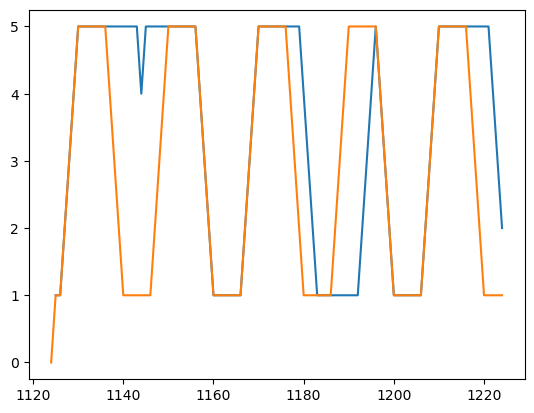

In [155]:
T = T_initial+T_val
gamma = 0.5
t_prime = 6
current_state = np.random.choice([int(i) for i in range(7)],size = 1)
future_states = [current_state.item()]
# print(current_state)
FUTURE_STATE = []
for delta_t in range(100):
    df_all_paths = enumerate_paths(x0=current_state,t_inital = T+delta_t,t_prime=t_prime)
    n_paths = df_all_paths.shape[0]
    irewards_pred = np.zeros((n_paths,  t_prime+1))
    for i in range(t_prime+1):
        cand_pe = position_encoder(df_all_paths.iloc[:,i], type="onehot")
        curr_time = T+1+delta_t+i
        time_emb = time_embedding_np(np.ones(cand_pe.shape[0])*curr_time, tdim=50)
        features = np.hstack([cand_pe,time_emb])
        pred_prob = predict_proba(model, features)
        pred_val = np.dot(pred_prob,unique_irewards.reshape(-1,1))
        irewards_pred[:,i] = pred_val.reshape(-1)
    reward_cols = [f"t={T+delta_t+t}" for t in range(t_prime+1)]
    df_ireward = pd.DataFrame(irewards_pred, columns=reward_cols)
    # Extract rewards from second column onward (t=1 to t=T)
    rewards_matrix = df_ireward.iloc[:, 1:].values  # shape (n_paths, T)
    discounts = gamma ** np.arange(1, t_prime+1)

    # Compute discounted total reward per path
    discounted_returns = rewards_matrix * discounts  
    total_discounted = discounted_returns.sum(axis=1)
    # print(total_discounted)
    bext_idx = np.argmax(total_discounted)
    next_state = int(df_all_paths.iloc[bext_idx,1])
    # print(df_all_paths.iloc[bext_idx,:])
    future_states.append(next_state)
    current_state = next_state

# print(T,future_states,len(future_states))
FUTURE_STATE.append(future_states)

irewards_test = [reward_simulate(future_states[i],T+i,rewards_in_period) for i in np.arange(1,len(future_states))]
preward = compute_normalized_future_rewards(irewards_test,100,0.5)
path, ireward_opt = path_opt(future_states[0], T, 100)
preward_opt_test = compute_normalized_future_rewards(ireward_opt[1:],100,0.5)
pregret = (np.sum(preward_opt_test).item()-np.sum(preward).item())/100
print(pregret)
plt.plot(np.arange(T+1,T+101),future_states[1:])
plt.plot(np.arange(T,T+101),path)
plt.show()

[ 0.          0.10077696  0.1679616   0.279936    0.46656     0.7776
  1.296       2.16        3.6         6.         10.        ]
(3687, 57) (3687,) (409, 57) (409, 57)
Epoch 01 | train loss 1.5953 | train acc 0.750 | val acc 0.895
Epoch 02 | train loss 0.0834 | train acc 0.858 | val acc 0.895
Epoch 03 | train loss 0.0294 | train acc 0.858 | val acc 0.895
Epoch 04 | train loss 0.0273 | train acc 0.858 | val acc 0.895
Epoch 05 | train loss 0.0267 | train acc 0.858 | val acc 0.895
Epoch 06 | train loss 0.0265 | train acc 0.857 | val acc 0.895
Epoch 07 | train loss 0.0264 | train acc 0.857 | val acc 0.895
Epoch 08 | train loss 0.0259 | train acc 0.858 | val acc 0.895
Epoch 09 | train loss 0.0257 | train acc 0.858 | val acc 0.895
Epoch 10 | train loss 0.0253 | train acc 0.858 | val acc 0.895
Epoch 11 | train loss 0.0252 | train acc 0.857 | val acc 0.895
Epoch 12 | train loss 0.0249 | train acc 0.858 | val acc 0.895
Epoch 13 | train loss 0.0249 | train acc 0.857 | val acc 0.895
Epoch 14 | 

/var/folders/7_/9pm8yyb11yl_smkwv7tk0ysc0000gn/T/ipykernel_11586/2323851762.py:58: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  pred_val = np.dot(pred_prob,unique_irewards.reshape(-1,1))
/var/folders/7_/9pm8yyb11yl_smkwv7tk0ysc0000gn/T/ipykernel_11586/2323851762.py:71: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  next_state = int(df_all_paths.iloc[bext_idx,1])


2.420732626866877


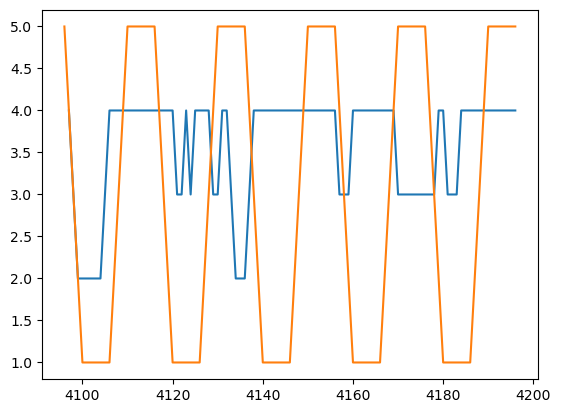

In [ ]:
### MLP Classifier
DELTA_t = 5
t_prime = 6
batch_size_train = 32
# Ts = [2**i for i in np.arange(7,10)]+[750]+[1024,1250,1500,2048,4096]
Ts = [4096]
for rep in range(1):
    FUTURE_STATE = []
    actions, states, irewards, times = simulate_data_raw(rewards_in_period = rewards_in_period,
                                                        session_duration = 500000,
                                                        tdim=50, 
                                                        n_sessions=1,seed  = 515+rep)
    state_posencode_oh = position_encoder(states[:,0], type="onehot")
    new_state_oh = np.hstack([state_posencode_oh,states[:,1:]])

    unique_irewards = np.sort(np.unique(irewards))
    print(unique_irewards)
    # Build mapping: real value → class index
    val_to_class = {val: idx for idx, val in enumerate(unique_irewards)}
    class_to_val = {idx: val for idx, val in enumerate(unique_irewards)}  # inverse map

    # Assign class indices
    irewards_class = np.array([val_to_class[y] for y in irewards])

    Y_class, counts = np.unique(irewards_class, return_counts=True)
    priors = counts / counts.sum()
    print(priors)
    for T in Ts:
        T_val = int(0.1*T)
        T_initial = T - T_val

        X_train = new_state_oh[:T_initial,:]
        Y_train = irewards_class[:T_initial]

        X_val = new_state_oh[T_initial:T_initial+T_val,:]
        Y_val = irewards_class[T_initial:T_initial+T_val]
        print(X_train.shape,Y_train.shape,X_val.shape,X_val.shape)
        if T >= 1024:
            batch_size_train = 64
        batch_size_val = T_val
        train_ds = TensorDataset(torch.from_numpy(X_train.astype(np.float32)), torch.from_numpy(Y_train.astype(np.int64)))
        val_ds   = TensorDataset(torch.from_numpy(X_val.astype(np.float32)), torch.from_numpy(Y_val.astype(np.int64)))
        train_loader = DataLoader(train_ds, batch_size=batch_size_train, shuffle=True, drop_last=False)
        val_loader   = DataLoader(val_ds,  batch_size=batch_size_val, shuffle=False, drop_last=False)

        model = MLP(input_dim=X_train.shape[1],  hidden=(256,128), n_classes=11, p_dropout=0.1)
        model = train_model(model, train_loader, val_loader, epochs=500, lr=1e-4)

        current_state = np.random.choice([int(i) for i in range(7)],size = 1)
        future_states = [current_state.item()]
        # print(current_state)
        for delta_t in range(100):
            df_all_paths = enumerate_paths(x0=current_state,t_inital = T+delta_t,t_prime=t_prime)
            n_paths = df_all_paths.shape[0]
            irewards_pred = np.zeros((n_paths,  t_prime+1))
            for i in range(t_prime+1):
                cand_pe = position_encoder(df_all_paths.iloc[:,i], type="onehot")
                curr_time = T+1+delta_t+i
                time_emb = time_embedding_np(np.ones(cand_pe.shape[0])*curr_time, tdim=50)
                features = np.hstack([cand_pe,time_emb])
                pred_prob = predict_proba(model, features)
                pred_val = np.dot(pred_prob,unique_irewards.reshape(-1,1))
                irewards_pred[:,i] = pred_val.reshape(-1)
            reward_cols = [f"t={T+delta_t+t}" for t in range(t_prime+1)]
            df_ireward = pd.DataFrame(irewards_pred, columns=reward_cols)
            # Extract rewards from second column onward (t=1 to t=T)
            rewards_matrix = df_ireward.iloc[:, 1:].values  # shape (n_paths, T)
            discounts = gamma ** np.arange(1, t_prime+1)

            # Compute discounted total reward per path
            discounted_returns = rewards_matrix * discounts  
            total_discounted = discounted_returns.sum(axis=1)
            # print(total_discounted)
            bext_idx = np.argmax(total_discounted)
            next_state = int(df_all_paths.iloc[bext_idx,1])
            # print(df_all_paths.iloc[bext_idx,:])
            future_states.append(next_state)
            current_state = next_state
        
        # print(T,future_states,len(future_states))
        FUTURE_STATE.append(future_states)

        irewards_test = [reward_simulate(future_states[i],T+i,rewards_in_period) for i in np.arange(1,len(future_states))]
        preward = compute_normalized_future_rewards(irewards_test,100,0.5)
        path, ireward_opt = path_opt(future_states[0], T, 100)
        preward_opt_test = compute_normalized_future_rewards(ireward_opt[1:],100,0.5)
        pregret = (np.sum(preward_opt_test).item()-np.sum(preward).item())/100
        print(pregret)
        plt.plot(np.arange(T+1,T+101),future_states[1:])
        plt.plot(np.arange(T,T+101),path)
        plt.show()
    FUTURE_STATE_arr = np.vstack(FUTURE_STATE)
    np.savez(
        f"../results/PAFM/NN_Yuxin/NNClassfier_oh_w_time128_2048_lookahead{t_prime}_reps{rep}.npz",
        future_states =FUTURE_STATE_arr
        )


# PAFM - Regressor - MLP

In [28]:
class MLPRegressor(nn.Module):
    def __init__(self, input_dim, hidden=(256, 128), p_dropout=0.2, use_sigmoid=True):
        super().__init__()
        layers = []
        d = input_dim
        for h in hidden:
            layers += [nn.Linear(d, h), nn.ReLU(), nn.Dropout(p_dropout)]
            d = h
        layers += [nn.Linear(d, 1)]
        if use_sigmoid:           # keep preds in [0,1] if y is normalized
            layers += [nn.Sigmoid()]
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)        # (N, 1)

def mse_loss(pred, target, eps=1e-12):
    # return torch.sqrt(nn.functional.mse_loss(pred, target) + eps)
    return nn.functional.mse_loss(pred, target)

def train_regressor(model, train_loader, val_loader, epochs=30, lr=1e-3, weight_decay=1e-4, device=None):
    device = device or ("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    best_tr = float("inf")
    best_val = float("inf")
    best_state = None

    for ep in range(1, epochs+1):
        model.train()
        tot_rmse, n_batches = 0.0, 0
        for xb, yb in train_loader:
            xb = xb.to(device).float()
            yb = yb.to(device).float().view(-1, 1)  # ensure (N,1)

            opt.zero_grad()
            preds = model(xb)
            loss = mse_loss(preds, yb)
            loss.backward()
            opt.step()

            tot_rmse += loss.item()
            n_batches += 1

        # validation
        model.eval()
        val_rmse, m = 0.0, 0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb = xb.to(device).float()
                yb = yb.to(device).float().view(-1, 1)
                preds = model(xb)
                val_rmse += mse_loss(preds, yb).item()
                m += 1
        val_rmse /= max(1, m)
        tr_rmse = tot_rmse / max(1, n_batches)
        if ep % 100 == 0:
            print(f"Epoch {ep:02d} | train MSE {tr_rmse:.6f} | val MSE {val_rmse:.6f}")

        if tr_rmse <= best_tr:
            if val_rmse <= best_val:
                best_tr = tr_rmse
                best_val = val_rmse
                best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
                print(f"Best Model: Epoch {ep:02d} | train MSE {tr_rmse:.6f} | val MSE {val_rmse:.6f}")

    if best_state is not None:
        model.load_state_dict(best_state)
    return model

def predict(model, X):
    model.eval()
    device = next(model.parameters()).device
    with torch.no_grad():
        if isinstance(X, torch.Tensor):
            X_t = X.to(device).float()
        else:
            import numpy as np
            X_t = torch.from_numpy(np.asarray(X, dtype=np.float32)).to(device)
        preds = model(X_t).cpu().squeeze(1)
    return preds

In [107]:
T_initial = 2500
T_val = 100
X_train = new_state_oh[:T_initial,:]
Y_train = np.array(irewards[:T_initial]).reshape(-1,1)/10

X_val = new_state_oh[T_initial:T_initial+T_val,:]
Y_val = np.array(irewards[T_initial:T_initial+T_val]).reshape(-1,1)/10
print(X_train.shape,Y_train.shape)

(2500, 57) (2500, 1)


In [ ]:
DELTA_t = 5
t_prime = 6
batch_size_train = 32
Ts = [2**i for i in np.arange(7,10)]+[750]+[1024,1250,1500,2048]
for rep in range(10):
    np.random.seed(515+rep)
    FUTURE_STATE = []
    for T in Ts:
        n_seq = int((T+100)/(DELTA_t+1))
        # n_seq = T
        state_raw = np.random.choice([int(i) for i in range(7)],size = n_seq)
        time_raw = np.random.choice([int(i) for i in range(T-DELTA_t)],size = n_seq)
        opt_paths, opt_times, opt_irewards, opt_prewards = [], [], [], []
        STATES = []
        for i in range(len(time_raw)):
            path, rewards = path_opt(state_raw[i], time_raw[i], DELTA_t)
            # print(state_raw[i],path)
            times = [time_raw[i]+delta_t for delta_t in np.arange(1,DELTA_t+2)] # raw time begin from 1
            opt_paths.append(path)
            opt_irewards.append(rewards)
            opt_times.append(times)
            opt_prewards.append(preward_opt(rewards,gamma = 0.5))
            state_posencode_oh = position_encoder(np.array(path), type="onehot")
            time_emb = time_embedding_np(np.array(times)).reshape(DELTA_t+1,-1)
            # print(time_emb.shape,state_posencode_oh.shape)
            state_pe = np.hstack([state_posencode_oh,time_emb])
            STATES.append(state_pe)
        STATES_arr = np.vstack(STATES)
        REWARDS_arr = np.hstack(np.array(opt_irewards).reshape(-1,1))
        print(STATES_arr.shape,REWARDS_arr.shape)
        X = STATES_arr
        Y = REWARDS_arr
        X_train = X[:T,:]
        Y_train = np.array(Y[:T]).reshape(-1,1)/10

        X_val = X[T:,:]
        Y_val = np.array(Y[T:]).reshape(-1,1)/10
        print(X_train.shape,Y_train.shape,X_val.shape,X_val.shape)

        
        batch_size_val = T_val
        train_ds = TensorDataset(torch.from_numpy(X_train.astype(np.float32)), torch.from_numpy(Y_train.astype(np.float32)))
        val_ds   = TensorDataset(torch.from_numpy(X_val.astype(np.float32)), torch.from_numpy(Y_val.astype(np.float32)))
        train_loader = DataLoader(train_ds, batch_size=batch_size_train, shuffle=True, drop_last=False)
        val_loader   = DataLoader(val_ds,  batch_size=batch_size_val, shuffle=False, drop_last=False)

        model = MLPRegressor(input_dim=X_train.shape[1], hidden=(512,256), p_dropout=0.1, use_sigmoid=True)
        model = train_regressor(model, train_loader, val_loader, epochs=500, lr=1e-4,weight_decay = 1e-4)

        current_state = np.random.choice([int(i) for i in range(7)],size = 1)
        future_states = [current_state.item()]
        # print(current_state)
        for delta_t in range(100):
            df_all_paths = enumerate_paths(x0=current_state,t_inital = T+delta_t,t_prime=t_prime)
            n_paths = df_all_paths.shape[0]
            irewards_pred = np.zeros((n_paths,  t_prime+1))
            for i in range(t_prime+1):
                cand_pe = position_encoder(df_all_paths.iloc[:,i], type="onehot")
                curr_time = T+1+delta_t+i
                time_emb = time_embedding_np(np.ones(cand_pe.shape[0])*curr_time, tdim=50)
                features = np.hstack([cand_pe,time_emb])
                irewards_pred[:,i] = predict(model, features)*10
            reward_cols = [f"t={T+delta_t+t}" for t in range(t_prime+1)]
            df_ireward = pd.DataFrame(irewards_pred, columns=reward_cols)
            # Extract rewards from second column onward (t=1 to t=T)
            rewards_matrix = df_ireward.iloc[:, 1:].values  # shape (n_paths, T)
            discounts = gamma ** np.arange(1, t_prime+1)

            # Compute discounted total reward per path
            discounted_returns = rewards_matrix * discounts  
            total_discounted = discounted_returns.sum(axis=1)
            # print(total_discounted)
            bext_idx = np.argmax(total_discounted)
            next_state = int(df_all_paths.iloc[bext_idx,1])
            # print(df_all_paths.iloc[bext_idx,:])
            future_states.append(next_state)
            current_state = next_state
        
        # print(T,future_states,len(future_states))
        FUTURE_STATE.append(future_states)

        irewards = [reward_simulate(future_states[i],T+i,rewards_in_period) for i in np.arange(1,len(future_states))]
        preward = compute_normalized_future_rewards(irewards,100,0.5)
        path, ireward_opt = path_opt(future_states[0], T, 100)
        preward_opt_test = compute_normalized_future_rewards(ireward_opt[1:],100,0.5)
        pregret = (np.sum(preward_opt_test).item()-np.sum(preward).item())/100
        print(pregret)
        plt.plot(np.arange(T+1,T+101),future_states[1:])
        plt.plot(np.arange(T,T+101),path)
        plt.show()
    FUTURE_STATE_arr = np.vstack(FUTURE_STATE)
    np.savez(
        f"../results/PAFM/NN_optimal_oh_w_time128_2048_lookahead{t_prime}_reps{rep}.npz",
        future_states =FUTURE_STATE_arr
        )


# PAFM - MLP - Sim

(116, 57) (116,) (12, 57) (12, 57)
Best Model: Epoch 01 | train MSE 2.804346 | val MSE 7.603208
Best Model: Epoch 02 | train MSE 1.961808 | val MSE 7.101187
Best Model: Epoch 03 | train MSE 1.369530 | val MSE 6.406210
Best Model: Epoch 04 | train MSE 0.846391 | val MSE 5.159002
Best Model: Epoch 05 | train MSE 0.650572 | val MSE 5.115027
Epoch 100 | train MSE 0.040973 | val MSE 6.176248
Epoch 200 | train MSE 0.000179 | val MSE 5.957596
Best Model: Epoch 243 | train MSE 0.258561 | val MSE 4.918985
Best Model: Epoch 267 | train MSE 0.074095 | val MSE 4.485966
Best Model: Epoch 274 | train MSE 0.045398 | val MSE 3.991810
Epoch 300 | train MSE 0.018116 | val MSE 4.569107
Epoch 400 | train MSE 0.000045 | val MSE 4.650609
Epoch 500 | train MSE 0.000001 | val MSE 4.646838
Epoch 600 | train MSE 0.008155 | val MSE 4.730116
Epoch 700 | train MSE 0.000009 | val MSE 4.201898
Epoch 800 | train MSE 0.000000 | val MSE 4.200252
Epoch 900 | train MSE 0.001539 | val MSE 4.218390
Best Model: Epoch 919 | 

/var/folders/7_/9pm8yyb11yl_smkwv7tk0ysc0000gn/T/ipykernel_50692/1070472635.py:46: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  irewards_pred[:,i] = predict(model, features)
/var/folders/7_/9pm8yyb11yl_smkwv7tk0ysc0000gn/T/ipykernel_50692/1070472635.py:58: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  next_state = int(df_all_paths.iloc[bext_idx,1])


1.1892779714209343


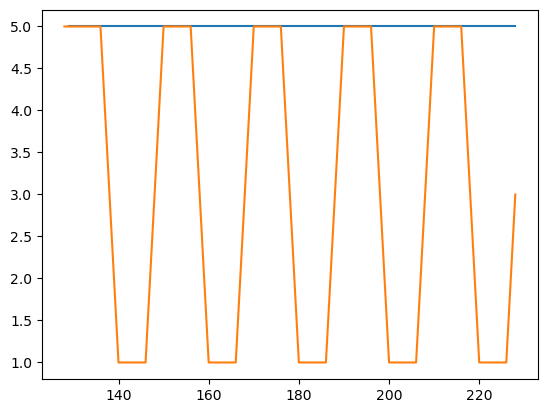

(231, 57) (231,) (25, 57) (25, 57)
Best Model: Epoch 01 | train MSE 2.625602 | val MSE 1.136547
Best Model: Epoch 02 | train MSE 2.206721 | val MSE 1.026953
Best Model: Epoch 04 | train MSE 1.698125 | val MSE 0.896875
Best Model: Epoch 05 | train MSE 1.285162 | val MSE 0.880887
Best Model: Epoch 08 | train MSE 0.360203 | val MSE 0.761522
Best Model: Epoch 11 | train MSE 0.072312 | val MSE 0.590669
Epoch 100 | train MSE 0.136193 | val MSE 0.885939
Epoch 200 | train MSE 0.000958 | val MSE 0.860033
Best Model: Epoch 241 | train MSE 0.022950 | val MSE 0.490483
Best Model: Epoch 242 | train MSE 0.013203 | val MSE 0.482655
Best Model: Epoch 243 | train MSE 0.011704 | val MSE 0.462105
Best Model: Epoch 245 | train MSE 0.006253 | val MSE 0.451127
Best Model: Epoch 246 | train MSE 0.005414 | val MSE 0.449349
Epoch 300 | train MSE 0.000127 | val MSE 0.713404
Epoch 400 | train MSE 0.013944 | val MSE 0.647775
Epoch 500 | train MSE 0.005574 | val MSE 1.156040
Epoch 600 | train MSE 0.000011 | val MS

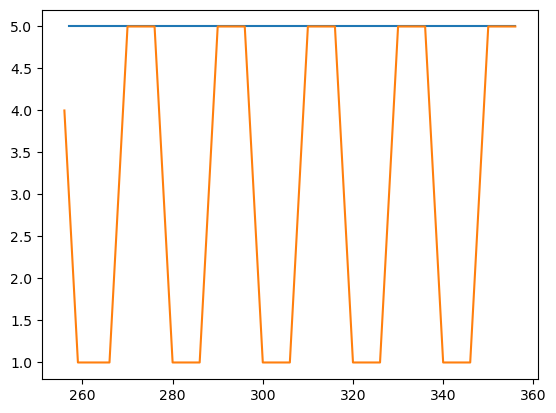

(461, 57) (461,) (51, 57) (51, 57)
Best Model: Epoch 01 | train MSE 2.914370 | val MSE 0.652233
Best Model: Epoch 04 | train MSE 0.640209 | val MSE 0.427882
Epoch 100 | train MSE 0.007544 | val MSE 2.814828
Epoch 200 | train MSE 0.143030 | val MSE 1.941966
Epoch 300 | train MSE 0.015792 | val MSE 2.441658
Epoch 400 | train MSE 0.002334 | val MSE 2.986775
Epoch 500 | train MSE 0.005127 | val MSE 3.111457
Epoch 600 | train MSE 0.010262 | val MSE 2.686331
Epoch 700 | train MSE 0.050797 | val MSE 2.608537
Epoch 800 | train MSE 0.025029 | val MSE 2.333894
Epoch 900 | train MSE 0.024264 | val MSE 2.294111
Epoch 1000 | train MSE 0.005643 | val MSE 2.014111
Epoch 1100 | train MSE 0.003166 | val MSE 2.030190
Epoch 1200 | train MSE 0.009395 | val MSE 1.915425
Epoch 1300 | train MSE 0.001400 | val MSE 1.741436
Epoch 1400 | train MSE 0.009149 | val MSE 1.607998
Epoch 1500 | train MSE 0.000184 | val MSE 1.682166
Epoch 1600 | train MSE 0.001794 | val MSE 1.482025
Epoch 1700 | train MSE 0.006900 | va

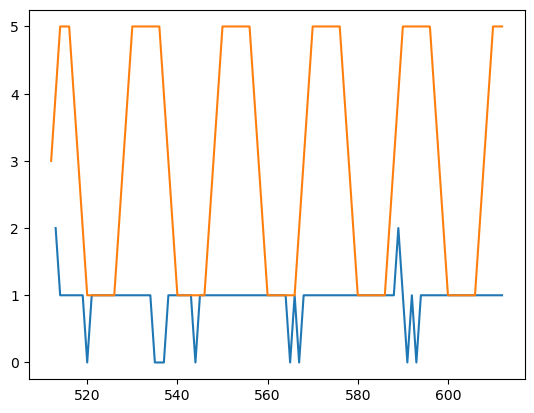

(675, 57) (675,) (75, 57) (75, 57)
Best Model: Epoch 01 | train MSE 2.619455 | val MSE 0.472943
Best Model: Epoch 02 | train MSE 1.572613 | val MSE 0.468955
Best Model: Epoch 24 | train MSE 0.263003 | val MSE 0.421909
Epoch 100 | train MSE 0.004574 | val MSE 0.815576
Epoch 200 | train MSE 0.001243 | val MSE 0.760270
Epoch 300 | train MSE 0.009885 | val MSE 0.976403
Epoch 400 | train MSE 0.069522 | val MSE 0.672375
Best Model: Epoch 454 | train MSE 0.077528 | val MSE 0.380965
Epoch 500 | train MSE 0.064811 | val MSE 0.394511
Best Model: Epoch 509 | train MSE 0.062216 | val MSE 0.378839
Best Model: Epoch 579 | train MSE 0.034943 | val MSE 0.376096
Epoch 600 | train MSE 0.022230 | val MSE 0.413088
Epoch 700 | train MSE 0.071326 | val MSE 0.490310
Epoch 800 | train MSE 0.066207 | val MSE 0.394126
Epoch 900 | train MSE 0.062856 | val MSE 0.483804
Epoch 1000 | train MSE 0.061871 | val MSE 0.444539
Epoch 1100 | train MSE 0.074887 | val MSE 0.501744
Epoch 1200 | train MSE 0.062096 | val MSE 0.

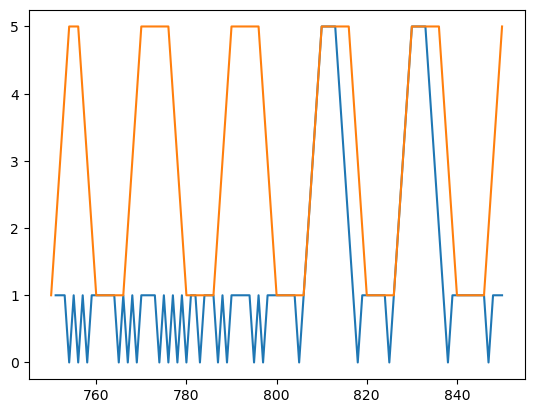

(922, 57) (922,) (102, 57) (102, 57)
Best Model: Epoch 01 | train MSE 2.355861 | val MSE 2.891465
Best Model: Epoch 02 | train MSE 1.457462 | val MSE 2.736103
Best Model: Epoch 11 | train MSE 0.041172 | val MSE 2.710724
Best Model: Epoch 14 | train MSE 0.018410 | val MSE 2.662701
Best Model: Epoch 35 | train MSE 0.011649 | val MSE 2.406800
Epoch 100 | train MSE 0.020736 | val MSE 2.837595
Epoch 200 | train MSE 0.058813 | val MSE 3.092011
Epoch 300 | train MSE 0.079691 | val MSE 2.960046
Epoch 400 | train MSE 0.004719 | val MSE 2.730122
Epoch 500 | train MSE 0.121063 | val MSE 2.669453
Best Model: Epoch 586 | train MSE 0.008816 | val MSE 2.140575
Best Model: Epoch 590 | train MSE 0.004663 | val MSE 2.121660
Epoch 600 | train MSE 0.005354 | val MSE 2.182243
Best Model: Epoch 619 | train MSE 0.004498 | val MSE 2.114155
Epoch 700 | train MSE 0.001636 | val MSE 2.197057
Epoch 800 | train MSE 0.003767 | val MSE 2.162654
Best Model: Epoch 875 | train MSE 0.004031 | val MSE 2.079908
Epoch 900 

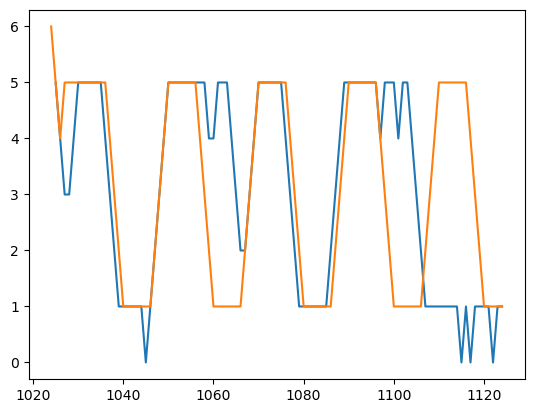

(1125, 57) (1125,) (125, 57) (125, 57)
Best Model: Epoch 01 | train MSE 2.214608 | val MSE 1.605480
Best Model: Epoch 04 | train MSE 0.463742 | val MSE 1.601109
Best Model: Epoch 05 | train MSE 0.305043 | val MSE 1.297912
Best Model: Epoch 07 | train MSE 0.175753 | val MSE 1.296285
Best Model: Epoch 08 | train MSE 0.103563 | val MSE 1.120287
Best Model: Epoch 09 | train MSE 0.074033 | val MSE 1.055516
Best Model: Epoch 17 | train MSE 0.007990 | val MSE 1.000236
Epoch 100 | train MSE 0.044100 | val MSE 1.088512
Best Model: Epoch 172 | train MSE 0.006093 | val MSE 0.789964
Best Model: Epoch 173 | train MSE 0.004136 | val MSE 0.781594
Best Model: Epoch 176 | train MSE 0.001723 | val MSE 0.778910
Epoch 200 | train MSE 0.000155 | val MSE 0.794635
Epoch 300 | train MSE 0.007825 | val MSE 1.071489
Epoch 400 | train MSE 0.056997 | val MSE 1.143718
Epoch 500 | train MSE 0.005653 | val MSE 1.131392
Epoch 600 | train MSE 0.000388 | val MSE 1.194572
Epoch 700 | train MSE 0.000039 | val MSE 0.89155

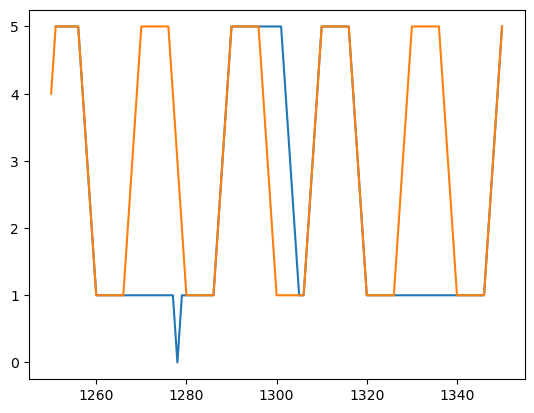

(1350, 57) (1350,) (150, 57) (150, 57)
Best Model: Epoch 01 | train MSE 1.994207 | val MSE 1.255284
Best Model: Epoch 07 | train MSE 0.094295 | val MSE 1.102591
Best Model: Epoch 15 | train MSE 0.094073 | val MSE 0.952354
Best Model: Epoch 16 | train MSE 0.089790 | val MSE 0.895845
Best Model: Epoch 17 | train MSE 0.089058 | val MSE 0.766609
Best Model: Epoch 19 | train MSE 0.058749 | val MSE 0.736748
Best Model: Epoch 20 | train MSE 0.032740 | val MSE 0.726171
Best Model: Epoch 21 | train MSE 0.014361 | val MSE 0.700588
Epoch 100 | train MSE 0.003483 | val MSE 0.744622
Best Model: Epoch 124 | train MSE 0.012690 | val MSE 0.686198
Best Model: Epoch 133 | train MSE 0.002806 | val MSE 0.674756
Epoch 200 | train MSE 0.002334 | val MSE 0.787296
Best Model: Epoch 259 | train MSE 0.002760 | val MSE 0.632639
Best Model: Epoch 260 | train MSE 0.002469 | val MSE 0.630975
Best Model: Epoch 261 | train MSE 0.002439 | val MSE 0.612305
Epoch 300 | train MSE 0.013095 | val MSE 0.664330
Epoch 400 | t

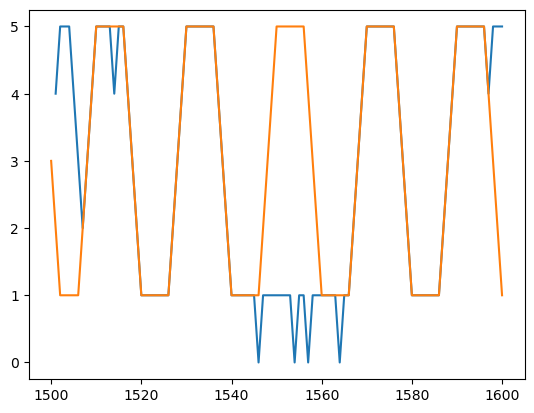

(1844, 57) (1844,) (204, 57) (204, 57)
Best Model: Epoch 01 | train MSE 1.841103 | val MSE 2.173967
Best Model: Epoch 04 | train MSE 0.356856 | val MSE 1.910686
Best Model: Epoch 05 | train MSE 0.259957 | val MSE 1.651033
Best Model: Epoch 08 | train MSE 0.128870 | val MSE 1.528471
Best Model: Epoch 10 | train MSE 0.040995 | val MSE 1.380255
Best Model: Epoch 11 | train MSE 0.024698 | val MSE 1.370592
Best Model: Epoch 12 | train MSE 0.016928 | val MSE 1.364458
Best Model: Epoch 13 | train MSE 0.011281 | val MSE 1.321482
Best Model: Epoch 46 | train MSE 0.007728 | val MSE 1.165431
Best Model: Epoch 48 | train MSE 0.005191 | val MSE 1.149835
Best Model: Epoch 49 | train MSE 0.003377 | val MSE 1.119935
Best Model: Epoch 51 | train MSE 0.002878 | val MSE 1.119345
Best Model: Epoch 52 | train MSE 0.002394 | val MSE 1.106639
Best Model: Epoch 59 | train MSE 0.000566 | val MSE 1.098560
Epoch 100 | train MSE 0.005090 | val MSE 0.695333
Best Model: Epoch 104 | train MSE 0.000348 | val MSE 0.72

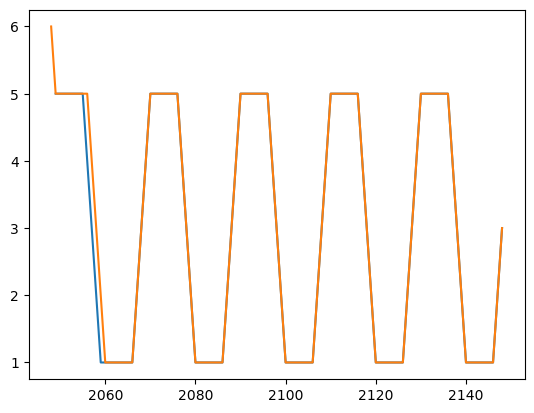

(3687, 57) (3687,) (409, 57) (409, 57)
Best Model: Epoch 01 | train MSE 1.702551 | val MSE 0.768988
Best Model: Epoch 02 | train MSE 0.553071 | val MSE 0.197128
Best Model: Epoch 03 | train MSE 0.311306 | val MSE 0.127951
Best Model: Epoch 04 | train MSE 0.150408 | val MSE 0.071839
Best Model: Epoch 05 | train MSE 0.096592 | val MSE 0.041362
Best Model: Epoch 06 | train MSE 0.045688 | val MSE 0.021602
Best Model: Epoch 08 | train MSE 0.030018 | val MSE 0.021204
Best Model: Epoch 09 | train MSE 0.025816 | val MSE 0.020241
Best Model: Epoch 11 | train MSE 0.025247 | val MSE 0.017508
Best Model: Epoch 17 | train MSE 0.024152 | val MSE 0.010756
Best Model: Epoch 20 | train MSE 0.008639 | val MSE 0.009233
Best Model: Epoch 21 | train MSE 0.007401 | val MSE 0.004802
Best Model: Epoch 33 | train MSE 0.004819 | val MSE 0.003990
Best Model: Epoch 34 | train MSE 0.003846 | val MSE 0.003586
Best Model: Epoch 55 | train MSE 0.002245 | val MSE 0.002698
Best Model: Epoch 80 | train MSE 0.001080 | va

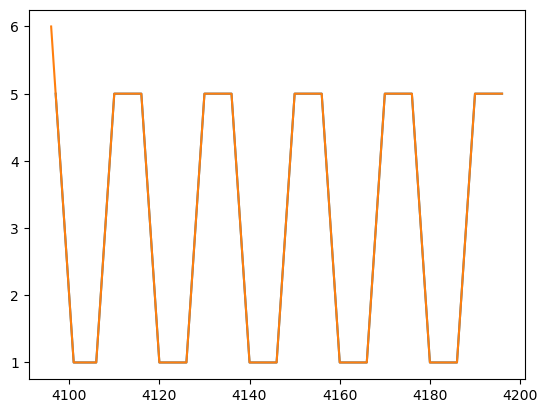

(116, 57) (116,) (12, 57) (12, 57)
Best Model: Epoch 01 | train MSE 3.315526 | val MSE 0.411593
Best Model: Epoch 02 | train MSE 2.765181 | val MSE 0.207528
Epoch 100 | train MSE 0.000064 | val MSE 2.171427
Epoch 200 | train MSE 0.000003 | val MSE 2.164351
Epoch 300 | train MSE 0.004602 | val MSE 1.990284
Epoch 400 | train MSE 0.000003 | val MSE 1.933564
Epoch 500 | train MSE 0.000000 | val MSE 1.936787
Epoch 600 | train MSE 0.000000 | val MSE 1.937494
Epoch 700 | train MSE 0.000000 | val MSE 1.935263
Epoch 800 | train MSE 0.039609 | val MSE 2.194240
Epoch 900 | train MSE 0.000051 | val MSE 2.916322
Epoch 1000 | train MSE 0.000005 | val MSE 2.838687
Epoch 1100 | train MSE 0.000000 | val MSE 2.847259
Epoch 1200 | train MSE 0.000000 | val MSE 2.847482
Epoch 1300 | train MSE 0.000000 | val MSE 2.847350
Epoch 1400 | train MSE 0.000001 | val MSE 2.854613
Epoch 1500 | train MSE 0.000022 | val MSE 2.925405
Epoch 1600 | train MSE 0.000003 | val MSE 2.902831
Epoch 1700 | train MSE 0.000971 | va

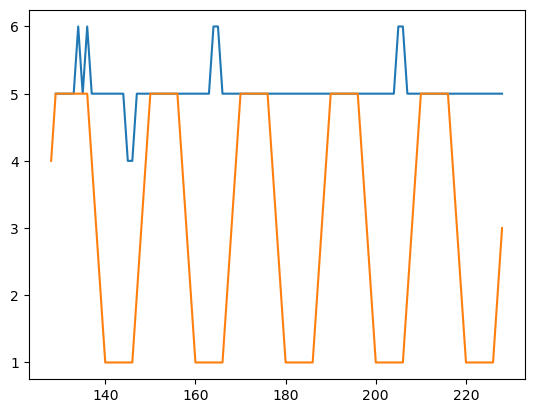

(231, 57) (231,) (25, 57) (25, 57)
Best Model: Epoch 01 | train MSE 3.104898 | val MSE 1.911224
Best Model: Epoch 02 | train MSE 2.883369 | val MSE 1.728642
Best Model: Epoch 03 | train MSE 2.181397 | val MSE 1.497879
Best Model: Epoch 04 | train MSE 1.311309 | val MSE 1.272412
Best Model: Epoch 07 | train MSE 0.966233 | val MSE 1.158814
Best Model: Epoch 10 | train MSE 0.922635 | val MSE 0.971402
Best Model: Epoch 19 | train MSE 0.030028 | val MSE 0.969493
Epoch 100 | train MSE 0.014616 | val MSE 1.159464
Best Model: Epoch 114 | train MSE 0.016446 | val MSE 0.828508
Epoch 200 | train MSE 0.075646 | val MSE 0.763508
Best Model: Epoch 224 | train MSE 0.013364 | val MSE 0.659289
Best Model: Epoch 225 | train MSE 0.009092 | val MSE 0.614140
Best Model: Epoch 229 | train MSE 0.007232 | val MSE 0.556502
Epoch 300 | train MSE 0.000257 | val MSE 0.614172
Epoch 400 | train MSE 0.128179 | val MSE 0.475432
Best Model: Epoch 415 | train MSE 0.006526 | val MSE 0.468357
Epoch 500 | train MSE 0.0214

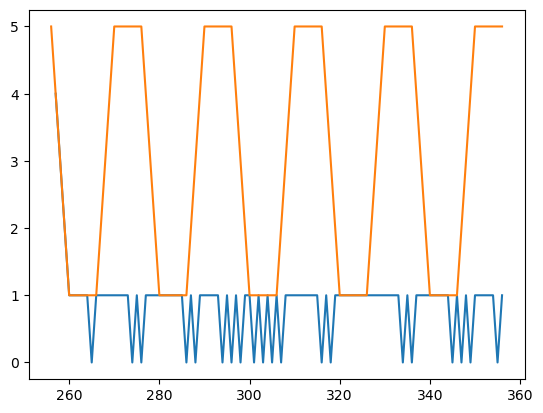

(461, 57) (461,) (51, 57) (51, 57)
Best Model: Epoch 01 | train MSE 2.494616 | val MSE 4.915904
Best Model: Epoch 02 | train MSE 2.061240 | val MSE 4.007715
Best Model: Epoch 03 | train MSE 1.450167 | val MSE 3.697671
Best Model: Epoch 05 | train MSE 0.813750 | val MSE 3.081128
Best Model: Epoch 06 | train MSE 0.658101 | val MSE 2.724529
Best Model: Epoch 08 | train MSE 0.391105 | val MSE 2.380063
Best Model: Epoch 10 | train MSE 0.123611 | val MSE 2.337437
Best Model: Epoch 11 | train MSE 0.087511 | val MSE 2.071077
Epoch 100 | train MSE 0.031874 | val MSE 2.785744
Epoch 200 | train MSE 0.000055 | val MSE 2.756352
Epoch 300 | train MSE 0.006935 | val MSE 2.772142
Best Model: Epoch 322 | train MSE 0.076784 | val MSE 1.942625
Epoch 400 | train MSE 0.001775 | val MSE 1.975036
Best Model: Epoch 470 | train MSE 0.038189 | val MSE 1.874389
Best Model: Epoch 474 | train MSE 0.009151 | val MSE 1.865350
Best Model: Epoch 476 | train MSE 0.006445 | val MSE 1.864922
Best Model: Epoch 478 | train

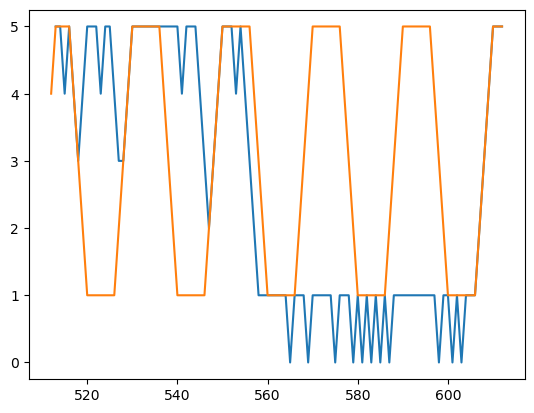

(675, 57) (675,) (75, 57) (75, 57)
Best Model: Epoch 01 | train MSE 2.716058 | val MSE 1.922728
Best Model: Epoch 03 | train MSE 0.952992 | val MSE 1.617862
Best Model: Epoch 05 | train MSE 0.663521 | val MSE 1.617251
Best Model: Epoch 07 | train MSE 0.260053 | val MSE 1.546057
Best Model: Epoch 09 | train MSE 0.190076 | val MSE 1.510373
Best Model: Epoch 16 | train MSE 0.043292 | val MSE 1.473028
Best Model: Epoch 17 | train MSE 0.030979 | val MSE 1.470975
Best Model: Epoch 46 | train MSE 0.020157 | val MSE 1.417762
Best Model: Epoch 62 | train MSE 0.016148 | val MSE 1.404585
Epoch 100 | train MSE 0.000289 | val MSE 1.711846
Epoch 200 | train MSE 0.000126 | val MSE 1.685837
Epoch 300 | train MSE 0.014628 | val MSE 1.659768
Epoch 400 | train MSE 0.001965 | val MSE 1.554052
Epoch 500 | train MSE 0.001191 | val MSE 1.552360
Epoch 600 | train MSE 0.000825 | val MSE 1.648002
Epoch 700 | train MSE 0.000461 | val MSE 1.634778
Epoch 800 | train MSE 0.000053 | val MSE 1.659943
Epoch 900 | trai

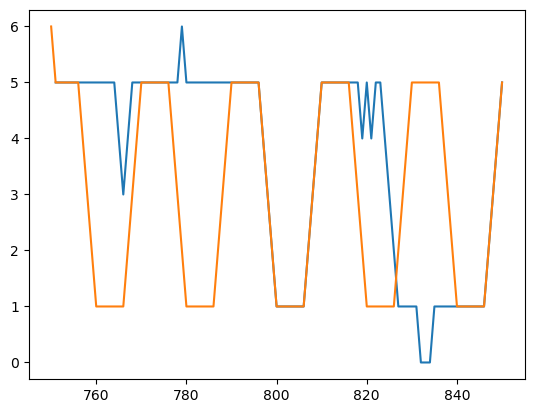

(922, 57) (922,) (102, 57) (102, 57)
Best Model: Epoch 01 | train MSE 2.611190 | val MSE 1.907604
Best Model: Epoch 02 | train MSE 1.837200 | val MSE 0.912505
Best Model: Epoch 03 | train MSE 0.958858 | val MSE 0.590203
Best Model: Epoch 04 | train MSE 0.360498 | val MSE 0.447305
Best Model: Epoch 05 | train MSE 0.310878 | val MSE 0.324795
Best Model: Epoch 11 | train MSE 0.158160 | val MSE 0.269955
Best Model: Epoch 19 | train MSE 0.066865 | val MSE 0.266110
Best Model: Epoch 42 | train MSE 0.036966 | val MSE 0.238077
Epoch 100 | train MSE 0.000741 | val MSE 0.335270
Best Model: Epoch 128 | train MSE 0.017671 | val MSE 0.223393
Best Model: Epoch 176 | train MSE 0.007934 | val MSE 0.214260
Epoch 200 | train MSE 0.058681 | val MSE 0.324031
Epoch 300 | train MSE 0.000206 | val MSE 0.279148
Epoch 400 | train MSE 0.008691 | val MSE 0.342768
Epoch 500 | train MSE 0.007518 | val MSE 0.367036
Epoch 600 | train MSE 0.000388 | val MSE 0.340452
Epoch 700 | train MSE 0.000606 | val MSE 0.379872
E

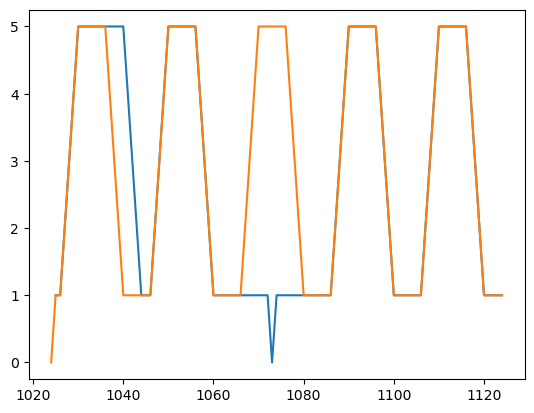

(1125, 57) (1125,) (125, 57) (125, 57)
Best Model: Epoch 01 | train MSE 2.488938 | val MSE 2.273743
Best Model: Epoch 08 | train MSE 0.180849 | val MSE 2.256361
Best Model: Epoch 36 | train MSE 0.121830 | val MSE 2.209395
Epoch 100 | train MSE 0.030643 | val MSE 2.680249
Epoch 200 | train MSE 0.000260 | val MSE 2.740043
Epoch 300 | train MSE 0.000528 | val MSE 2.767865
Best Model: Epoch 388 | train MSE 0.076413 | val MSE 1.912400
Best Model: Epoch 394 | train MSE 0.005640 | val MSE 1.869683
Epoch 400 | train MSE 0.001257 | val MSE 1.900208
Best Model: Epoch 442 | train MSE 0.002485 | val MSE 1.857212
Best Model: Epoch 470 | train MSE 0.002310 | val MSE 1.851868
Epoch 500 | train MSE 0.018157 | val MSE 1.835587
Best Model: Epoch 514 | train MSE 0.002242 | val MSE 1.848000
Best Model: Epoch 515 | train MSE 0.001653 | val MSE 1.814609
Best Model: Epoch 517 | train MSE 0.000774 | val MSE 1.810697
Best Model: Epoch 519 | train MSE 0.000425 | val MSE 1.804309
Best Model: Epoch 595 | train MS

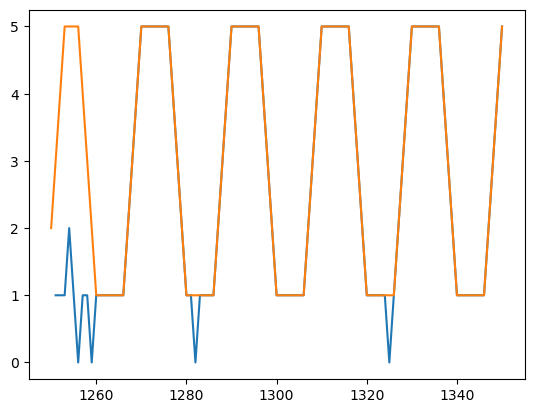

(1350, 57) (1350,) (150, 57) (150, 57)
Best Model: Epoch 01 | train MSE 2.398154 | val MSE 1.589643
Best Model: Epoch 02 | train MSE 1.573492 | val MSE 1.290795
Best Model: Epoch 04 | train MSE 0.599165 | val MSE 0.790363
Best Model: Epoch 09 | train MSE 0.085466 | val MSE 0.755803
Best Model: Epoch 10 | train MSE 0.064465 | val MSE 0.603099
Best Model: Epoch 25 | train MSE 0.048972 | val MSE 0.602785
Best Model: Epoch 28 | train MSE 0.025910 | val MSE 0.594545
Best Model: Epoch 44 | train MSE 0.023159 | val MSE 0.500558
Epoch 100 | train MSE 0.034149 | val MSE 0.496197
Epoch 200 | train MSE 0.002167 | val MSE 0.626606
Best Model: Epoch 232 | train MSE 0.012212 | val MSE 0.456640
Best Model: Epoch 234 | train MSE 0.005308 | val MSE 0.454220
Best Model: Epoch 235 | train MSE 0.004884 | val MSE 0.434402
Epoch 300 | train MSE 0.041665 | val MSE 0.472129
Best Model: Epoch 354 | train MSE 0.004804 | val MSE 0.428236
Epoch 400 | train MSE 0.001204 | val MSE 0.467088
Best Model: Epoch 433 | t

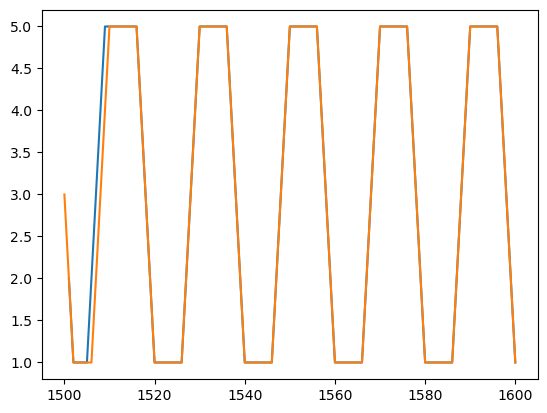

(1844, 57) (1844,) (204, 57) (204, 57)
Best Model: Epoch 01 | train MSE 2.369527 | val MSE 2.167455
Best Model: Epoch 02 | train MSE 1.347749 | val MSE 1.828661
Best Model: Epoch 04 | train MSE 0.434070 | val MSE 1.442241
Best Model: Epoch 05 | train MSE 0.327408 | val MSE 0.999038
Best Model: Epoch 08 | train MSE 0.069314 | val MSE 0.989737
Best Model: Epoch 09 | train MSE 0.036841 | val MSE 0.985476
Best Model: Epoch 11 | train MSE 0.028019 | val MSE 0.852003
Best Model: Epoch 31 | train MSE 0.016839 | val MSE 0.707593
Best Model: Epoch 32 | train MSE 0.010898 | val MSE 0.674386
Best Model: Epoch 33 | train MSE 0.005797 | val MSE 0.646439
Best Model: Epoch 36 | train MSE 0.003527 | val MSE 0.638956
Epoch 100 | train MSE 0.079665 | val MSE 0.551582
Best Model: Epoch 118 | train MSE 0.001466 | val MSE 0.314629
Best Model: Epoch 128 | train MSE 0.001334 | val MSE 0.299551
Best Model: Epoch 135 | train MSE 0.000784 | val MSE 0.278106
Best Model: Epoch 172 | train MSE 0.000595 | val MSE 0

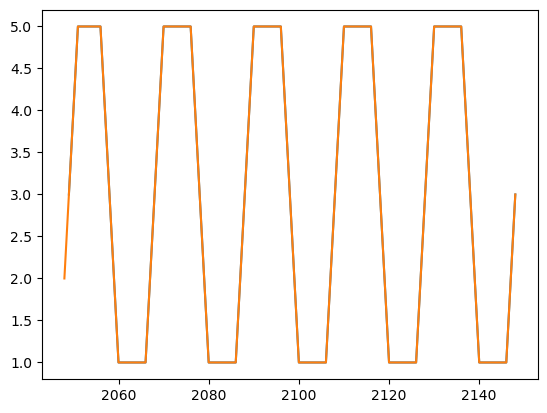

(3687, 57) (3687,) (409, 57) (409, 57)
Best Model: Epoch 01 | train MSE 1.782951 | val MSE 1.545818
Best Model: Epoch 02 | train MSE 0.929473 | val MSE 0.716136
Best Model: Epoch 03 | train MSE 0.324031 | val MSE 0.297086
Best Model: Epoch 04 | train MSE 0.112860 | val MSE 0.122239
Best Model: Epoch 05 | train MSE 0.053643 | val MSE 0.114707
Best Model: Epoch 06 | train MSE 0.040834 | val MSE 0.087355
Best Model: Epoch 07 | train MSE 0.024843 | val MSE 0.085187
Best Model: Epoch 08 | train MSE 0.019268 | val MSE 0.073653
Best Model: Epoch 09 | train MSE 0.014467 | val MSE 0.066928
Best Model: Epoch 23 | train MSE 0.012165 | val MSE 0.020720
Best Model: Epoch 26 | train MSE 0.010087 | val MSE 0.019046
Best Model: Epoch 36 | train MSE 0.005295 | val MSE 0.018387
Best Model: Epoch 51 | train MSE 0.004967 | val MSE 0.007297
Best Model: Epoch 55 | train MSE 0.003015 | val MSE 0.006862
Best Model: Epoch 90 | train MSE 0.002036 | val MSE 0.006856
Epoch 100 | train MSE 0.011823 | val MSE 0.008

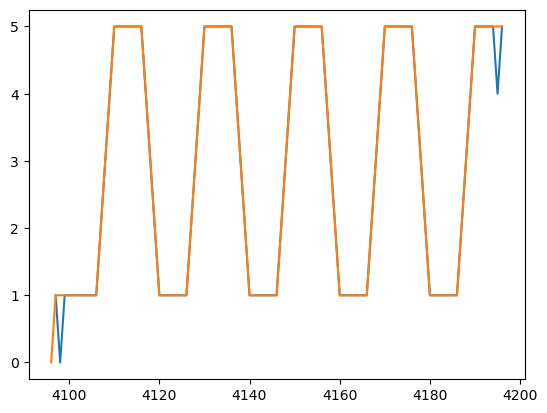

(116, 57) (116,) (12, 57) (12, 57)
Best Model: Epoch 01 | train MSE 2.569906 | val MSE 0.627007
Best Model: Epoch 02 | train MSE 2.250838 | val MSE 0.105043
Best Model: Epoch 03 | train MSE 1.657893 | val MSE 0.057034
Best Model: Epoch 05 | train MSE 0.818355 | val MSE 0.023803
Best Model: Epoch 06 | train MSE 0.437639 | val MSE 0.015162
Best Model: Epoch 10 | train MSE 0.202804 | val MSE 0.007378
Best Model: Epoch 11 | train MSE 0.199629 | val MSE 0.004472
Best Model: Epoch 12 | train MSE 0.146627 | val MSE 0.001869
Best Model: Epoch 13 | train MSE 0.098997 | val MSE 0.000702
Best Model: Epoch 21 | train MSE 0.044839 | val MSE 0.000509
Best Model: Epoch 22 | train MSE 0.028515 | val MSE 0.000324
Best Model: Epoch 24 | train MSE 0.021573 | val MSE 0.000233
Best Model: Epoch 26 | train MSE 0.021190 | val MSE 0.000218
Best Model: Epoch 27 | train MSE 0.011803 | val MSE 0.000139
Best Model: Epoch 29 | train MSE 0.010685 | val MSE 0.000054
Best Model: Epoch 32 | train MSE 0.009199 | val MS

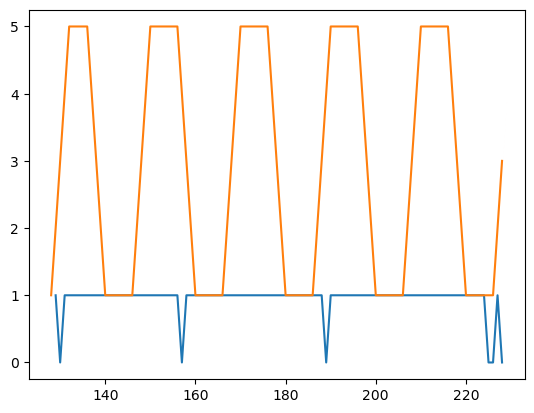

(231, 57) (231,) (25, 57) (25, 57)
Best Model: Epoch 01 | train MSE 1.964814 | val MSE 1.929419
Best Model: Epoch 02 | train MSE 1.495474 | val MSE 1.495404
Best Model: Epoch 03 | train MSE 1.129654 | val MSE 1.448996
Best Model: Epoch 09 | train MSE 0.248949 | val MSE 1.309079
Epoch 100 | train MSE 0.025287 | val MSE 1.624305
Epoch 200 | train MSE 0.005107 | val MSE 1.476130
Best Model: Epoch 241 | train MSE 0.024871 | val MSE 1.287936
Best Model: Epoch 242 | train MSE 0.016993 | val MSE 1.220249
Epoch 300 | train MSE 0.000084 | val MSE 1.384301
Epoch 400 | train MSE 0.000007 | val MSE 1.391797
Epoch 500 | train MSE 0.007681 | val MSE 1.326914
Epoch 600 | train MSE 0.000020 | val MSE 1.465728
Epoch 700 | train MSE 0.000001 | val MSE 1.467317
Epoch 800 | train MSE 0.000000 | val MSE 1.469676
Epoch 900 | train MSE 0.000008 | val MSE 1.472055
Epoch 1000 | train MSE 0.000022 | val MSE 1.474241
Epoch 1100 | train MSE 0.000225 | val MSE 1.599900
Epoch 1200 | train MSE 0.000027 | val MSE 1.5

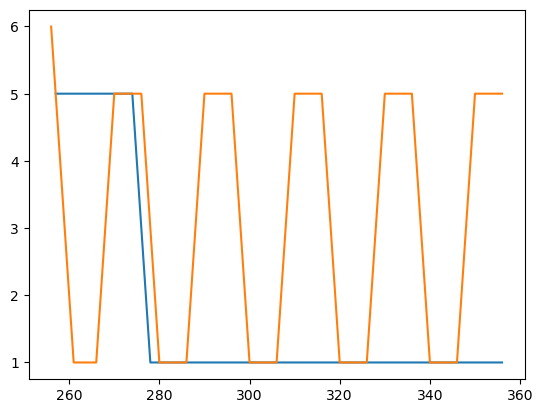

(461, 57) (461,) (51, 57) (51, 57)
Best Model: Epoch 01 | train MSE 2.039875 | val MSE 0.184951
Epoch 100 | train MSE 0.042524 | val MSE 1.199861
Epoch 200 | train MSE 0.005144 | val MSE 0.887478
Epoch 300 | train MSE 0.000117 | val MSE 1.355597
Epoch 400 | train MSE 0.000005 | val MSE 1.562892
Epoch 500 | train MSE 0.000013 | val MSE 1.631181
Epoch 600 | train MSE 0.000165 | val MSE 1.599166
Epoch 700 | train MSE 0.000205 | val MSE 1.431313
Epoch 800 | train MSE 0.000408 | val MSE 1.468010
Epoch 900 | train MSE 0.001256 | val MSE 1.527597
Epoch 1000 | train MSE 0.003439 | val MSE 1.346844
Epoch 1100 | train MSE 0.000626 | val MSE 1.399276
Epoch 1200 | train MSE 0.000081 | val MSE 1.477256
Epoch 1300 | train MSE 0.000158 | val MSE 1.458466
Epoch 1400 | train MSE 0.000183 | val MSE 1.138956
Epoch 1500 | train MSE 0.000001 | val MSE 1.138440
Epoch 1600 | train MSE 0.000015 | val MSE 1.115225
Epoch 1700 | train MSE 0.000100 | val MSE 1.100062
Epoch 1800 | train MSE 0.000011 | val MSE 1.02

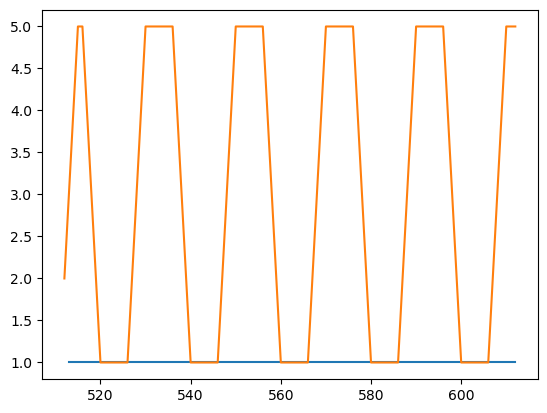

(675, 57) (675,) (75, 57) (75, 57)
Best Model: Epoch 01 | train MSE 2.108499 | val MSE 2.578861
Best Model: Epoch 02 | train MSE 1.311173 | val MSE 2.378661
Best Model: Epoch 03 | train MSE 0.553905 | val MSE 2.160420
Best Model: Epoch 04 | train MSE 0.297201 | val MSE 1.828048
Best Model: Epoch 26 | train MSE 0.015263 | val MSE 1.802901
Best Model: Epoch 37 | train MSE 0.011775 | val MSE 1.788520
Best Model: Epoch 38 | train MSE 0.011331 | val MSE 1.722766
Epoch 100 | train MSE 0.000445 | val MSE 1.976126
Best Model: Epoch 180 | train MSE 0.005582 | val MSE 1.654181
Epoch 200 | train MSE 0.001225 | val MSE 1.731699
Best Model: Epoch 259 | train MSE 0.005510 | val MSE 1.618726
Best Model: Epoch 287 | train MSE 0.001109 | val MSE 1.609056
Epoch 300 | train MSE 0.000698 | val MSE 1.654772
Epoch 400 | train MSE 0.006506 | val MSE 1.697147
Epoch 500 | train MSE 0.032830 | val MSE 1.625153
Epoch 600 | train MSE 0.000196 | val MSE 1.669428
Best Model: Epoch 628 | train MSE 0.000822 | val MSE

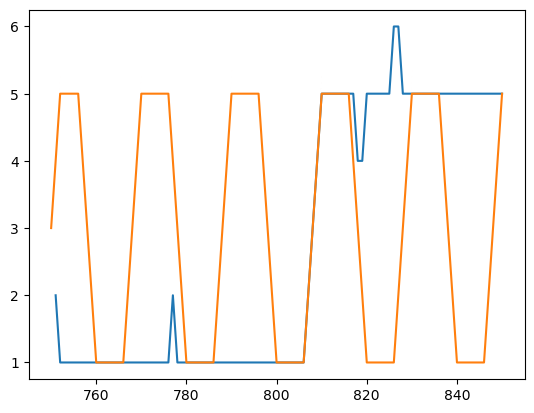

(922, 57) (922,) (102, 57) (102, 57)
Best Model: Epoch 01 | train MSE 2.269072 | val MSE 1.837426
Best Model: Epoch 02 | train MSE 1.241320 | val MSE 1.047746
Best Model: Epoch 03 | train MSE 0.540643 | val MSE 1.040692
Best Model: Epoch 06 | train MSE 0.241379 | val MSE 1.005698
Best Model: Epoch 07 | train MSE 0.112846 | val MSE 0.924746
Best Model: Epoch 10 | train MSE 0.057713 | val MSE 0.907532
Best Model: Epoch 26 | train MSE 0.037613 | val MSE 0.827955
Best Model: Epoch 36 | train MSE 0.007840 | val MSE 0.799683
Best Model: Epoch 88 | train MSE 0.005885 | val MSE 0.784571
Best Model: Epoch 89 | train MSE 0.003337 | val MSE 0.780118
Best Model: Epoch 90 | train MSE 0.002158 | val MSE 0.772195
Best Model: Epoch 92 | train MSE 0.001508 | val MSE 0.755060
Epoch 100 | train MSE 0.001196 | val MSE 0.790729
Epoch 200 | train MSE 0.000445 | val MSE 0.804735
Epoch 300 | train MSE 0.018551 | val MSE 0.829086
Epoch 400 | train MSE 0.016829 | val MSE 0.745333
Epoch 500 | train MSE 0.000727 

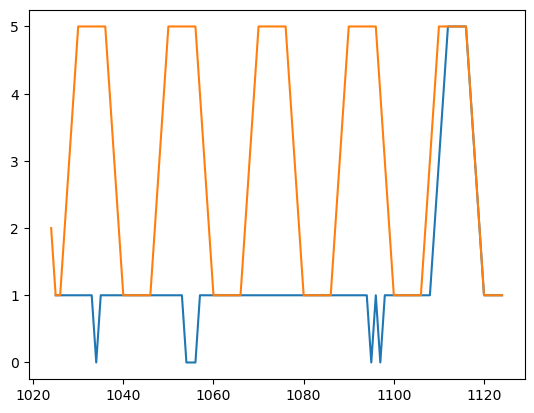

(1125, 57) (1125,) (125, 57) (125, 57)
Best Model: Epoch 01 | train MSE 2.016761 | val MSE 1.868836
Best Model: Epoch 02 | train MSE 1.176444 | val MSE 1.198400
Best Model: Epoch 03 | train MSE 0.513843 | val MSE 0.955696
Best Model: Epoch 07 | train MSE 0.138629 | val MSE 0.906620
Epoch 100 | train MSE 0.001880 | val MSE 1.103803
Epoch 200 | train MSE 0.000589 | val MSE 1.128343
Best Model: Epoch 230 | train MSE 0.055459 | val MSE 0.902622
Best Model: Epoch 236 | train MSE 0.009041 | val MSE 0.882629
Epoch 300 | train MSE 0.003782 | val MSE 0.971090
Best Model: Epoch 317 | train MSE 0.008872 | val MSE 0.873410
Best Model: Epoch 323 | train MSE 0.000985 | val MSE 0.871075
Best Model: Epoch 359 | train MSE 0.000771 | val MSE 0.738934
Epoch 400 | train MSE 0.000412 | val MSE 0.747401
Epoch 500 | train MSE 0.016921 | val MSE 0.916585
Epoch 600 | train MSE 0.000669 | val MSE 0.970571
Epoch 700 | train MSE 0.001340 | val MSE 0.861222
Epoch 800 | train MSE 0.011883 | val MSE 0.955705
Epoch 9

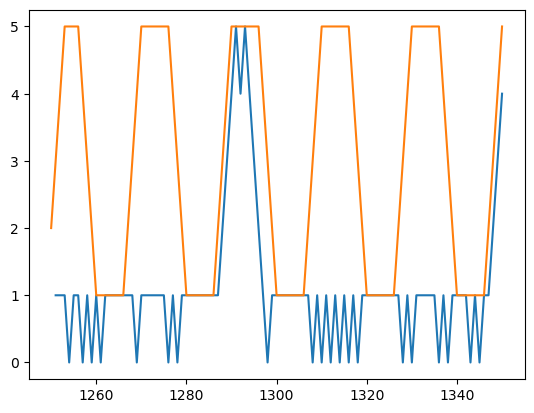

(1350, 57) (1350,) (150, 57) (150, 57)
Best Model: Epoch 01 | train MSE 1.842021 | val MSE 1.235775
Best Model: Epoch 02 | train MSE 0.998102 | val MSE 1.217543
Best Model: Epoch 03 | train MSE 0.676148 | val MSE 0.964415
Best Model: Epoch 35 | train MSE 0.190211 | val MSE 0.959032
Best Model: Epoch 42 | train MSE 0.157109 | val MSE 0.906602
Best Model: Epoch 44 | train MSE 0.054184 | val MSE 0.779160
Best Model: Epoch 45 | train MSE 0.014578 | val MSE 0.754318
Best Model: Epoch 48 | train MSE 0.002687 | val MSE 0.750444
Best Model: Epoch 94 | train MSE 0.002319 | val MSE 0.683862
Epoch 100 | train MSE 0.000531 | val MSE 0.685155
Best Model: Epoch 106 | train MSE 0.000369 | val MSE 0.683701
Best Model: Epoch 111 | train MSE 0.000335 | val MSE 0.683470
Epoch 200 | train MSE 0.001015 | val MSE 0.506981
Epoch 300 | train MSE 0.002407 | val MSE 0.506059
Epoch 400 | train MSE 0.000435 | val MSE 0.426760
Epoch 500 | train MSE 0.000612 | val MSE 0.505178
Epoch 600 | train MSE 0.009938 | val M

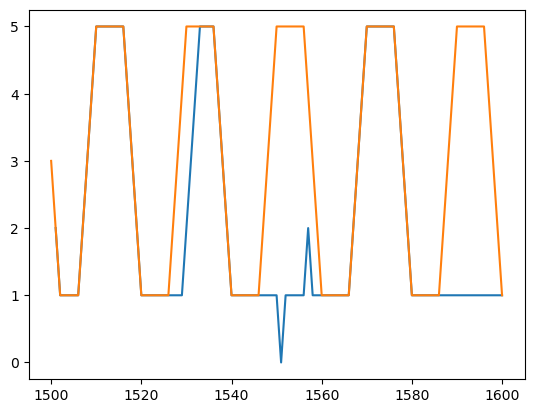

(1844, 57) (1844,) (204, 57) (204, 57)
Best Model: Epoch 01 | train MSE 1.737327 | val MSE 1.732007
Best Model: Epoch 02 | train MSE 1.091238 | val MSE 1.558833
Best Model: Epoch 03 | train MSE 0.580572 | val MSE 1.221410
Best Model: Epoch 04 | train MSE 0.290167 | val MSE 1.001050
Best Model: Epoch 08 | train MSE 0.106598 | val MSE 0.897658
Best Model: Epoch 10 | train MSE 0.072784 | val MSE 0.854071
Best Model: Epoch 11 | train MSE 0.071766 | val MSE 0.705758
Best Model: Epoch 18 | train MSE 0.068793 | val MSE 0.591510
Epoch 100 | train MSE 0.018146 | val MSE 0.642099
Epoch 200 | train MSE 0.000943 | val MSE 0.674561
Best Model: Epoch 222 | train MSE 0.006081 | val MSE 0.585375
Best Model: Epoch 243 | train MSE 0.002774 | val MSE 0.580366
Best Model: Epoch 245 | train MSE 0.001527 | val MSE 0.578573
Best Model: Epoch 248 | train MSE 0.001481 | val MSE 0.573226
Epoch 300 | train MSE 0.001725 | val MSE 0.558833
Best Model: Epoch 360 | train MSE 0.001422 | val MSE 0.492062
Best Model: E

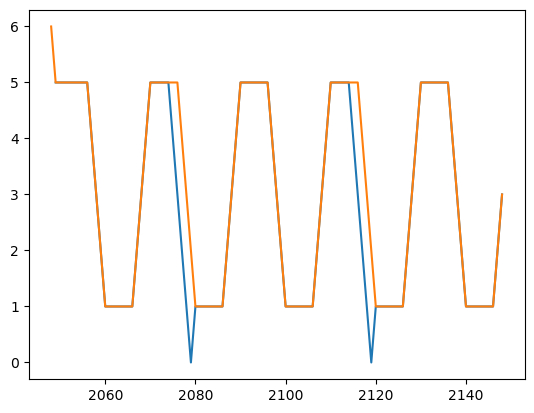

(3687, 57) (3687,) (409, 57) (409, 57)
Best Model: Epoch 01 | train MSE 1.681970 | val MSE 0.713305
Best Model: Epoch 02 | train MSE 0.493922 | val MSE 0.479881
Best Model: Epoch 03 | train MSE 0.240796 | val MSE 0.191873
Best Model: Epoch 04 | train MSE 0.091324 | val MSE 0.139031
Best Model: Epoch 05 | train MSE 0.056138 | val MSE 0.109364
Best Model: Epoch 06 | train MSE 0.039664 | val MSE 0.068158
Best Model: Epoch 09 | train MSE 0.027054 | val MSE 0.054344
Best Model: Epoch 16 | train MSE 0.021931 | val MSE 0.049323
Best Model: Epoch 26 | train MSE 0.020187 | val MSE 0.019620
Best Model: Epoch 27 | train MSE 0.009562 | val MSE 0.018026
Best Model: Epoch 28 | train MSE 0.006569 | val MSE 0.013220
Best Model: Epoch 29 | train MSE 0.003766 | val MSE 0.010317
Best Model: Epoch 31 | train MSE 0.002395 | val MSE 0.008471
Best Model: Epoch 35 | train MSE 0.001246 | val MSE 0.007657
Best Model: Epoch 62 | train MSE 0.000450 | val MSE 0.007487
Epoch 100 | train MSE 0.042394 | val MSE 0.071

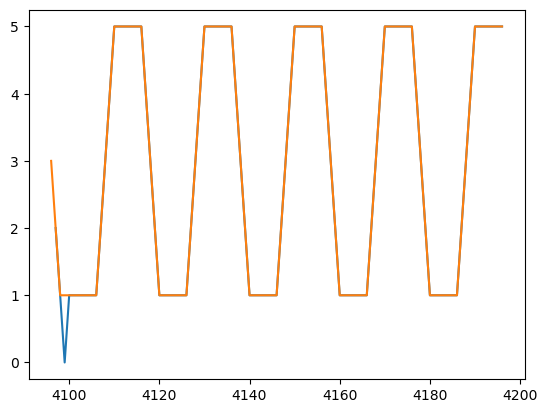

(116, 57) (116,) (12, 57) (12, 57)
Best Model: Epoch 01 | train MSE 3.242712 | val MSE 0.453328
Epoch 100 | train MSE 0.000093 | val MSE 0.799055
Epoch 200 | train MSE 0.003077 | val MSE 1.047109
Epoch 300 | train MSE 0.000033 | val MSE 1.091074
Epoch 400 | train MSE 0.000002 | val MSE 1.097435
Epoch 500 | train MSE 0.015892 | val MSE 0.987709
Epoch 600 | train MSE 0.000250 | val MSE 0.752339
Epoch 700 | train MSE 0.000059 | val MSE 0.749149
Epoch 800 | train MSE 0.000026 | val MSE 0.747026
Epoch 900 | train MSE 0.000008 | val MSE 0.747084
Epoch 1000 | train MSE 0.000003 | val MSE 0.747833
Epoch 1100 | train MSE 0.010692 | val MSE 0.676802
Epoch 1200 | train MSE 0.000058 | val MSE 0.898251
Epoch 1300 | train MSE 0.000000 | val MSE 0.903675
Epoch 1400 | train MSE 0.000000 | val MSE 0.904203
Epoch 1500 | train MSE 0.000000 | val MSE 0.904532
Epoch 1600 | train MSE 0.000000 | val MSE 0.904784
Epoch 1700 | train MSE 0.000000 | val MSE 0.904999
Epoch 1800 | train MSE 0.000000 | val MSE 0.90

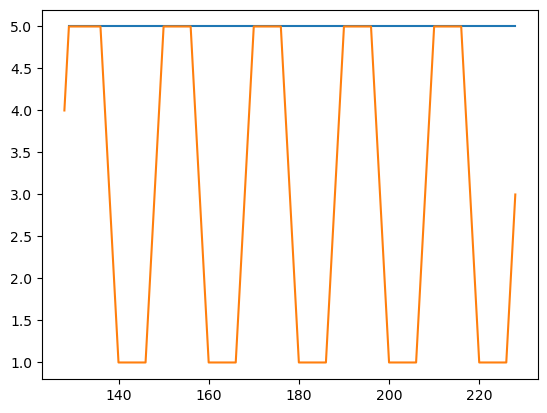

(231, 57) (231,) (25, 57) (25, 57)
Best Model: Epoch 01 | train MSE 2.813490 | val MSE 0.490084
Best Model: Epoch 02 | train MSE 2.250182 | val MSE 0.449578
Best Model: Epoch 03 | train MSE 2.011811 | val MSE 0.424291
Best Model: Epoch 04 | train MSE 1.299524 | val MSE 0.356186
Best Model: Epoch 05 | train MSE 0.900448 | val MSE 0.328855
Best Model: Epoch 09 | train MSE 0.077385 | val MSE 0.134362
Epoch 100 | train MSE 0.000202 | val MSE 0.589625
Epoch 200 | train MSE 0.000411 | val MSE 0.414161
Epoch 300 | train MSE 0.000807 | val MSE 0.454369
Epoch 400 | train MSE 0.000243 | val MSE 0.567575
Epoch 500 | train MSE 0.111259 | val MSE 0.603094
Epoch 600 | train MSE 0.003175 | val MSE 0.537555
Epoch 700 | train MSE 0.002929 | val MSE 0.537031
Epoch 800 | train MSE 0.004593 | val MSE 0.536511
Epoch 900 | train MSE 0.035419 | val MSE 0.493609
Epoch 1000 | train MSE 0.001356 | val MSE 0.583529
Epoch 1100 | train MSE 0.000248 | val MSE 0.594875
Epoch 1200 | train MSE 0.002764 | val MSE 0.566

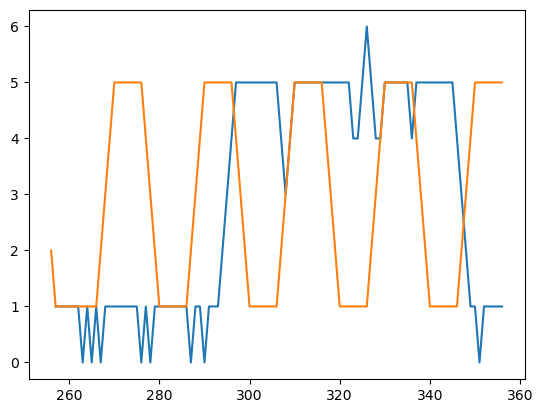

(461, 57) (461,) (51, 57) (51, 57)
Best Model: Epoch 01 | train MSE 1.933456 | val MSE 0.260506
Best Model: Epoch 03 | train MSE 1.161253 | val MSE 0.241967
Best Model: Epoch 25 | train MSE 0.167094 | val MSE 0.220218
Best Model: Epoch 62 | train MSE 0.041175 | val MSE 0.213614
Epoch 100 | train MSE 0.000545 | val MSE 0.358037
Epoch 200 | train MSE 0.000873 | val MSE 0.431737
Epoch 300 | train MSE 0.020237 | val MSE 0.442607
Epoch 400 | train MSE 0.000662 | val MSE 0.435364
Epoch 500 | train MSE 0.000664 | val MSE 0.450328
Epoch 600 | train MSE 0.024656 | val MSE 0.524329
Epoch 700 | train MSE 0.000240 | val MSE 0.473405
Epoch 800 | train MSE 0.186469 | val MSE 0.502417
Epoch 900 | train MSE 0.002615 | val MSE 0.522033
Epoch 1000 | train MSE 0.002887 | val MSE 0.500714
Epoch 1100 | train MSE 0.009531 | val MSE 0.457646
Epoch 1200 | train MSE 0.013786 | val MSE 0.529594
Epoch 1300 | train MSE 0.004628 | val MSE 0.565757
Epoch 1400 | train MSE 0.006515 | val MSE 0.612348
Epoch 1500 | tra

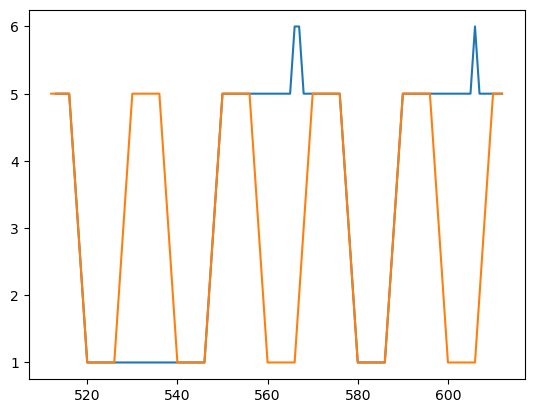

(675, 57) (675,) (75, 57) (75, 57)
Best Model: Epoch 01 | train MSE 2.317144 | val MSE 1.178773
Best Model: Epoch 08 | train MSE 0.216178 | val MSE 1.172212
Epoch 100 | train MSE 0.000226 | val MSE 1.626343
Epoch 200 | train MSE 0.000533 | val MSE 1.562319
Epoch 300 | train MSE 0.009428 | val MSE 1.538328
Best Model: Epoch 344 | train MSE 0.014551 | val MSE 1.169298
Epoch 400 | train MSE 0.000131 | val MSE 1.315627
Epoch 500 | train MSE 0.003169 | val MSE 1.518005
Epoch 600 | train MSE 0.079408 | val MSE 1.475945
Epoch 700 | train MSE 0.000507 | val MSE 1.496594
Epoch 800 | train MSE 0.000462 | val MSE 1.438498
Best Model: Epoch 864 | train MSE 0.010232 | val MSE 1.124564
Best Model: Epoch 866 | train MSE 0.009034 | val MSE 0.991450
Epoch 900 | train MSE 0.000211 | val MSE 1.049361
Best Model: Epoch 981 | train MSE 0.007531 | val MSE 0.949728
Epoch 1000 | train MSE 0.000138 | val MSE 0.994880
Epoch 1100 | train MSE 0.000053 | val MSE 0.983251
Epoch 1200 | train MSE 0.000013 | val MSE 1

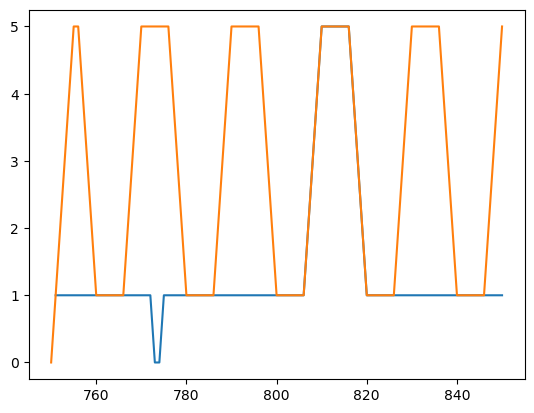

(922, 57) (922,) (102, 57) (102, 57)
Best Model: Epoch 01 | train MSE 2.128915 | val MSE 0.838103
Best Model: Epoch 02 | train MSE 1.224715 | val MSE 0.612983
Best Model: Epoch 95 | train MSE 0.276570 | val MSE 0.544737
Epoch 100 | train MSE 0.103225 | val MSE 0.992578
Epoch 200 | train MSE 0.000496 | val MSE 0.925244
Epoch 300 | train MSE 0.003671 | val MSE 1.000293
Epoch 400 | train MSE 0.000143 | val MSE 0.972703
Epoch 500 | train MSE 0.001510 | val MSE 1.032806
Epoch 600 | train MSE 0.004862 | val MSE 1.041748
Epoch 700 | train MSE 0.001411 | val MSE 0.730663
Epoch 800 | train MSE 0.000052 | val MSE 0.605210
Best Model: Epoch 846 | train MSE 0.049004 | val MSE 0.524013
Best Model: Epoch 847 | train MSE 0.039462 | val MSE 0.464967
Epoch 900 | train MSE 0.001768 | val MSE 0.645334
Epoch 1000 | train MSE 0.000238 | val MSE 0.574168
Best Model: Epoch 1023 | train MSE 0.021434 | val MSE 0.457407
Best Model: Epoch 1067 | train MSE 0.021384 | val MSE 0.444141
Epoch 1100 | train MSE 0.0213

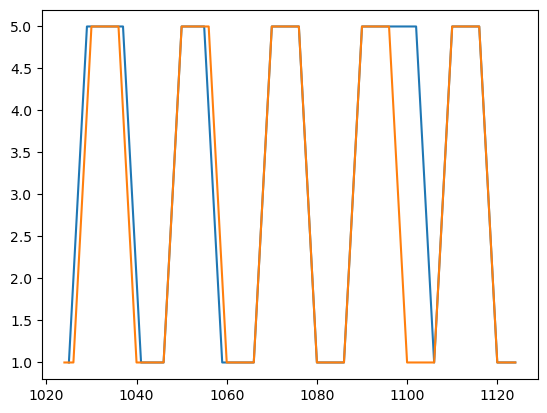

(1125, 57) (1125,) (125, 57) (125, 57)
Best Model: Epoch 01 | train MSE 2.071803 | val MSE 1.075680
Best Model: Epoch 03 | train MSE 1.156969 | val MSE 0.632213
Best Model: Epoch 04 | train MSE 0.417271 | val MSE 0.591074
Best Model: Epoch 11 | train MSE 0.075743 | val MSE 0.577870
Best Model: Epoch 15 | train MSE 0.032854 | val MSE 0.571077
Best Model: Epoch 54 | train MSE 0.019140 | val MSE 0.559023
Epoch 100 | train MSE 0.000921 | val MSE 0.735219
Epoch 200 | train MSE 0.109360 | val MSE 0.687789
Epoch 300 | train MSE 0.039942 | val MSE 0.609404
Best Model: Epoch 394 | train MSE 0.016752 | val MSE 0.513379
Best Model: Epoch 396 | train MSE 0.005811 | val MSE 0.511408
Best Model: Epoch 399 | train MSE 0.004011 | val MSE 0.511307
Epoch 400 | train MSE 0.003542 | val MSE 0.515159
Best Model: Epoch 456 | train MSE 0.003825 | val MSE 0.511107
Epoch 500 | train MSE 0.003071 | val MSE 0.572211
Epoch 600 | train MSE 0.001510 | val MSE 0.847479
Epoch 700 | train MSE 0.001349 | val MSE 0.8058

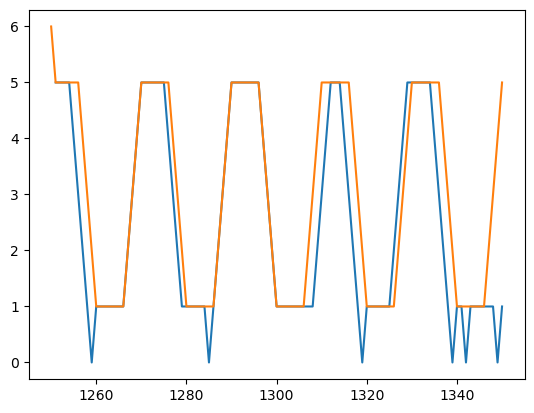

(1350, 57) (1350,) (150, 57) (150, 57)
Best Model: Epoch 01 | train MSE 1.829644 | val MSE 2.084763
Best Model: Epoch 02 | train MSE 0.973655 | val MSE 1.517036
Best Model: Epoch 03 | train MSE 0.641121 | val MSE 1.449952
Best Model: Epoch 04 | train MSE 0.428064 | val MSE 1.302544
Best Model: Epoch 06 | train MSE 0.233591 | val MSE 1.130122
Best Model: Epoch 09 | train MSE 0.195254 | val MSE 1.066379
Best Model: Epoch 13 | train MSE 0.058408 | val MSE 1.028497
Best Model: Epoch 30 | train MSE 0.007443 | val MSE 1.024633
Epoch 100 | train MSE 0.002736 | val MSE 1.055100
Best Model: Epoch 146 | train MSE 0.005881 | val MSE 0.950116
Best Model: Epoch 150 | train MSE 0.005674 | val MSE 0.937381
Best Model: Epoch 153 | train MSE 0.004262 | val MSE 0.926453
Best Model: Epoch 156 | train MSE 0.002813 | val MSE 0.920377
Best Model: Epoch 197 | train MSE 0.001724 | val MSE 0.885277
Epoch 200 | train MSE 0.001322 | val MSE 0.884305
Best Model: Epoch 200 | train MSE 0.001322 | val MSE 0.884305
B

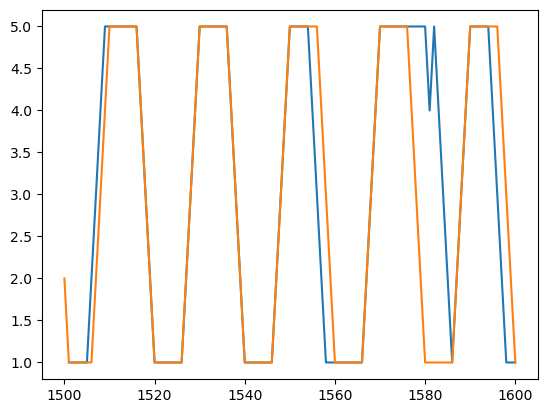

(1844, 57) (1844,) (204, 57) (204, 57)
Best Model: Epoch 01 | train MSE 1.915912 | val MSE 1.491301
Best Model: Epoch 02 | train MSE 1.198708 | val MSE 1.320521
Best Model: Epoch 03 | train MSE 0.717486 | val MSE 1.063552
Best Model: Epoch 04 | train MSE 0.371764 | val MSE 0.578491
Best Model: Epoch 07 | train MSE 0.078447 | val MSE 0.522601
Best Model: Epoch 10 | train MSE 0.040787 | val MSE 0.502376
Best Model: Epoch 11 | train MSE 0.030440 | val MSE 0.500771
Best Model: Epoch 15 | train MSE 0.015818 | val MSE 0.473173
Best Model: Epoch 30 | train MSE 0.008985 | val MSE 0.355625
Best Model: Epoch 39 | train MSE 0.008091 | val MSE 0.307911
Best Model: Epoch 45 | train MSE 0.007604 | val MSE 0.267602
Best Model: Epoch 60 | train MSE 0.006628 | val MSE 0.264962
Best Model: Epoch 90 | train MSE 0.006168 | val MSE 0.217753
Best Model: Epoch 92 | train MSE 0.005938 | val MSE 0.207029
Best Model: Epoch 93 | train MSE 0.002810 | val MSE 0.205240
Best Model: Epoch 95 | train MSE 0.000912 | va

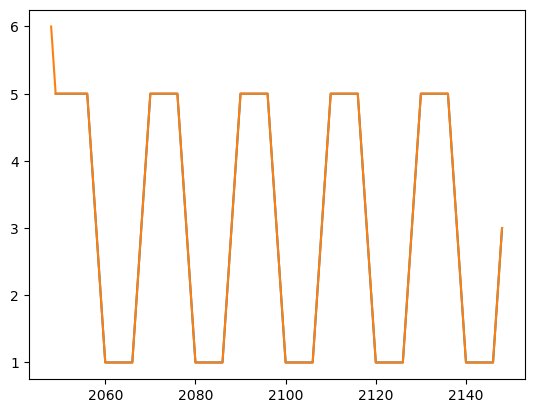

(3687, 57) (3687,) (409, 57) (409, 57)
Best Model: Epoch 01 | train MSE 1.682521 | val MSE 0.957555
Best Model: Epoch 02 | train MSE 0.623342 | val MSE 0.228972
Best Model: Epoch 04 | train MSE 0.182322 | val MSE 0.132216
Best Model: Epoch 05 | train MSE 0.085985 | val MSE 0.101524
Best Model: Epoch 07 | train MSE 0.052302 | val MSE 0.079139
Best Model: Epoch 10 | train MSE 0.023885 | val MSE 0.068211
Best Model: Epoch 12 | train MSE 0.020621 | val MSE 0.055939
Best Model: Epoch 13 | train MSE 0.017712 | val MSE 0.047057
Best Model: Epoch 21 | train MSE 0.012270 | val MSE 0.040981
Best Model: Epoch 22 | train MSE 0.008822 | val MSE 0.035404
Best Model: Epoch 37 | train MSE 0.007359 | val MSE 0.013167
Best Model: Epoch 39 | train MSE 0.002622 | val MSE 0.013053
Best Model: Epoch 40 | train MSE 0.001755 | val MSE 0.011795
Best Model: Epoch 42 | train MSE 0.000846 | val MSE 0.011363
Best Model: Epoch 46 | train MSE 0.000445 | val MSE 0.011153
Epoch 100 | train MSE 0.001855 | val MSE 0.006

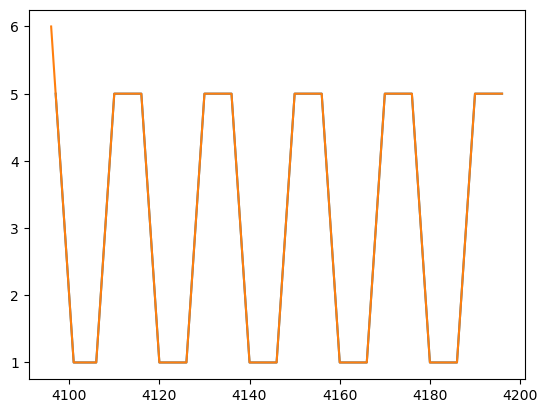

(116, 57) (116,) (12, 57) (12, 57)
Best Model: Epoch 01 | train MSE 2.283804 | val MSE 0.127872
Best Model: Epoch 02 | train MSE 1.869388 | val MSE 0.089869
Best Model: Epoch 03 | train MSE 1.455576 | val MSE 0.041804
Epoch 100 | train MSE 0.000072 | val MSE 0.200163
Epoch 200 | train MSE 0.002193 | val MSE 0.323088
Epoch 300 | train MSE 0.000005 | val MSE 0.348843
Epoch 400 | train MSE 0.003248 | val MSE 0.385267
Epoch 500 | train MSE 0.000000 | val MSE 0.419259
Epoch 600 | train MSE 0.000025 | val MSE 0.419294
Best Model: Epoch 647 | train MSE 0.481145 | val MSE 0.018105
Epoch 700 | train MSE 0.000186 | val MSE 0.165949
Epoch 800 | train MSE 0.000042 | val MSE 0.162331
Epoch 900 | train MSE 0.000026 | val MSE 0.161962
Epoch 1000 | train MSE 0.000015 | val MSE 0.162083
Epoch 1100 | train MSE 0.000005 | val MSE 0.163474
Epoch 1200 | train MSE 0.000220 | val MSE 0.178878
Epoch 1300 | train MSE 0.007836 | val MSE 0.082013
Epoch 1400 | train MSE 0.000043 | val MSE 0.117037
Epoch 1500 | tr

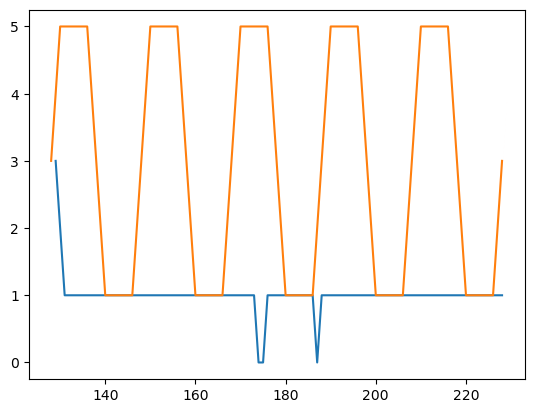

(231, 57) (231,) (25, 57) (25, 57)
Best Model: Epoch 01 | train MSE 2.423631 | val MSE 0.213389
Epoch 100 | train MSE 0.009921 | val MSE 1.331730
Epoch 200 | train MSE 0.004599 | val MSE 0.697907
Epoch 300 | train MSE 0.172085 | val MSE 0.445892
Epoch 400 | train MSE 0.000001 | val MSE 0.959547
Epoch 500 | train MSE 0.000000 | val MSE 0.960245
Epoch 600 | train MSE 0.000000 | val MSE 0.960945
Best Model: Epoch 684 | train MSE 0.263212 | val MSE 0.140538
Epoch 700 | train MSE 0.186755 | val MSE 0.501800
Epoch 800 | train MSE 0.000003 | val MSE 0.943433
Epoch 900 | train MSE 0.000000 | val MSE 0.944016
Epoch 1000 | train MSE 0.000000 | val MSE 0.944788
Epoch 1100 | train MSE 0.000000 | val MSE 0.945409
Epoch 1200 | train MSE 0.000000 | val MSE 0.945995
Epoch 1300 | train MSE 0.003016 | val MSE 0.892687
Epoch 1400 | train MSE 0.000044 | val MSE 0.776023
Epoch 1500 | train MSE 0.000018 | val MSE 0.785355
Epoch 1600 | train MSE 0.000004 | val MSE 0.792144
Epoch 1700 | train MSE 0.000057 | v

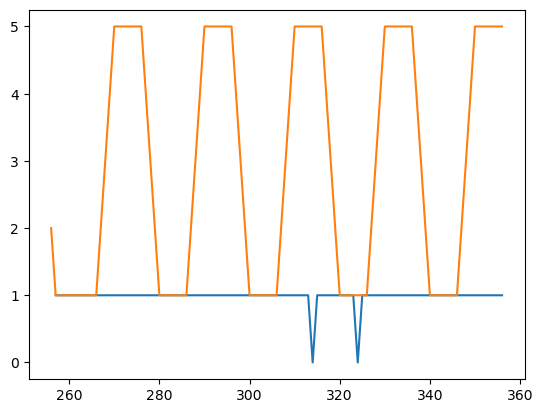

(461, 57) (461,) (51, 57) (51, 57)
Best Model: Epoch 01 | train MSE 1.642216 | val MSE 2.742211
Best Model: Epoch 02 | train MSE 1.497283 | val MSE 2.658820
Epoch 100 | train MSE 0.002074 | val MSE 3.285545
Epoch 200 | train MSE 0.000065 | val MSE 3.422799
Epoch 300 | train MSE 0.000218 | val MSE 3.202020
Epoch 400 | train MSE 0.001709 | val MSE 3.203677
Best Model: Epoch 420 | train MSE 0.045390 | val MSE 2.593956
Epoch 500 | train MSE 0.000020 | val MSE 2.941390
Epoch 600 | train MSE 0.007429 | val MSE 3.035195
Epoch 700 | train MSE 0.005103 | val MSE 2.984667
Epoch 800 | train MSE 0.000750 | val MSE 2.899717
Epoch 900 | train MSE 0.003971 | val MSE 2.780870
Best Model: Epoch 913 | train MSE 0.028234 | val MSE 2.489689
Epoch 1000 | train MSE 0.000075 | val MSE 2.630645
Best Model: Epoch 1064 | train MSE 0.013938 | val MSE 2.225325
Best Model: Epoch 1067 | train MSE 0.013868 | val MSE 1.939549
Best Model: Epoch 1068 | train MSE 0.008673 | val MSE 1.911038
Epoch 1100 | train MSE 0.0035

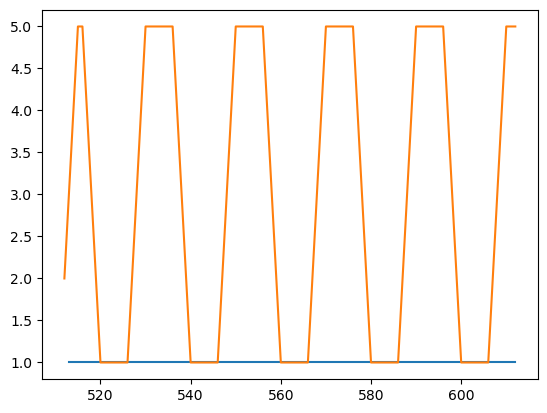

(675, 57) (675,) (75, 57) (75, 57)
Best Model: Epoch 01 | train MSE 1.915677 | val MSE 2.391421
Best Model: Epoch 02 | train MSE 1.303783 | val MSE 2.281234
Epoch 100 | train MSE 0.001897 | val MSE 3.043017
Best Model: Epoch 134 | train MSE 0.032397 | val MSE 2.232377
Epoch 200 | train MSE 0.000061 | val MSE 2.983654
Epoch 300 | train MSE 0.000009 | val MSE 2.921047
Best Model: Epoch 370 | train MSE 0.011653 | val MSE 2.230158
Best Model: Epoch 376 | train MSE 0.008388 | val MSE 2.211845
Best Model: Epoch 378 | train MSE 0.006435 | val MSE 2.205528
Epoch 400 | train MSE 0.000354 | val MSE 2.252934
Best Model: Epoch 493 | train MSE 0.003632 | val MSE 2.188041
Epoch 500 | train MSE 0.001234 | val MSE 2.258469
Best Model: Epoch 592 | train MSE 0.002690 | val MSE 1.840155
Best Model: Epoch 593 | train MSE 0.002473 | val MSE 1.835365
Epoch 600 | train MSE 0.001119 | val MSE 1.844485
Epoch 700 | train MSE 0.000099 | val MSE 1.875870
Epoch 800 | train MSE 0.023092 | val MSE 1.732888
Best Mode

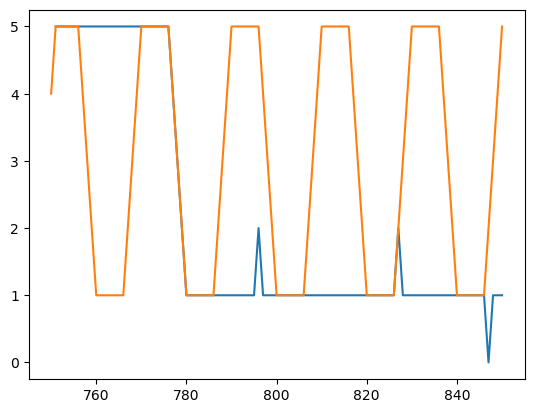

(922, 57) (922,) (102, 57) (102, 57)
Best Model: Epoch 01 | train MSE 1.942452 | val MSE 2.725169
Best Model: Epoch 02 | train MSE 1.236986 | val MSE 2.172870
Best Model: Epoch 04 | train MSE 0.483590 | val MSE 1.618985
Best Model: Epoch 21 | train MSE 0.019031 | val MSE 1.560569
Epoch 100 | train MSE 0.027369 | val MSE 1.612653
Epoch 200 | train MSE 0.010609 | val MSE 1.611444
Best Model: Epoch 202 | train MSE 0.016993 | val MSE 1.557274
Best Model: Epoch 206 | train MSE 0.007372 | val MSE 1.547597
Best Model: Epoch 212 | train MSE 0.005059 | val MSE 1.546114
Epoch 300 | train MSE 0.085160 | val MSE 1.453064
Epoch 400 | train MSE 0.050606 | val MSE 1.483738
Best Model: Epoch 460 | train MSE 0.003210 | val MSE 1.357464
Best Model: Epoch 461 | train MSE 0.002019 | val MSE 1.330248
Best Model: Epoch 467 | train MSE 0.000568 | val MSE 1.329449
Best Model: Epoch 478 | train MSE 0.000082 | val MSE 1.329396
Best Model: Epoch 479 | train MSE 0.000051 | val MSE 1.329197
Best Model: Epoch 480 |

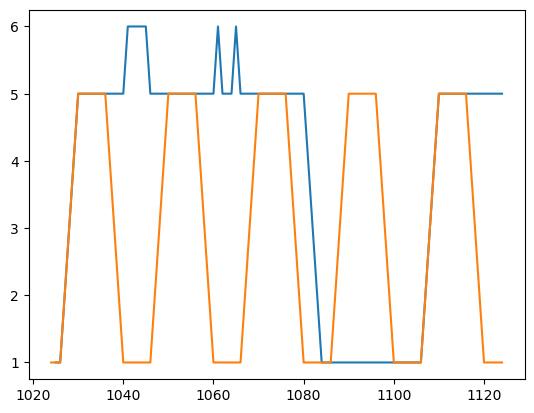

(1125, 57) (1125,) (125, 57) (125, 57)
Best Model: Epoch 01 | train MSE 2.016254 | val MSE 0.868759
Best Model: Epoch 02 | train MSE 1.177531 | val MSE 0.461830
Best Model: Epoch 05 | train MSE 0.243613 | val MSE 0.425421
Best Model: Epoch 07 | train MSE 0.145581 | val MSE 0.367162
Best Model: Epoch 12 | train MSE 0.058164 | val MSE 0.354070
Best Model: Epoch 13 | train MSE 0.027454 | val MSE 0.261625
Best Model: Epoch 16 | train MSE 0.016586 | val MSE 0.240736
Best Model: Epoch 17 | train MSE 0.016057 | val MSE 0.236166
Best Model: Epoch 52 | train MSE 0.012252 | val MSE 0.221726
Best Model: Epoch 70 | train MSE 0.003337 | val MSE 0.207551
Best Model: Epoch 71 | train MSE 0.002441 | val MSE 0.207133
Best Model: Epoch 72 | train MSE 0.001331 | val MSE 0.199240
Best Model: Epoch 75 | train MSE 0.000506 | val MSE 0.198351
Epoch 100 | train MSE 0.000347 | val MSE 0.201181
Best Model: Epoch 103 | train MSE 0.000476 | val MSE 0.198176
Epoch 200 | train MSE 0.011533 | val MSE 0.276167
Epoch 

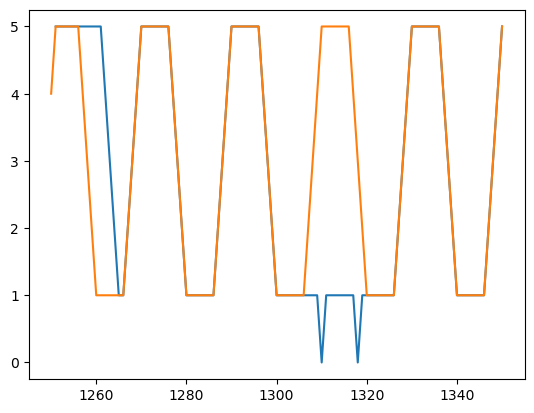

(1350, 57) (1350,) (150, 57) (150, 57)
Best Model: Epoch 01 | train MSE 1.941782 | val MSE 3.160142
Best Model: Epoch 02 | train MSE 1.131057 | val MSE 2.786991
Best Model: Epoch 03 | train MSE 0.663185 | val MSE 2.697014
Best Model: Epoch 04 | train MSE 0.321867 | val MSE 2.048991
Best Model: Epoch 05 | train MSE 0.313093 | val MSE 1.902834
Best Model: Epoch 08 | train MSE 0.108882 | val MSE 1.612323
Best Model: Epoch 15 | train MSE 0.054103 | val MSE 1.573799
Best Model: Epoch 17 | train MSE 0.025163 | val MSE 1.481336
Best Model: Epoch 26 | train MSE 0.018435 | val MSE 1.461827
Best Model: Epoch 34 | train MSE 0.011483 | val MSE 1.420950
Best Model: Epoch 59 | train MSE 0.009690 | val MSE 1.156153
Best Model: Epoch 60 | train MSE 0.005767 | val MSE 1.155944
Best Model: Epoch 63 | train MSE 0.002090 | val MSE 1.110330
Best Model: Epoch 96 | train MSE 0.001130 | val MSE 1.093687
Epoch 100 | train MSE 0.001911 | val MSE 1.170744
Best Model: Epoch 170 | train MSE 0.001069 | val MSE 0.94

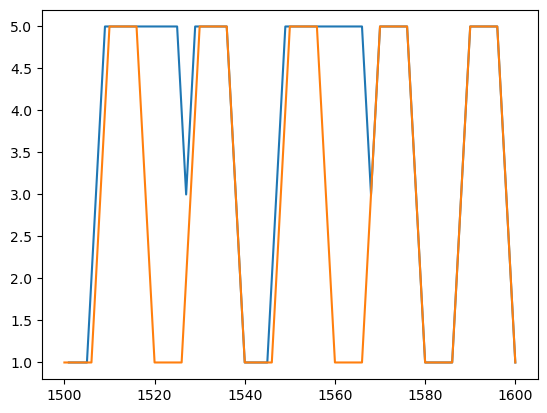

(1844, 57) (1844,) (204, 57) (204, 57)
Best Model: Epoch 01 | train MSE 1.961710 | val MSE 1.445759
Best Model: Epoch 02 | train MSE 1.066607 | val MSE 1.437940
Best Model: Epoch 03 | train MSE 0.482291 | val MSE 1.385261
Best Model: Epoch 04 | train MSE 0.329431 | val MSE 1.213658
Best Model: Epoch 05 | train MSE 0.206326 | val MSE 0.930671
Best Model: Epoch 07 | train MSE 0.134108 | val MSE 0.891954
Best Model: Epoch 15 | train MSE 0.023525 | val MSE 0.847070
Best Model: Epoch 19 | train MSE 0.013301 | val MSE 0.843158
Best Model: Epoch 34 | train MSE 0.011545 | val MSE 0.783897
Best Model: Epoch 35 | train MSE 0.009698 | val MSE 0.765224
Best Model: Epoch 37 | train MSE 0.003991 | val MSE 0.758726
Best Model: Epoch 41 | train MSE 0.003890 | val MSE 0.740854
Best Model: Epoch 43 | train MSE 0.003099 | val MSE 0.728156
Best Model: Epoch 67 | train MSE 0.002761 | val MSE 0.595224
Best Model: Epoch 70 | train MSE 0.001923 | val MSE 0.584239
Best Model: Epoch 71 | train MSE 0.001492 | va

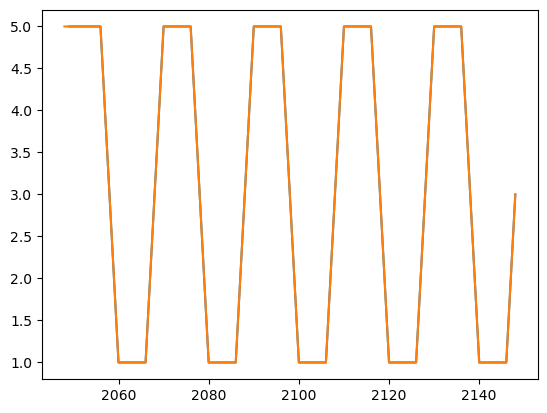

(3687, 57) (3687,) (409, 57) (409, 57)
Best Model: Epoch 01 | train MSE 1.637251 | val MSE 0.991965
Best Model: Epoch 02 | train MSE 0.655995 | val MSE 0.346658
Best Model: Epoch 03 | train MSE 0.264046 | val MSE 0.187004
Best Model: Epoch 04 | train MSE 0.175774 | val MSE 0.154935
Best Model: Epoch 06 | train MSE 0.033671 | val MSE 0.132235
Best Model: Epoch 07 | train MSE 0.023836 | val MSE 0.082674
Best Model: Epoch 08 | train MSE 0.017790 | val MSE 0.050348
Best Model: Epoch 27 | train MSE 0.012565 | val MSE 0.018645
Best Model: Epoch 28 | train MSE 0.009107 | val MSE 0.018294
Best Model: Epoch 30 | train MSE 0.002231 | val MSE 0.017746
Best Model: Epoch 31 | train MSE 0.001949 | val MSE 0.013032
Best Model: Epoch 62 | train MSE 0.001792 | val MSE 0.009397
Best Model: Epoch 63 | train MSE 0.001495 | val MSE 0.008369
Best Model: Epoch 69 | train MSE 0.000946 | val MSE 0.008283
Best Model: Epoch 70 | train MSE 0.000678 | val MSE 0.007294
Best Model: Epoch 71 | train MSE 0.000491 | va

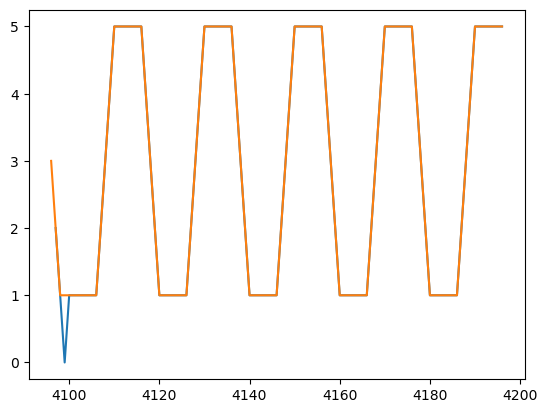

(116, 57) (116,) (12, 57) (12, 57)
Best Model: Epoch 01 | train MSE 4.103697 | val MSE 0.810211
Best Model: Epoch 02 | train MSE 3.313645 | val MSE 0.445644
Best Model: Epoch 03 | train MSE 2.591898 | val MSE 0.167223
Best Model: Epoch 06 | train MSE 1.156939 | val MSE 0.100631
Epoch 100 | train MSE 0.000048 | val MSE 0.175099
Best Model: Epoch 178 | train MSE 0.223818 | val MSE 0.046116
Epoch 200 | train MSE 0.034843 | val MSE 0.378783
Epoch 300 | train MSE 0.000054 | val MSE 0.415650
Epoch 400 | train MSE 0.000000 | val MSE 0.413728
Epoch 500 | train MSE 0.000000 | val MSE 0.413716
Epoch 600 | train MSE 0.000007 | val MSE 0.413848
Epoch 700 | train MSE 0.009266 | val MSE 0.469577
Epoch 800 | train MSE 0.000097 | val MSE 0.516440
Epoch 900 | train MSE 0.000097 | val MSE 0.516481
Epoch 1000 | train MSE 0.000227 | val MSE 0.510426
Epoch 1100 | train MSE 0.012560 | val MSE 0.545594
Epoch 1200 | train MSE 0.001569 | val MSE 0.526224
Epoch 1300 | train MSE 0.000003 | val MSE 0.508271
Epoch

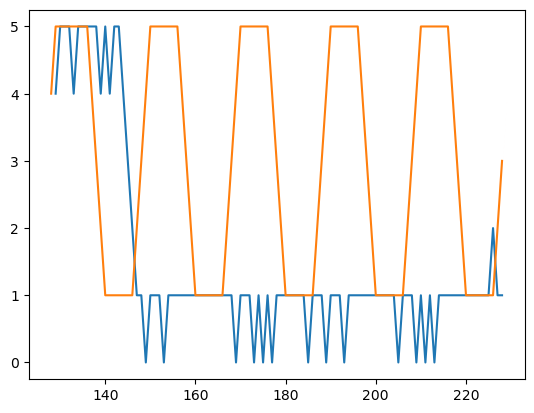

(231, 57) (231,) (25, 57) (25, 57)
Best Model: Epoch 01 | train MSE 3.187019 | val MSE 0.636842
Epoch 100 | train MSE 0.001740 | val MSE 1.188040
Best Model: Epoch 167 | train MSE 0.338048 | val MSE 0.498529
Best Model: Epoch 174 | train MSE 0.080351 | val MSE 0.441347
Epoch 200 | train MSE 0.000623 | val MSE 1.802539
Epoch 300 | train MSE 0.000003 | val MSE 1.795425
Epoch 400 | train MSE 0.000003 | val MSE 1.801364
Epoch 500 | train MSE 0.073658 | val MSE 1.622797
Epoch 600 | train MSE 0.001222 | val MSE 1.941553
Epoch 700 | train MSE 0.001436 | val MSE 1.942086
Epoch 800 | train MSE 0.001236 | val MSE 1.942870
Epoch 900 | train MSE 0.003676 | val MSE 2.416060
Epoch 1000 | train MSE 0.001224 | val MSE 2.375007
Epoch 1100 | train MSE 0.001246 | val MSE 2.378732
Epoch 1200 | train MSE 0.001753 | val MSE 2.379534
Epoch 1300 | train MSE 0.010771 | val MSE 2.428054
Epoch 1400 | train MSE 0.001196 | val MSE 2.562332
Epoch 1500 | train MSE 0.023751 | val MSE 1.672514
Epoch 1600 | train MSE 0

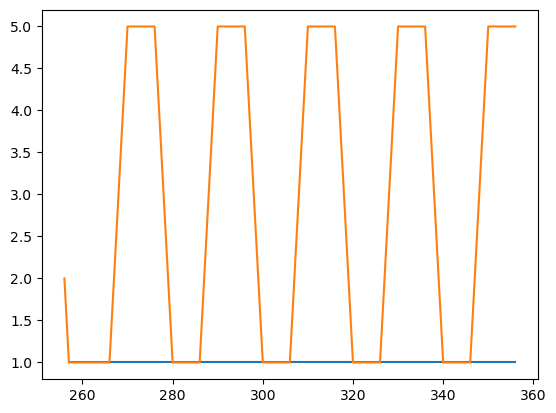

(461, 57) (461,) (51, 57) (51, 57)
Best Model: Epoch 01 | train MSE 2.296145 | val MSE 1.007094
Best Model: Epoch 02 | train MSE 1.564079 | val MSE 0.707724
Best Model: Epoch 03 | train MSE 0.929847 | val MSE 0.699105
Best Model: Epoch 04 | train MSE 0.542586 | val MSE 0.528852
Best Model: Epoch 05 | train MSE 0.241667 | val MSE 0.480245
Best Model: Epoch 13 | train MSE 0.213875 | val MSE 0.443326
Best Model: Epoch 20 | train MSE 0.022622 | val MSE 0.440314
Best Model: Epoch 21 | train MSE 0.015768 | val MSE 0.431254
Best Model: Epoch 22 | train MSE 0.011018 | val MSE 0.424912
Best Model: Epoch 27 | train MSE 0.005331 | val MSE 0.417580
Best Model: Epoch 29 | train MSE 0.002826 | val MSE 0.405639
Epoch 100 | train MSE 0.085472 | val MSE 0.413250
Epoch 200 | train MSE 0.025717 | val MSE 0.738388
Epoch 300 | train MSE 0.000036 | val MSE 0.630995
Epoch 400 | train MSE 0.000244 | val MSE 0.726263
Epoch 500 | train MSE 0.000023 | val MSE 0.733192
Epoch 600 | train MSE 0.000298 | val MSE 1.1

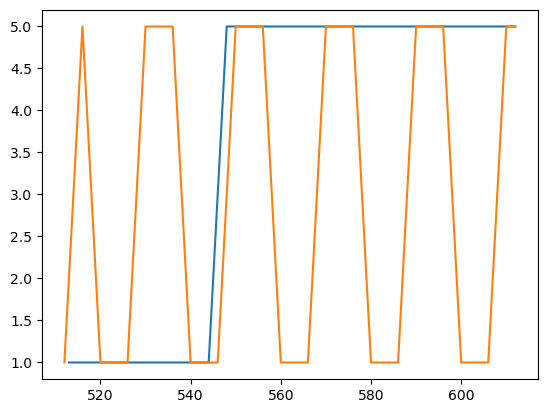

(675, 57) (675,) (75, 57) (75, 57)
Best Model: Epoch 01 | train MSE 2.294653 | val MSE 0.487561
Best Model: Epoch 02 | train MSE 1.654027 | val MSE 0.237131
Best Model: Epoch 03 | train MSE 1.060101 | val MSE 0.120157
Best Model: Epoch 04 | train MSE 0.397842 | val MSE 0.088733
Best Model: Epoch 05 | train MSE 0.324054 | val MSE 0.049538
Best Model: Epoch 17 | train MSE 0.089008 | val MSE 0.044143
Best Model: Epoch 23 | train MSE 0.004967 | val MSE 0.042510
Epoch 100 | train MSE 0.244833 | val MSE 0.123882
Epoch 200 | train MSE 0.116125 | val MSE 0.196087
Epoch 300 | train MSE 0.048733 | val MSE 0.408571
Epoch 400 | train MSE 0.045098 | val MSE 0.518003
Epoch 500 | train MSE 0.026314 | val MSE 0.491026
Epoch 600 | train MSE 0.015376 | val MSE 0.622978
Epoch 700 | train MSE 0.001682 | val MSE 0.567792
Epoch 800 | train MSE 0.007171 | val MSE 0.545475
Epoch 900 | train MSE 0.006228 | val MSE 0.628239
Epoch 1000 | train MSE 0.009108 | val MSE 0.633307
Epoch 1100 | train MSE 0.047529 | val

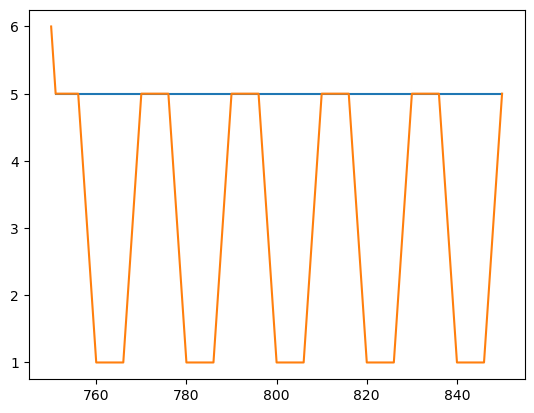

(922, 57) (922,) (102, 57) (102, 57)
Best Model: Epoch 01 | train MSE 2.269291 | val MSE 2.137090
Best Model: Epoch 02 | train MSE 1.536535 | val MSE 1.638764
Best Model: Epoch 05 | train MSE 0.465015 | val MSE 1.546126
Best Model: Epoch 06 | train MSE 0.269976 | val MSE 1.227430
Best Model: Epoch 10 | train MSE 0.208092 | val MSE 1.202928
Best Model: Epoch 25 | train MSE 0.055302 | val MSE 1.170537
Best Model: Epoch 30 | train MSE 0.020183 | val MSE 1.167685
Best Model: Epoch 53 | train MSE 0.010216 | val MSE 1.142494
Best Model: Epoch 77 | train MSE 0.004411 | val MSE 1.110651
Epoch 100 | train MSE 0.005898 | val MSE 1.156806
Epoch 200 | train MSE 0.002101 | val MSE 1.234071
Epoch 300 | train MSE 0.027661 | val MSE 1.116034
Epoch 400 | train MSE 0.032056 | val MSE 1.104904
Epoch 500 | train MSE 0.027972 | val MSE 1.079885
Epoch 600 | train MSE 0.051639 | val MSE 1.019190
Epoch 700 | train MSE 0.048190 | val MSE 1.186099
Epoch 800 | train MSE 0.028352 | val MSE 0.942050
Epoch 900 | tr

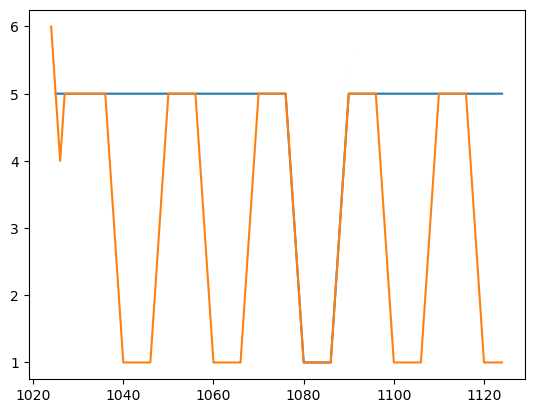

(1125, 57) (1125,) (125, 57) (125, 57)
Best Model: Epoch 01 | train MSE 2.235902 | val MSE 1.088500
Best Model: Epoch 02 | train MSE 1.402956 | val MSE 0.639592
Best Model: Epoch 04 | train MSE 0.669877 | val MSE 0.256436
Best Model: Epoch 06 | train MSE 0.180173 | val MSE 0.251826
Best Model: Epoch 07 | train MSE 0.094853 | val MSE 0.167674
Best Model: Epoch 16 | train MSE 0.052351 | val MSE 0.152446
Best Model: Epoch 77 | train MSE 0.040181 | val MSE 0.151511
Best Model: Epoch 83 | train MSE 0.016948 | val MSE 0.149957
Best Model: Epoch 85 | train MSE 0.007871 | val MSE 0.144970
Best Model: Epoch 89 | train MSE 0.000765 | val MSE 0.143611
Epoch 100 | train MSE 0.000512 | val MSE 0.152981
Epoch 200 | train MSE 0.000160 | val MSE 0.204325
Epoch 300 | train MSE 0.003417 | val MSE 0.138060
Epoch 400 | train MSE 0.000983 | val MSE 0.129712
Epoch 500 | train MSE 0.000758 | val MSE 0.168120
Best Model: Epoch 586 | train MSE 0.000750 | val MSE 0.130654
Best Model: Epoch 587 | train MSE 0.000

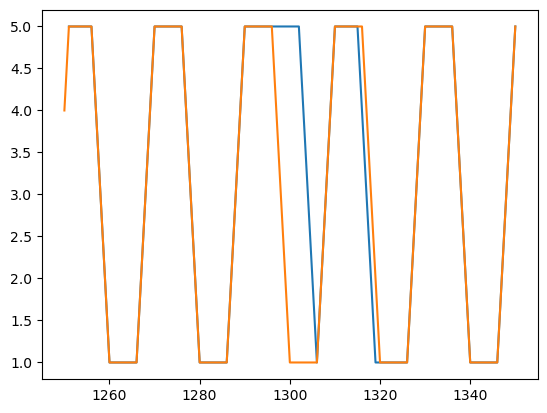

(1350, 57) (1350,) (150, 57) (150, 57)
Best Model: Epoch 01 | train MSE 1.965841 | val MSE 2.300884
Best Model: Epoch 07 | train MSE 0.162090 | val MSE 2.220020
Best Model: Epoch 10 | train MSE 0.089084 | val MSE 2.065064
Best Model: Epoch 48 | train MSE 0.072102 | val MSE 1.725203
Epoch 100 | train MSE 0.055817 | val MSE 1.927909
Epoch 200 | train MSE 0.010326 | val MSE 2.146571
Best Model: Epoch 249 | train MSE 0.013311 | val MSE 1.716684
Best Model: Epoch 282 | train MSE 0.010711 | val MSE 1.555351
Best Model: Epoch 283 | train MSE 0.005726 | val MSE 1.532435
Best Model: Epoch 286 | train MSE 0.001683 | val MSE 1.531742
Best Model: Epoch 287 | train MSE 0.001121 | val MSE 1.526264
Best Model: Epoch 290 | train MSE 0.000575 | val MSE 1.519904
Epoch 300 | train MSE 0.000503 | val MSE 1.526787
Best Model: Epoch 301 | train MSE 0.000464 | val MSE 1.517483
Best Model: Epoch 320 | train MSE 0.000354 | val MSE 1.515782
Best Model: Epoch 322 | train MSE 0.000319 | val MSE 1.515335
Best Mode

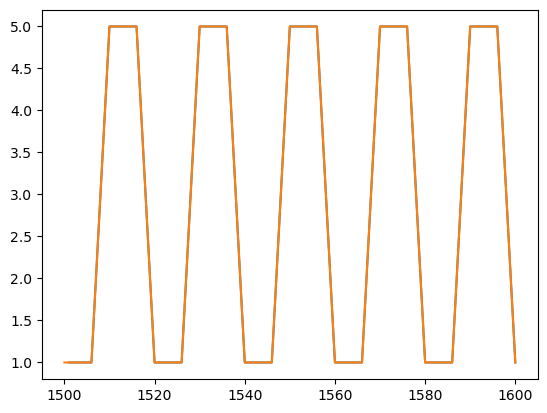

(1844, 57) (1844,) (204, 57) (204, 57)
Best Model: Epoch 01 | train MSE 1.922664 | val MSE 1.489583
Best Model: Epoch 02 | train MSE 1.063923 | val MSE 1.309117
Best Model: Epoch 03 | train MSE 0.668377 | val MSE 0.846536
Best Model: Epoch 04 | train MSE 0.394088 | val MSE 0.514798
Best Model: Epoch 06 | train MSE 0.123076 | val MSE 0.502565
Best Model: Epoch 07 | train MSE 0.059665 | val MSE 0.431552
Best Model: Epoch 08 | train MSE 0.042263 | val MSE 0.399431
Best Model: Epoch 09 | train MSE 0.027013 | val MSE 0.322736
Best Model: Epoch 10 | train MSE 0.017502 | val MSE 0.316442
Best Model: Epoch 28 | train MSE 0.016929 | val MSE 0.193597
Best Model: Epoch 34 | train MSE 0.008039 | val MSE 0.181859
Best Model: Epoch 57 | train MSE 0.007371 | val MSE 0.140610
Best Model: Epoch 61 | train MSE 0.002860 | val MSE 0.122008
Best Model: Epoch 62 | train MSE 0.002397 | val MSE 0.121071
Best Model: Epoch 63 | train MSE 0.001522 | val MSE 0.119188
Best Model: Epoch 65 | train MSE 0.001301 | va

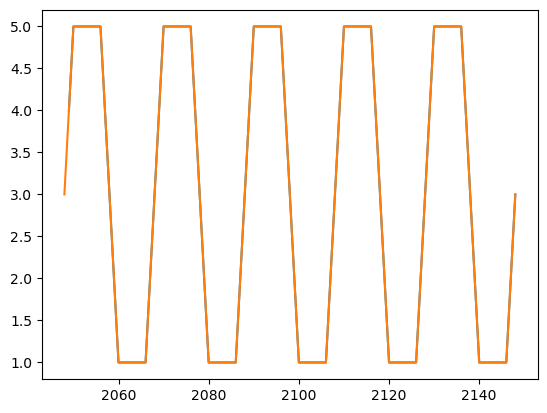

(3687, 57) (3687,) (409, 57) (409, 57)
Best Model: Epoch 01 | train MSE 1.682722 | val MSE 1.287634
Best Model: Epoch 02 | train MSE 0.793728 | val MSE 0.609878
Best Model: Epoch 03 | train MSE 0.266367 | val MSE 0.341706
Best Model: Epoch 04 | train MSE 0.164791 | val MSE 0.319176
Best Model: Epoch 05 | train MSE 0.089530 | val MSE 0.233110
Best Model: Epoch 06 | train MSE 0.057400 | val MSE 0.199179
Best Model: Epoch 07 | train MSE 0.038364 | val MSE 0.183493
Best Model: Epoch 08 | train MSE 0.035954 | val MSE 0.132668
Best Model: Epoch 10 | train MSE 0.019539 | val MSE 0.107867
Best Model: Epoch 12 | train MSE 0.010239 | val MSE 0.100247
Best Model: Epoch 16 | train MSE 0.008777 | val MSE 0.080176
Best Model: Epoch 34 | train MSE 0.007778 | val MSE 0.018284
Best Model: Epoch 38 | train MSE 0.002394 | val MSE 0.016253
Best Model: Epoch 39 | train MSE 0.001603 | val MSE 0.013307
Best Model: Epoch 41 | train MSE 0.000623 | val MSE 0.012087
Epoch 100 | train MSE 0.007387 | val MSE 0.009

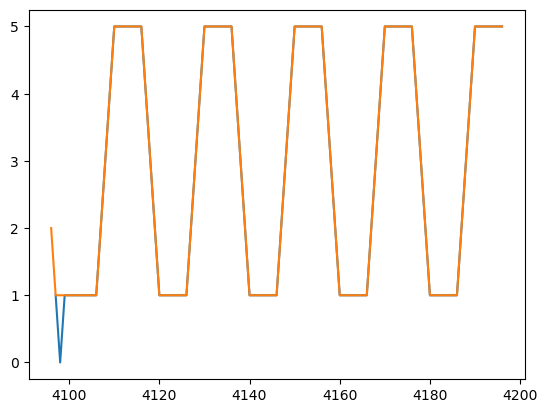

(116, 57) (116,) (12, 57) (12, 57)
Best Model: Epoch 01 | train MSE 1.998040 | val MSE 0.223409
Best Model: Epoch 02 | train MSE 1.716227 | val MSE 0.129931
Best Model: Epoch 03 | train MSE 1.270169 | val MSE 0.087782
Best Model: Epoch 04 | train MSE 1.020317 | val MSE 0.079457
Best Model: Epoch 05 | train MSE 0.648130 | val MSE 0.064531
Best Model: Epoch 06 | train MSE 0.436022 | val MSE 0.033818
Best Model: Epoch 07 | train MSE 0.271862 | val MSE 0.017273
Best Model: Epoch 09 | train MSE 0.161432 | val MSE 0.007699
Best Model: Epoch 13 | train MSE 0.104238 | val MSE 0.004181
Best Model: Epoch 18 | train MSE 0.077290 | val MSE 0.002291
Best Model: Epoch 28 | train MSE 0.018156 | val MSE 0.002254
Best Model: Epoch 31 | train MSE 0.004160 | val MSE 0.002161
Best Model: Epoch 32 | train MSE 0.002788 | val MSE 0.001691
Epoch 100 | train MSE 0.000028 | val MSE 0.001704
Best Model: Epoch 103 | train MSE 0.000026 | val MSE 0.001681
Best Model: Epoch 107 | train MSE 0.000023 | val MSE 0.00167

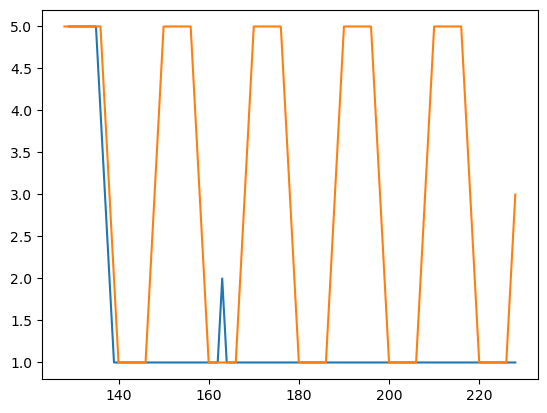

(231, 57) (231,) (25, 57) (25, 57)
Best Model: Epoch 01 | train MSE 2.576789 | val MSE 5.415104
Best Model: Epoch 02 | train MSE 1.610155 | val MSE 4.878633
Best Model: Epoch 03 | train MSE 1.105216 | val MSE 4.807391
Best Model: Epoch 04 | train MSE 0.717697 | val MSE 4.626075
Best Model: Epoch 08 | train MSE 0.101847 | val MSE 4.566569
Best Model: Epoch 10 | train MSE 0.070229 | val MSE 4.076524
Best Model: Epoch 15 | train MSE 0.061072 | val MSE 3.775107
Best Model: Epoch 18 | train MSE 0.044282 | val MSE 3.387557
Epoch 100 | train MSE 0.000173 | val MSE 3.846843
Best Model: Epoch 181 | train MSE 0.031479 | val MSE 3.217224
Best Model: Epoch 182 | train MSE 0.026794 | val MSE 3.213639
Best Model: Epoch 183 | train MSE 0.019590 | val MSE 3.078264
Best Model: Epoch 185 | train MSE 0.014436 | val MSE 2.957375
Epoch 200 | train MSE 0.049231 | val MSE 2.611092
Best Model: Epoch 209 | train MSE 0.012469 | val MSE 2.721854
Best Model: Epoch 212 | train MSE 0.005765 | val MSE 2.510042
Epoch

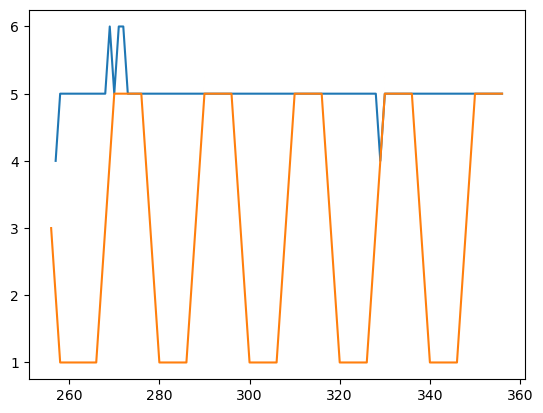

(461, 57) (461,) (51, 57) (51, 57)
Best Model: Epoch 01 | train MSE 1.795733 | val MSE 2.386947
Best Model: Epoch 02 | train MSE 1.542579 | val MSE 1.870617
Best Model: Epoch 03 | train MSE 0.846578 | val MSE 1.131457
Best Model: Epoch 07 | train MSE 0.214323 | val MSE 1.003312
Best Model: Epoch 11 | train MSE 0.161668 | val MSE 0.853720
Epoch 100 | train MSE 0.132508 | val MSE 1.722443
Epoch 200 | train MSE 0.006319 | val MSE 1.381865
Epoch 300 | train MSE 0.069411 | val MSE 1.686863
Epoch 400 | train MSE 0.001102 | val MSE 1.244677
Epoch 500 | train MSE 0.000409 | val MSE 1.275737
Epoch 600 | train MSE 0.000595 | val MSE 1.298841
Epoch 700 | train MSE 0.013824 | val MSE 1.179854
Epoch 800 | train MSE 0.000664 | val MSE 1.331254
Epoch 900 | train MSE 0.011978 | val MSE 1.365210
Epoch 1000 | train MSE 0.076361 | val MSE 1.136630
Epoch 1100 | train MSE 0.007465 | val MSE 1.345569
Epoch 1200 | train MSE 0.011319 | val MSE 1.686031
Epoch 1300 | train MSE 0.007203 | val MSE 1.599637
Epoch 

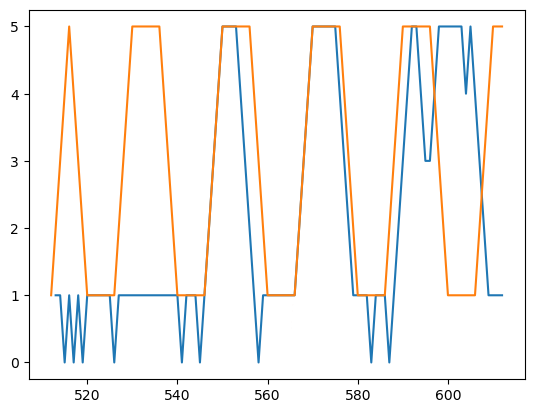

(675, 57) (675,) (75, 57) (75, 57)
Best Model: Epoch 01 | train MSE 1.706262 | val MSE 0.660144
Best Model: Epoch 02 | train MSE 1.165202 | val MSE 0.548062
Best Model: Epoch 03 | train MSE 0.658222 | val MSE 0.463165
Best Model: Epoch 05 | train MSE 0.528616 | val MSE 0.461569
Best Model: Epoch 07 | train MSE 0.388450 | val MSE 0.375684
Best Model: Epoch 08 | train MSE 0.283571 | val MSE 0.330571
Best Model: Epoch 09 | train MSE 0.145706 | val MSE 0.321557
Epoch 100 | train MSE 0.003436 | val MSE 0.454831
Epoch 200 | train MSE 0.060679 | val MSE 0.526190
Epoch 300 | train MSE 0.001114 | val MSE 0.541172
Epoch 400 | train MSE 0.148938 | val MSE 0.380305
Epoch 500 | train MSE 0.191177 | val MSE 0.393549
Epoch 600 | train MSE 0.148587 | val MSE 0.389838
Epoch 700 | train MSE 0.143954 | val MSE 0.354113
Epoch 800 | train MSE 0.216494 | val MSE 0.408158
Epoch 900 | train MSE 0.144376 | val MSE 0.335516
Epoch 1000 | train MSE 0.143374 | val MSE 0.450318
Epoch 1100 | train MSE 0.152116 | val

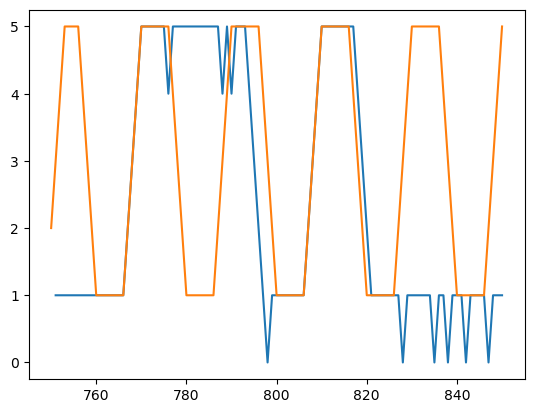

(922, 57) (922,) (102, 57) (102, 57)
Best Model: Epoch 01 | train MSE 1.487446 | val MSE 0.437347
Epoch 100 | train MSE 0.013169 | val MSE 1.047004
Epoch 200 | train MSE 0.004844 | val MSE 1.134383
Epoch 300 | train MSE 0.000086 | val MSE 0.847065
Epoch 400 | train MSE 0.000334 | val MSE 0.842256
Best Model: Epoch 448 | train MSE 0.021992 | val MSE 0.431326
Epoch 500 | train MSE 0.002275 | val MSE 0.863675
Epoch 600 | train MSE 0.073380 | val MSE 1.041795
Epoch 700 | train MSE 0.004114 | val MSE 0.846650
Epoch 800 | train MSE 0.001872 | val MSE 0.743601
Epoch 900 | train MSE 0.006018 | val MSE 0.558071
Epoch 1000 | train MSE 0.000320 | val MSE 0.556499
Epoch 1100 | train MSE 0.000057 | val MSE 0.577823
Epoch 1200 | train MSE 0.000085 | val MSE 0.521045
Epoch 1300 | train MSE 0.001865 | val MSE 0.566208
Best Model: Epoch 1318 | train MSE 0.018564 | val MSE 0.335475
Epoch 1400 | train MSE 0.000763 | val MSE 0.408131
Epoch 1500 | train MSE 0.026083 | val MSE 0.405452
Best Model: Epoch 150

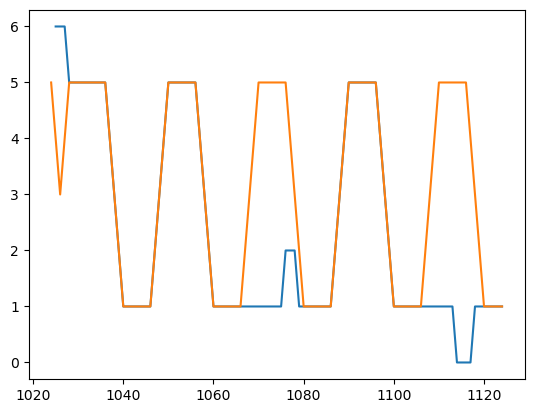

(1125, 57) (1125,) (125, 57) (125, 57)
Best Model: Epoch 01 | train MSE 1.579896 | val MSE 2.753000
Best Model: Epoch 02 | train MSE 1.112654 | val MSE 2.385884
Best Model: Epoch 08 | train MSE 0.105912 | val MSE 2.278257
Best Model: Epoch 09 | train MSE 0.062701 | val MSE 2.221500
Best Model: Epoch 14 | train MSE 0.027271 | val MSE 2.206450
Best Model: Epoch 15 | train MSE 0.019744 | val MSE 2.204717
Best Model: Epoch 24 | train MSE 0.016040 | val MSE 2.032571
Best Model: Epoch 40 | train MSE 0.014297 | val MSE 1.830868
Best Model: Epoch 78 | train MSE 0.013785 | val MSE 1.827169
Best Model: Epoch 79 | train MSE 0.011821 | val MSE 1.804501
Best Model: Epoch 83 | train MSE 0.010553 | val MSE 1.795770
Epoch 100 | train MSE 0.007382 | val MSE 1.823525
Best Model: Epoch 195 | train MSE 0.005399 | val MSE 1.793839
Epoch 200 | train MSE 0.004348 | val MSE 1.811373
Epoch 300 | train MSE 0.009345 | val MSE 1.579849
Epoch 400 | train MSE 0.007523 | val MSE 1.675822
Epoch 500 | train MSE 0.0940

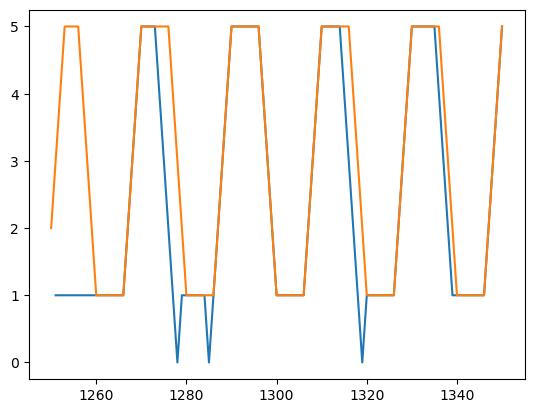

(1350, 57) (1350,) (150, 57) (150, 57)
Best Model: Epoch 01 | train MSE 1.582721 | val MSE 0.994163
Best Model: Epoch 02 | train MSE 1.078055 | val MSE 0.528798
Best Model: Epoch 03 | train MSE 0.656041 | val MSE 0.431441
Best Model: Epoch 05 | train MSE 0.578053 | val MSE 0.249629
Best Model: Epoch 07 | train MSE 0.160607 | val MSE 0.226868
Best Model: Epoch 09 | train MSE 0.058408 | val MSE 0.222260
Best Model: Epoch 11 | train MSE 0.039157 | val MSE 0.207088
Best Model: Epoch 19 | train MSE 0.026195 | val MSE 0.189754
Best Model: Epoch 21 | train MSE 0.016805 | val MSE 0.176005
Epoch 100 | train MSE 0.000619 | val MSE 0.210794
Epoch 200 | train MSE 0.004435 | val MSE 0.284110
Epoch 300 | train MSE 0.001941 | val MSE 0.257077
Epoch 400 | train MSE 0.012778 | val MSE 0.264610
Epoch 500 | train MSE 0.038126 | val MSE 0.319200
Epoch 600 | train MSE 0.012963 | val MSE 0.184921
Best Model: Epoch 631 | train MSE 0.016016 | val MSE 0.166402
Epoch 700 | train MSE 0.014273 | val MSE 0.203556


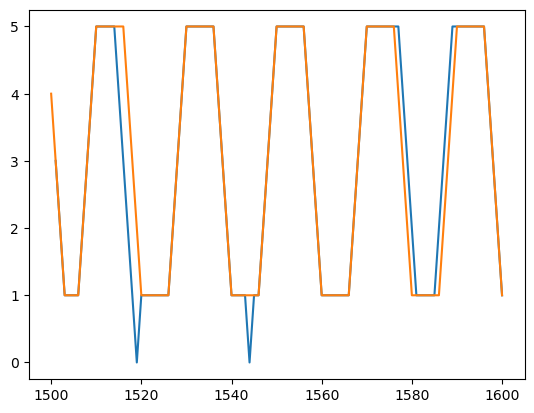

(1844, 57) (1844,) (204, 57) (204, 57)
Best Model: Epoch 01 | train MSE 1.680928 | val MSE 2.303749
Best Model: Epoch 02 | train MSE 1.057078 | val MSE 1.698070
Best Model: Epoch 03 | train MSE 0.529496 | val MSE 1.008818
Best Model: Epoch 19 | train MSE 0.042320 | val MSE 0.968208
Best Model: Epoch 20 | train MSE 0.026632 | val MSE 0.816934
Best Model: Epoch 30 | train MSE 0.026380 | val MSE 0.776670
Best Model: Epoch 35 | train MSE 0.016622 | val MSE 0.773735
Best Model: Epoch 36 | train MSE 0.014743 | val MSE 0.744225
Best Model: Epoch 43 | train MSE 0.010772 | val MSE 0.691832
Best Model: Epoch 70 | train MSE 0.008365 | val MSE 0.503734
Best Model: Epoch 71 | train MSE 0.007311 | val MSE 0.487482
Best Model: Epoch 73 | train MSE 0.005487 | val MSE 0.483382
Best Model: Epoch 74 | train MSE 0.003966 | val MSE 0.438461
Best Model: Epoch 91 | train MSE 0.002788 | val MSE 0.433117
Epoch 100 | train MSE 0.028729 | val MSE 0.457078
Best Model: Epoch 120 | train MSE 0.002201 | val MSE 0.38

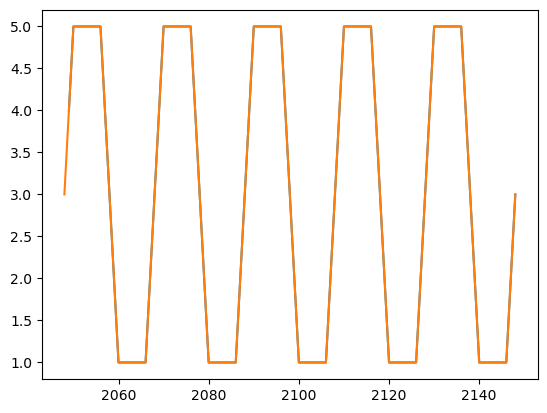

(3687, 57) (3687,) (409, 57) (409, 57)
Best Model: Epoch 01 | train MSE 1.689230 | val MSE 1.415257
Best Model: Epoch 02 | train MSE 0.736543 | val MSE 0.447799
Best Model: Epoch 03 | train MSE 0.238633 | val MSE 0.178780
Best Model: Epoch 05 | train MSE 0.096314 | val MSE 0.156479
Best Model: Epoch 06 | train MSE 0.062830 | val MSE 0.093686
Best Model: Epoch 08 | train MSE 0.040179 | val MSE 0.087533
Best Model: Epoch 11 | train MSE 0.019861 | val MSE 0.026347
Best Model: Epoch 37 | train MSE 0.010084 | val MSE 0.014131
Best Model: Epoch 40 | train MSE 0.008594 | val MSE 0.013184
Best Model: Epoch 42 | train MSE 0.004285 | val MSE 0.010186
Best Model: Epoch 46 | train MSE 0.002159 | val MSE 0.006294
Best Model: Epoch 91 | train MSE 0.000515 | val MSE 0.004465
Best Model: Epoch 92 | train MSE 0.000482 | val MSE 0.004246
Epoch 100 | train MSE 0.000151 | val MSE 0.007684
Epoch 200 | train MSE 0.007474 | val MSE 0.006150
Best Model: Epoch 286 | train MSE 0.000324 | val MSE 0.003486
Best M

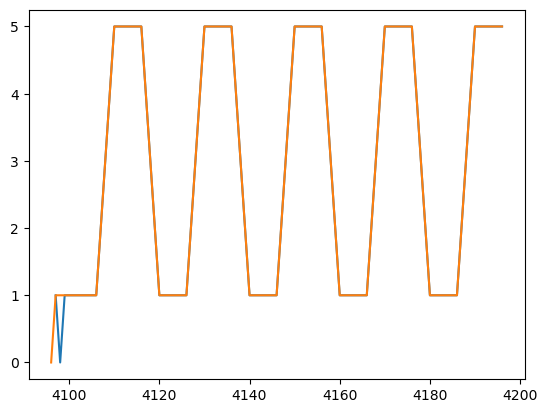

(116, 57) (116,) (12, 57) (12, 57)
Best Model: Epoch 01 | train MSE 2.353757 | val MSE 0.274047
Best Model: Epoch 02 | train MSE 1.989677 | val MSE 0.077599
Best Model: Epoch 04 | train MSE 1.393313 | val MSE 0.052411
Best Model: Epoch 05 | train MSE 1.180094 | val MSE 0.036407
Best Model: Epoch 28 | train MSE 0.006744 | val MSE 0.034087
Best Model: Epoch 40 | train MSE 0.002982 | val MSE 0.031590
Best Model: Epoch 61 | train MSE 0.001567 | val MSE 0.031217
Epoch 100 | train MSE 0.001460 | val MSE 0.029514
Best Model: Epoch 100 | train MSE 0.001460 | val MSE 0.029514
Best Model: Epoch 130 | train MSE 0.000961 | val MSE 0.029107
Best Model: Epoch 153 | train MSE 0.000680 | val MSE 0.028050
Epoch 200 | train MSE 0.284477 | val MSE 0.030797
Best Model: Epoch 229 | train MSE 0.000577 | val MSE 0.020529
Best Model: Epoch 241 | train MSE 0.000446 | val MSE 0.019989
Epoch 300 | train MSE 0.000194 | val MSE 0.019359
Best Model: Epoch 300 | train MSE 0.000194 | val MSE 0.019359
Best Model: Epoc

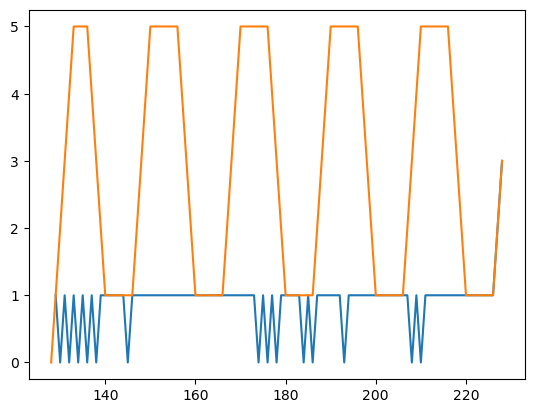

(231, 57) (231,) (25, 57) (25, 57)
Best Model: Epoch 01 | train MSE 2.128274 | val MSE 4.562481
Best Model: Epoch 02 | train MSE 1.357991 | val MSE 4.217035
Best Model: Epoch 03 | train MSE 1.345218 | val MSE 3.188881
Best Model: Epoch 04 | train MSE 0.947741 | val MSE 1.771885
Best Model: Epoch 06 | train MSE 0.373102 | val MSE 1.561230
Best Model: Epoch 07 | train MSE 0.338145 | val MSE 1.176001
Best Model: Epoch 22 | train MSE 0.042190 | val MSE 1.143353
Epoch 100 | train MSE 0.000637 | val MSE 1.349550
Best Model: Epoch 171 | train MSE 0.012382 | val MSE 1.031428
Epoch 200 | train MSE 0.019584 | val MSE 1.527874
Epoch 300 | train MSE 0.006284 | val MSE 1.446328
Epoch 400 | train MSE 0.002525 | val MSE 1.362433
Epoch 500 | train MSE 0.000000 | val MSE 1.408087
Epoch 600 | train MSE 0.000000 | val MSE 1.407093
Best Model: Epoch 670 | train MSE 0.011949 | val MSE 0.943907
Epoch 700 | train MSE 0.004888 | val MSE 1.334832
Epoch 800 | train MSE 0.000000 | val MSE 1.308914
Epoch 900 | tr

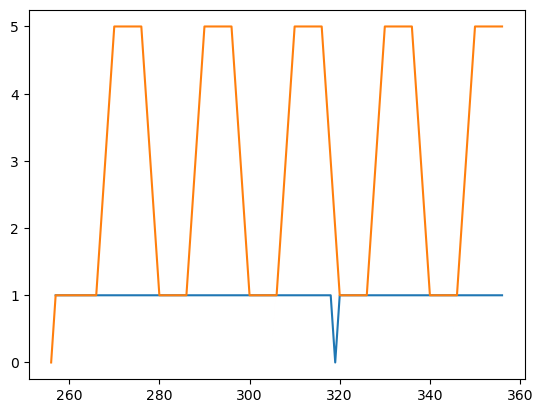

(461, 57) (461,) (51, 57) (51, 57)
Best Model: Epoch 01 | train MSE 2.076944 | val MSE 0.794372
Best Model: Epoch 03 | train MSE 0.766877 | val MSE 0.490030
Best Model: Epoch 06 | train MSE 0.726314 | val MSE 0.283440
Best Model: Epoch 07 | train MSE 0.666725 | val MSE 0.161124
Best Model: Epoch 08 | train MSE 0.238897 | val MSE 0.119703
Best Model: Epoch 56 | train MSE 0.030909 | val MSE 0.108879
Best Model: Epoch 57 | train MSE 0.022438 | val MSE 0.093554
Epoch 100 | train MSE 0.014417 | val MSE 0.117220
Epoch 200 | train MSE 0.003819 | val MSE 0.123240
Best Model: Epoch 217 | train MSE 0.018360 | val MSE 0.084918
Best Model: Epoch 237 | train MSE 0.016610 | val MSE 0.082780
Best Model: Epoch 269 | train MSE 0.014307 | val MSE 0.079531
Epoch 300 | train MSE 0.000046 | val MSE 0.087166
Epoch 400 | train MSE 0.840181 | val MSE 0.231705
Best Model: Epoch 411 | train MSE 0.009109 | val MSE 0.047511
Epoch 500 | train MSE 0.000002 | val MSE 0.050440
Best Model: Epoch 565 | train MSE 0.0028

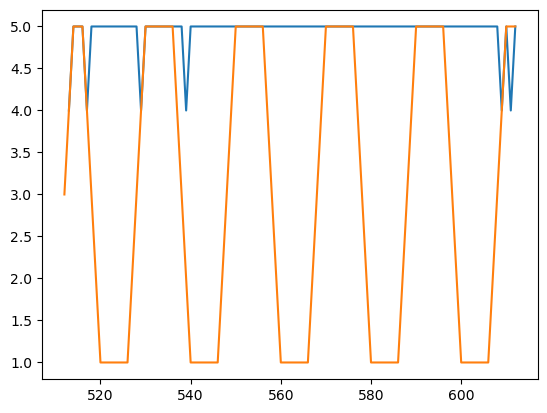

(675, 57) (675,) (75, 57) (75, 57)
Best Model: Epoch 01 | train MSE 2.193667 | val MSE 1.542584
Best Model: Epoch 03 | train MSE 0.526791 | val MSE 1.341638
Epoch 100 | train MSE 0.000118 | val MSE 2.555340
Epoch 200 | train MSE 0.005919 | val MSE 2.284119
Epoch 300 | train MSE 0.003813 | val MSE 2.305207
Epoch 400 | train MSE 0.013459 | val MSE 2.243511
Epoch 500 | train MSE 0.000546 | val MSE 2.258143
Epoch 600 | train MSE 0.002070 | val MSE 2.177573
Epoch 700 | train MSE 0.099372 | val MSE 2.493668
Epoch 800 | train MSE 0.002148 | val MSE 2.188550
Epoch 900 | train MSE 0.000423 | val MSE 2.165185
Epoch 1000 | train MSE 0.000006 | val MSE 1.647119
Epoch 1100 | train MSE 0.012395 | val MSE 1.666507
Epoch 1200 | train MSE 0.001982 | val MSE 2.126819
Epoch 1300 | train MSE 0.000046 | val MSE 1.832877
Epoch 1400 | train MSE 0.000001 | val MSE 2.072805
Epoch 1500 | train MSE 0.008114 | val MSE 1.948276
Epoch 1600 | train MSE 0.004333 | val MSE 1.582582
Epoch 1700 | train MSE 0.000278 | va

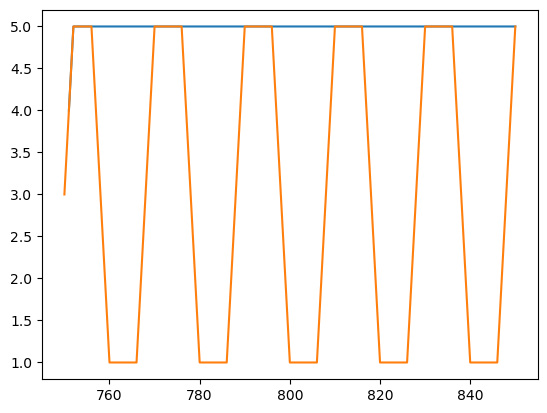

(922, 57) (922,) (102, 57) (102, 57)
Best Model: Epoch 01 | train MSE 2.173302 | val MSE 0.349923
Best Model: Epoch 04 | train MSE 0.721489 | val MSE 0.154559
Best Model: Epoch 05 | train MSE 0.396487 | val MSE 0.131645
Best Model: Epoch 06 | train MSE 0.241509 | val MSE 0.094737
Best Model: Epoch 70 | train MSE 0.190687 | val MSE 0.090672
Epoch 100 | train MSE 0.000440 | val MSE 0.471834
Epoch 200 | train MSE 0.141594 | val MSE 0.491901
Epoch 300 | train MSE 0.026116 | val MSE 0.700207
Epoch 400 | train MSE 0.018035 | val MSE 0.609801
Epoch 500 | train MSE 0.058223 | val MSE 0.642525
Epoch 600 | train MSE 0.041299 | val MSE 0.716266
Epoch 700 | train MSE 0.000050 | val MSE 0.464508
Epoch 800 | train MSE 0.000013 | val MSE 0.564556
Epoch 900 | train MSE 0.000209 | val MSE 0.608163
Epoch 1000 | train MSE 0.019142 | val MSE 0.541109
Epoch 1100 | train MSE 0.003878 | val MSE 0.872745
Epoch 1200 | train MSE 0.000046 | val MSE 0.705444
Epoch 1300 | train MSE 0.000079 | val MSE 0.750389
Epoc

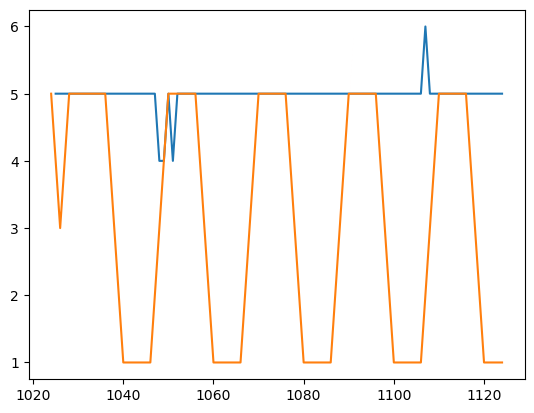

(1125, 57) (1125,) (125, 57) (125, 57)
Best Model: Epoch 01 | train MSE 2.008955 | val MSE 1.371939
Best Model: Epoch 02 | train MSE 1.135955 | val MSE 0.802327
Best Model: Epoch 04 | train MSE 0.317344 | val MSE 0.581970
Best Model: Epoch 29 | train MSE 0.226938 | val MSE 0.474599
Epoch 100 | train MSE 0.027884 | val MSE 0.645337
Epoch 200 | train MSE 0.016000 | val MSE 0.580488
Best Model: Epoch 204 | train MSE 0.182259 | val MSE 0.424922
Best Model: Epoch 208 | train MSE 0.082240 | val MSE 0.309070
Epoch 300 | train MSE 0.001781 | val MSE 0.404655
Epoch 400 | train MSE 0.000738 | val MSE 0.497644
Epoch 500 | train MSE 0.009909 | val MSE 0.586387
Best Model: Epoch 521 | train MSE 0.001978 | val MSE 0.294833
Best Model: Epoch 522 | train MSE 0.001752 | val MSE 0.294336
Epoch 600 | train MSE 0.001247 | val MSE 0.374095
Best Model: Epoch 632 | train MSE 0.001726 | val MSE 0.270621
Best Model: Epoch 633 | train MSE 0.001241 | val MSE 0.261413
Best Model: Epoch 643 | train MSE 0.000368 | 

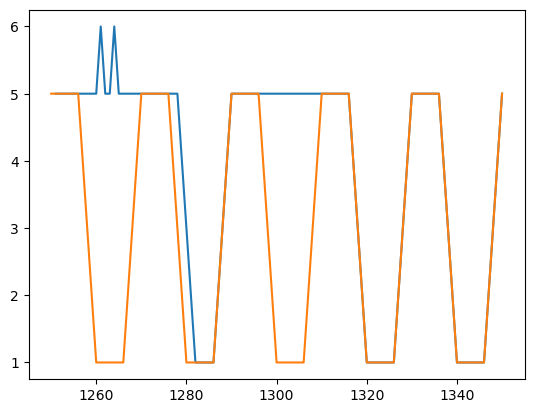

(1350, 57) (1350,) (150, 57) (150, 57)
Best Model: Epoch 01 | train MSE 1.816684 | val MSE 2.299812
Best Model: Epoch 02 | train MSE 1.178407 | val MSE 2.149915
Best Model: Epoch 03 | train MSE 0.701847 | val MSE 2.063161
Best Model: Epoch 46 | train MSE 0.306320 | val MSE 1.930998
Best Model: Epoch 51 | train MSE 0.105965 | val MSE 1.730725
Best Model: Epoch 61 | train MSE 0.047065 | val MSE 1.711463
Best Model: Epoch 64 | train MSE 0.023652 | val MSE 1.694677
Epoch 100 | train MSE 0.024550 | val MSE 1.792559
Best Model: Epoch 105 | train MSE 0.018349 | val MSE 1.569154
Best Model: Epoch 157 | train MSE 0.012397 | val MSE 1.525384
Epoch 200 | train MSE 0.003360 | val MSE 1.731934
Best Model: Epoch 285 | train MSE 0.007971 | val MSE 1.141489
Epoch 300 | train MSE 0.000544 | val MSE 1.185623
Best Model: Epoch 328 | train MSE 0.006824 | val MSE 1.100877
Best Model: Epoch 353 | train MSE 0.005202 | val MSE 1.030620
Best Model: Epoch 354 | train MSE 0.005114 | val MSE 0.981764
Best Model: 

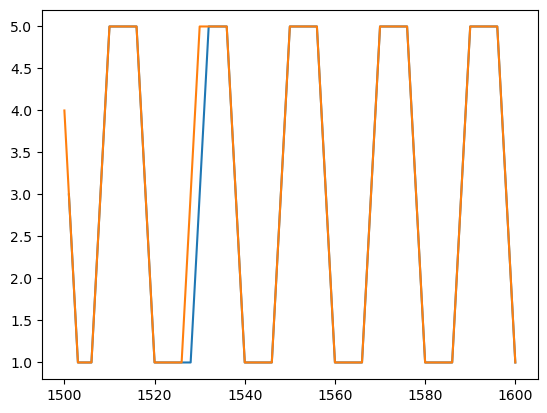

(1844, 57) (1844,) (204, 57) (204, 57)
Best Model: Epoch 01 | train MSE 1.914187 | val MSE 1.252742
Best Model: Epoch 02 | train MSE 1.029583 | val MSE 0.625520
Best Model: Epoch 05 | train MSE 0.335255 | val MSE 0.602441
Best Model: Epoch 08 | train MSE 0.091467 | val MSE 0.445456
Best Model: Epoch 09 | train MSE 0.046294 | val MSE 0.437325
Best Model: Epoch 10 | train MSE 0.022092 | val MSE 0.403529
Best Model: Epoch 11 | train MSE 0.017615 | val MSE 0.402382
Best Model: Epoch 32 | train MSE 0.016484 | val MSE 0.267300
Best Model: Epoch 33 | train MSE 0.014293 | val MSE 0.262546
Best Model: Epoch 39 | train MSE 0.003622 | val MSE 0.252185
Best Model: Epoch 42 | train MSE 0.003387 | val MSE 0.249445
Best Model: Epoch 73 | train MSE 0.002717 | val MSE 0.157526
Best Model: Epoch 82 | train MSE 0.002691 | val MSE 0.154545
Epoch 100 | train MSE 0.007072 | val MSE 0.148064
Best Model: Epoch 108 | train MSE 0.002306 | val MSE 0.151047
Best Model: Epoch 109 | train MSE 0.002192 | val MSE 0.1

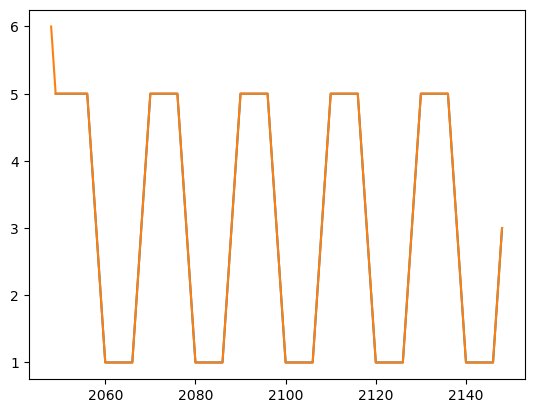

(3687, 57) (3687,) (409, 57) (409, 57)
Best Model: Epoch 01 | train MSE 1.503727 | val MSE 1.242571
Best Model: Epoch 02 | train MSE 0.655407 | val MSE 0.643925
Best Model: Epoch 03 | train MSE 0.173216 | val MSE 0.169455
Best Model: Epoch 06 | train MSE 0.071683 | val MSE 0.138802
Best Model: Epoch 07 | train MSE 0.046618 | val MSE 0.100953
Best Model: Epoch 08 | train MSE 0.021886 | val MSE 0.084688
Best Model: Epoch 09 | train MSE 0.015519 | val MSE 0.067692
Best Model: Epoch 15 | train MSE 0.014607 | val MSE 0.048079
Best Model: Epoch 27 | train MSE 0.009901 | val MSE 0.028199
Best Model: Epoch 33 | train MSE 0.006477 | val MSE 0.020262
Best Model: Epoch 36 | train MSE 0.003520 | val MSE 0.018055
Best Model: Epoch 81 | train MSE 0.001520 | val MSE 0.009348
Best Model: Epoch 83 | train MSE 0.000905 | val MSE 0.008837
Best Model: Epoch 85 | train MSE 0.000389 | val MSE 0.008807
Best Model: Epoch 91 | train MSE 0.000193 | val MSE 0.008740
Epoch 100 | train MSE 0.001692 | val MSE 0.011

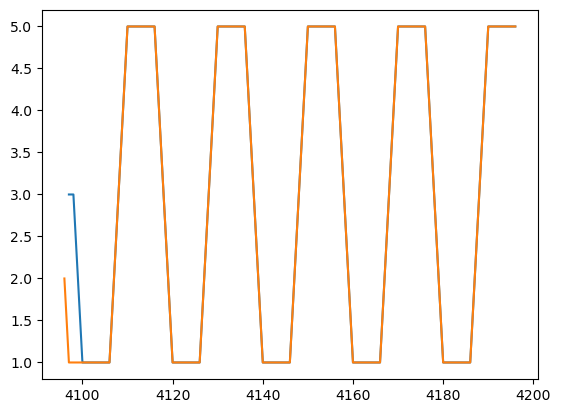

(116, 57) (116,) (12, 57) (12, 57)
Best Model: Epoch 01 | train MSE 3.688384 | val MSE 1.190697
Best Model: Epoch 02 | train MSE 3.180679 | val MSE 0.297693
Best Model: Epoch 03 | train MSE 2.179085 | val MSE 0.169275
Epoch 100 | train MSE 0.000026 | val MSE 1.097766
Epoch 200 | train MSE 0.005635 | val MSE 1.169108
Epoch 300 | train MSE 0.000140 | val MSE 1.277655
Epoch 400 | train MSE 0.000167 | val MSE 1.288892
Epoch 500 | train MSE 0.000005 | val MSE 1.287661
Epoch 600 | train MSE 0.000233 | val MSE 1.271043
Epoch 700 | train MSE 0.032967 | val MSE 0.593606
Epoch 800 | train MSE 0.000008 | val MSE 0.686694
Epoch 900 | train MSE 0.000001 | val MSE 0.682986
Epoch 1000 | train MSE 0.000000 | val MSE 0.681412
Epoch 1100 | train MSE 0.000000 | val MSE 0.680988
Epoch 1200 | train MSE 0.000000 | val MSE 0.680999
Epoch 1300 | train MSE 0.000000 | val MSE 0.680999
Epoch 1400 | train MSE 0.000000 | val MSE 0.680616
Epoch 1500 | train MSE 0.000235 | val MSE 0.675834
Best Model: Epoch 1544 | t

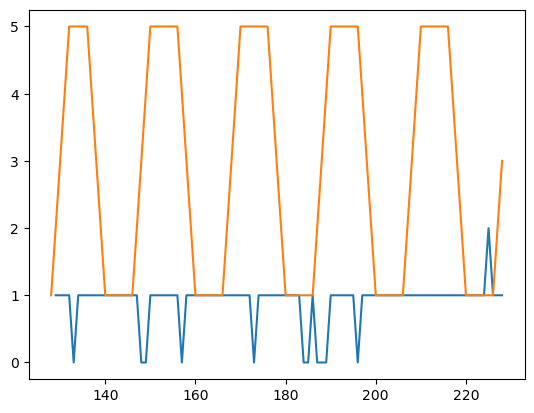

(231, 57) (231,) (25, 57) (25, 57)
Best Model: Epoch 01 | train MSE 2.656773 | val MSE 3.611027
Best Model: Epoch 02 | train MSE 2.009318 | val MSE 3.335713
Best Model: Epoch 03 | train MSE 1.378719 | val MSE 2.676265
Best Model: Epoch 04 | train MSE 1.182791 | val MSE 2.518761
Best Model: Epoch 05 | train MSE 0.867582 | val MSE 2.157482
Epoch 100 | train MSE 0.042146 | val MSE 2.567792
Epoch 200 | train MSE 0.002190 | val MSE 2.812642
Epoch 300 | train MSE 0.000015 | val MSE 2.814945
Epoch 400 | train MSE 0.000007 | val MSE 2.808886
Epoch 500 | train MSE 0.000458 | val MSE 3.462664
Epoch 600 | train MSE 0.000059 | val MSE 3.472580
Epoch 700 | train MSE 0.000137 | val MSE 3.476082
Epoch 800 | train MSE 0.000001 | val MSE 3.122570
Epoch 900 | train MSE 0.000000 | val MSE 3.122978
Epoch 1000 | train MSE 0.002582 | val MSE 3.054210
Epoch 1100 | train MSE 0.001712 | val MSE 3.944446
Epoch 1200 | train MSE 0.000668 | val MSE 3.968143
Epoch 1300 | train MSE 0.000825 | val MSE 4.047509
Epoch 

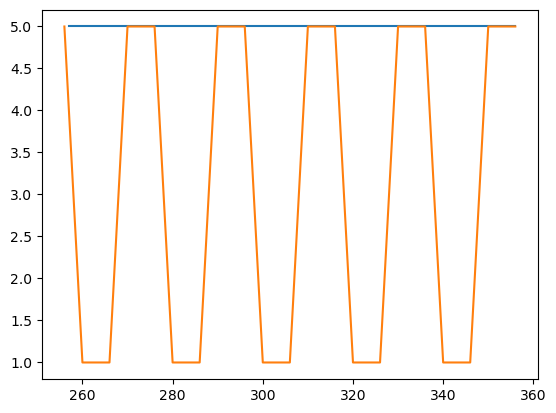

(461, 57) (461,) (51, 57) (51, 57)
Best Model: Epoch 01 | train MSE 2.081404 | val MSE 1.093178
Best Model: Epoch 02 | train MSE 1.397821 | val MSE 0.903267
Best Model: Epoch 07 | train MSE 0.623913 | val MSE 0.867532
Best Model: Epoch 19 | train MSE 0.066400 | val MSE 0.823726
Best Model: Epoch 24 | train MSE 0.022165 | val MSE 0.802321
Best Model: Epoch 43 | train MSE 0.021633 | val MSE 0.802280
Best Model: Epoch 64 | train MSE 0.012019 | val MSE 0.639602
Best Model: Epoch 65 | train MSE 0.006661 | val MSE 0.611461
Epoch 100 | train MSE 0.040380 | val MSE 0.682984
Best Model: Epoch 110 | train MSE 0.003431 | val MSE 0.604275
Epoch 200 | train MSE 0.000371 | val MSE 0.956167
Epoch 300 | train MSE 0.000909 | val MSE 0.846366
Epoch 400 | train MSE 0.001371 | val MSE 0.889334
Epoch 500 | train MSE 0.009533 | val MSE 0.761456
Epoch 600 | train MSE 0.001016 | val MSE 0.915804
Epoch 700 | train MSE 0.001051 | val MSE 0.852668
Epoch 800 | train MSE 0.001899 | val MSE 0.812847
Epoch 900 | tra

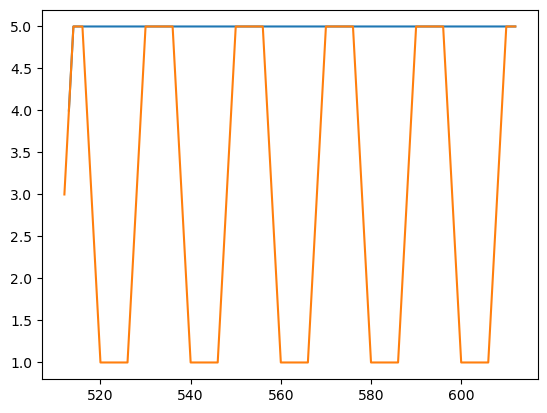

(675, 57) (675,) (75, 57) (75, 57)
Best Model: Epoch 01 | train MSE 2.401434 | val MSE 3.114652
Best Model: Epoch 02 | train MSE 1.669746 | val MSE 2.334429
Best Model: Epoch 03 | train MSE 0.996990 | val MSE 1.835649
Best Model: Epoch 82 | train MSE 0.108675 | val MSE 1.727105
Epoch 100 | train MSE 0.002051 | val MSE 2.437148
Epoch 200 | train MSE 0.001341 | val MSE 2.415771
Epoch 300 | train MSE 0.000004 | val MSE 2.230752
Epoch 400 | train MSE 0.091738 | val MSE 2.699505
Epoch 500 | train MSE 0.000027 | val MSE 2.880338
Epoch 600 | train MSE 0.033295 | val MSE 2.642071
Epoch 700 | train MSE 0.000048 | val MSE 2.929204
Epoch 800 | train MSE 0.000285 | val MSE 2.665395
Epoch 900 | train MSE 0.000144 | val MSE 2.595377
Epoch 1000 | train MSE 0.000308 | val MSE 2.559028
Epoch 1100 | train MSE 0.000028 | val MSE 2.581569
Epoch 1200 | train MSE 0.062433 | val MSE 2.200233
Epoch 1300 | train MSE 0.001148 | val MSE 2.576180
Epoch 1400 | train MSE 0.000067 | val MSE 2.124714
Epoch 1500 | tra

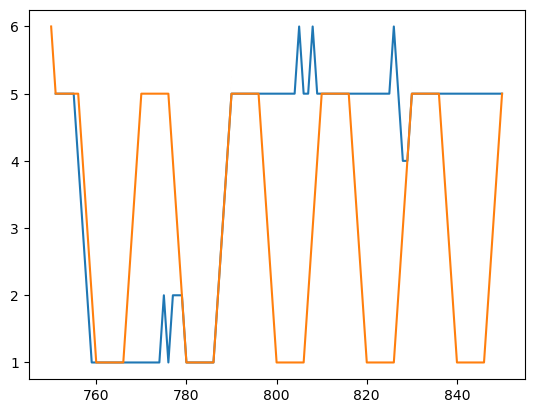

(922, 57) (922,) (102, 57) (102, 57)
Best Model: Epoch 01 | train MSE 2.180744 | val MSE 2.580449
Best Model: Epoch 02 | train MSE 1.354549 | val MSE 2.461014
Best Model: Epoch 03 | train MSE 0.594032 | val MSE 1.187557
Best Model: Epoch 05 | train MSE 0.203375 | val MSE 1.152255
Best Model: Epoch 06 | train MSE 0.130925 | val MSE 1.037566
Best Model: Epoch 08 | train MSE 0.076687 | val MSE 0.911309
Best Model: Epoch 16 | train MSE 0.076057 | val MSE 0.777841
Best Model: Epoch 25 | train MSE 0.029721 | val MSE 0.777712
Epoch 100 | train MSE 0.000102 | val MSE 0.866118
Best Model: Epoch 144 | train MSE 0.024447 | val MSE 0.735683
Best Model: Epoch 145 | train MSE 0.010989 | val MSE 0.670870
Best Model: Epoch 146 | train MSE 0.008618 | val MSE 0.670700
Best Model: Epoch 147 | train MSE 0.005165 | val MSE 0.648153
Epoch 200 | train MSE 0.001332 | val MSE 0.703410
Epoch 300 | train MSE 0.001373 | val MSE 0.738682
Epoch 400 | train MSE 0.001443 | val MSE 0.799682
Epoch 500 | train MSE 0.000

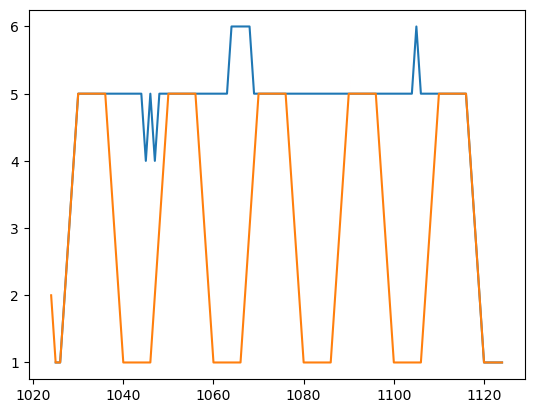

(1125, 57) (1125,) (125, 57) (125, 57)
Best Model: Epoch 01 | train MSE 2.408595 | val MSE 0.898715
Best Model: Epoch 08 | train MSE 0.148065 | val MSE 0.763740
Best Model: Epoch 28 | train MSE 0.022502 | val MSE 0.724960
Best Model: Epoch 90 | train MSE 0.009834 | val MSE 0.720991
Epoch 100 | train MSE 0.005593 | val MSE 0.798528
Best Model: Epoch 101 | train MSE 0.005532 | val MSE 0.717889
Best Model: Epoch 128 | train MSE 0.004001 | val MSE 0.716431
Best Model: Epoch 131 | train MSE 0.002124 | val MSE 0.712510
Best Model: Epoch 134 | train MSE 0.001897 | val MSE 0.694453
Epoch 200 | train MSE 0.005815 | val MSE 0.786725
Best Model: Epoch 254 | train MSE 0.001332 | val MSE 0.646545
Best Model: Epoch 257 | train MSE 0.000863 | val MSE 0.635874
Epoch 300 | train MSE 0.000270 | val MSE 0.643801
Epoch 400 | train MSE 0.008903 | val MSE 0.579628
Epoch 500 | train MSE 0.004186 | val MSE 0.546999
Epoch 600 | train MSE 0.001028 | val MSE 0.946015
Epoch 700 | train MSE 0.000223 | val MSE 0.97

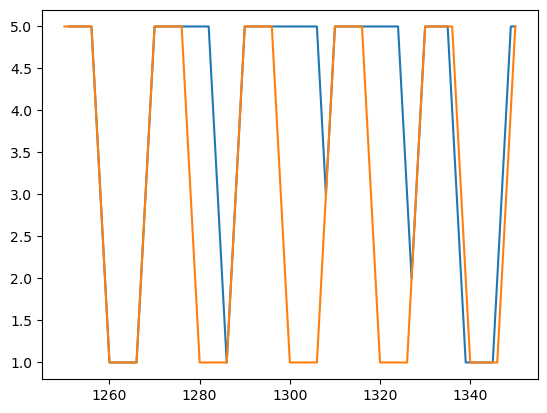

(1350, 57) (1350,) (150, 57) (150, 57)
Best Model: Epoch 01 | train MSE 2.330687 | val MSE 1.730880
Best Model: Epoch 04 | train MSE 0.642601 | val MSE 1.504891
Best Model: Epoch 11 | train MSE 0.032974 | val MSE 1.481554
Best Model: Epoch 22 | train MSE 0.031545 | val MSE 1.475484
Best Model: Epoch 23 | train MSE 0.027229 | val MSE 1.409945
Best Model: Epoch 32 | train MSE 0.012478 | val MSE 1.387783
Best Model: Epoch 43 | train MSE 0.008363 | val MSE 1.259131
Best Model: Epoch 47 | train MSE 0.006832 | val MSE 1.256577
Best Model: Epoch 95 | train MSE 0.006601 | val MSE 1.018125
Epoch 100 | train MSE 0.013277 | val MSE 0.961661
Best Model: Epoch 102 | train MSE 0.004933 | val MSE 0.994619
Best Model: Epoch 110 | train MSE 0.000652 | val MSE 0.993465
Best Model: Epoch 111 | train MSE 0.000603 | val MSE 0.991657
Best Model: Epoch 112 | train MSE 0.000564 | val MSE 0.990423
Best Model: Epoch 127 | train MSE 0.000552 | val MSE 0.989158
Best Model: Epoch 187 | train MSE 0.000501 | val MSE

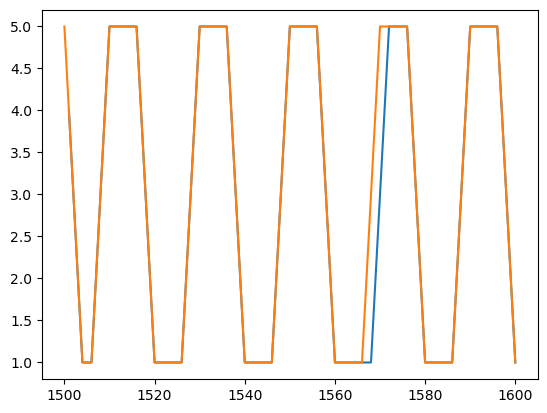

(1844, 57) (1844,) (204, 57) (204, 57)
Best Model: Epoch 01 | train MSE 1.939906 | val MSE 1.833432
Best Model: Epoch 02 | train MSE 1.337059 | val MSE 1.453108
Best Model: Epoch 03 | train MSE 0.640401 | val MSE 0.815253
Best Model: Epoch 05 | train MSE 0.278901 | val MSE 0.469060
Best Model: Epoch 06 | train MSE 0.122090 | val MSE 0.467932
Best Model: Epoch 08 | train MSE 0.055058 | val MSE 0.446237
Best Model: Epoch 13 | train MSE 0.024396 | val MSE 0.422278
Best Model: Epoch 14 | train MSE 0.020607 | val MSE 0.387539
Best Model: Epoch 31 | train MSE 0.020176 | val MSE 0.229610
Best Model: Epoch 32 | train MSE 0.015827 | val MSE 0.174282
Best Model: Epoch 69 | train MSE 0.014158 | val MSE 0.096064
Best Model: Epoch 70 | train MSE 0.006363 | val MSE 0.088862
Best Model: Epoch 71 | train MSE 0.003812 | val MSE 0.085918
Best Model: Epoch 72 | train MSE 0.001966 | val MSE 0.081978
Best Model: Epoch 77 | train MSE 0.001416 | val MSE 0.081693
Best Model: Epoch 79 | train MSE 0.000477 | va

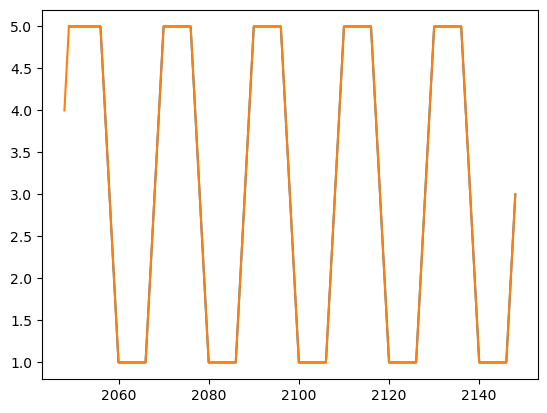

(3687, 57) (3687,) (409, 57) (409, 57)
Best Model: Epoch 01 | train MSE 1.625811 | val MSE 1.106471
Best Model: Epoch 02 | train MSE 0.666509 | val MSE 0.691353
Best Model: Epoch 03 | train MSE 0.259300 | val MSE 0.180007
Best Model: Epoch 04 | train MSE 0.133232 | val MSE 0.141488
Best Model: Epoch 05 | train MSE 0.084117 | val MSE 0.125248
Best Model: Epoch 06 | train MSE 0.049298 | val MSE 0.123116
Best Model: Epoch 07 | train MSE 0.031921 | val MSE 0.105740
Best Model: Epoch 08 | train MSE 0.024679 | val MSE 0.071984
Best Model: Epoch 24 | train MSE 0.020761 | val MSE 0.049395
Best Model: Epoch 25 | train MSE 0.014056 | val MSE 0.039911
Best Model: Epoch 32 | train MSE 0.011689 | val MSE 0.029718
Best Model: Epoch 33 | train MSE 0.006309 | val MSE 0.024337
Best Model: Epoch 38 | train MSE 0.002732 | val MSE 0.024092
Best Model: Epoch 40 | train MSE 0.000979 | val MSE 0.023395
Epoch 100 | train MSE 0.002195 | val MSE 0.011301
Best Model: Epoch 106 | train MSE 0.000753 | val MSE 0.00

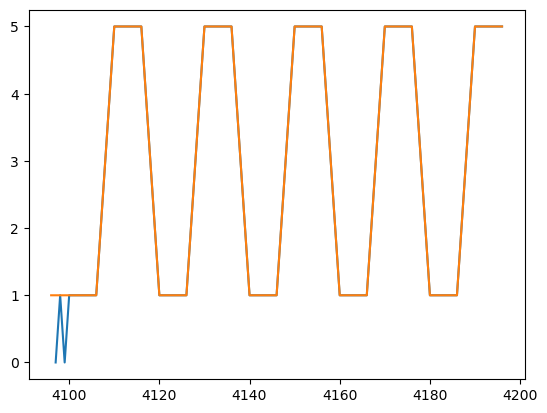

(116, 57) (116,) (12, 57) (12, 57)
Best Model: Epoch 01 | train MSE 2.394774 | val MSE 2.798012
Best Model: Epoch 02 | train MSE 1.780464 | val MSE 2.751879
Best Model: Epoch 03 | train MSE 1.285918 | val MSE 2.521211
Best Model: Epoch 04 | train MSE 0.854205 | val MSE 2.392533
Best Model: Epoch 05 | train MSE 0.524793 | val MSE 2.286640
Best Model: Epoch 06 | train MSE 0.331197 | val MSE 2.237065
Best Model: Epoch 07 | train MSE 0.162999 | val MSE 1.956897
Best Model: Epoch 08 | train MSE 0.094778 | val MSE 1.883100
Best Model: Epoch 30 | train MSE 0.010701 | val MSE 1.732234
Epoch 100 | train MSE 0.000026 | val MSE 1.828606
Best Model: Epoch 155 | train MSE 0.003073 | val MSE 1.729074
Epoch 200 | train MSE 0.000151 | val MSE 1.803433
Epoch 300 | train MSE 0.049905 | val MSE 1.949504
Best Model: Epoch 346 | train MSE 0.001454 | val MSE 1.623590
Best Model: Epoch 356 | train MSE 0.000461 | val MSE 1.608089
Best Model: Epoch 361 | train MSE 0.000357 | val MSE 1.585771
Epoch 400 | train 

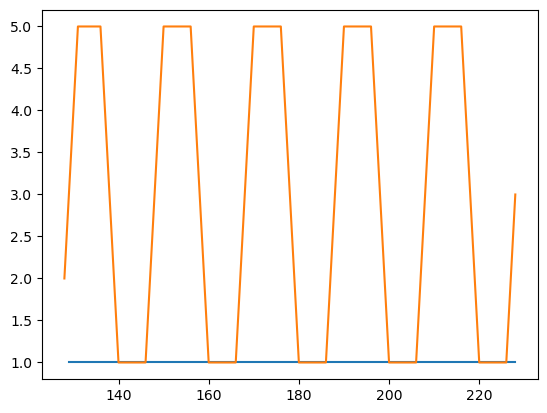

(231, 57) (231,) (25, 57) (25, 57)
Best Model: Epoch 01 | train MSE 2.656365 | val MSE 0.129427
Epoch 100 | train MSE 0.080340 | val MSE 0.951643
Epoch 200 | train MSE 0.066979 | val MSE 1.885347
Epoch 300 | train MSE 0.000019 | val MSE 1.654393
Epoch 400 | train MSE 0.000061 | val MSE 1.687638
Epoch 500 | train MSE 0.000059 | val MSE 1.783646
Epoch 600 | train MSE 0.000006 | val MSE 1.815188
Epoch 700 | train MSE 0.000001 | val MSE 1.812875
Epoch 800 | train MSE 0.364826 | val MSE 1.216730
Epoch 900 | train MSE 0.000729 | val MSE 1.531585
Epoch 1000 | train MSE 0.000193 | val MSE 1.567940
Epoch 1100 | train MSE 0.000245 | val MSE 1.577860
Epoch 1200 | train MSE 0.000175 | val MSE 1.581711
Epoch 1300 | train MSE 0.000437 | val MSE 1.557509
Epoch 1400 | train MSE 0.000811 | val MSE 1.547213
Epoch 1500 | train MSE 0.000323 | val MSE 1.799840
Epoch 1600 | train MSE 0.000106 | val MSE 1.798567
Epoch 1700 | train MSE 0.001296 | val MSE 1.778562
Epoch 1800 | train MSE 0.000971 | val MSE 1.77

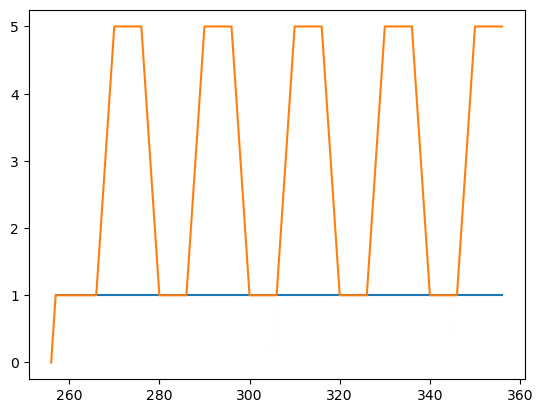

(461, 57) (461,) (51, 57) (51, 57)
Best Model: Epoch 01 | train MSE 2.476854 | val MSE 1.081996
Best Model: Epoch 02 | train MSE 1.808015 | val MSE 0.668260
Best Model: Epoch 05 | train MSE 1.294912 | val MSE 0.615879
Epoch 100 | train MSE 0.003602 | val MSE 0.969426
Best Model: Epoch 157 | train MSE 0.137226 | val MSE 0.536204
Best Model: Epoch 158 | train MSE 0.089809 | val MSE 0.424096
Epoch 200 | train MSE 0.003139 | val MSE 1.434689
Epoch 300 | train MSE 0.000594 | val MSE 1.301623
Epoch 400 | train MSE 0.004048 | val MSE 1.359209
Epoch 500 | train MSE 0.000232 | val MSE 1.357268
Epoch 600 | train MSE 0.001145 | val MSE 1.157414
Epoch 700 | train MSE 0.013378 | val MSE 1.323192
Epoch 800 | train MSE 0.004641 | val MSE 0.847500
Epoch 900 | train MSE 0.000024 | val MSE 0.957604
Epoch 1000 | train MSE 0.000003 | val MSE 0.868109
Epoch 1100 | train MSE 0.000219 | val MSE 0.676132
Epoch 1200 | train MSE 0.005168 | val MSE 0.686709
Epoch 1300 | train MSE 0.000000 | val MSE 0.715502
Epoc

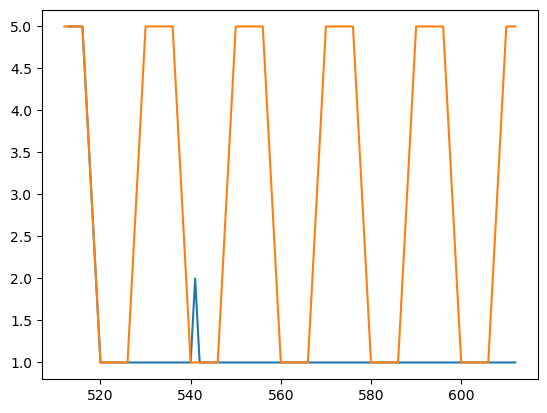

(675, 57) (675,) (75, 57) (75, 57)
Best Model: Epoch 01 | train MSE 2.403838 | val MSE 0.907589
Best Model: Epoch 04 | train MSE 0.379545 | val MSE 0.902515
Best Model: Epoch 05 | train MSE 0.304420 | val MSE 0.800462
Best Model: Epoch 14 | train MSE 0.261209 | val MSE 0.567620
Epoch 100 | train MSE 0.144123 | val MSE 1.368941
Epoch 200 | train MSE 0.020889 | val MSE 1.185940
Epoch 300 | train MSE 0.000226 | val MSE 1.226905
Epoch 400 | train MSE 0.000620 | val MSE 1.282503
Epoch 500 | train MSE 0.000219 | val MSE 1.422246
Epoch 600 | train MSE 0.000782 | val MSE 1.385677
Epoch 700 | train MSE 0.000682 | val MSE 1.416224
Epoch 800 | train MSE 0.209624 | val MSE 1.459347
Epoch 900 | train MSE 0.001418 | val MSE 1.259232
Epoch 1000 | train MSE 0.000648 | val MSE 1.343698
Epoch 1100 | train MSE 0.035983 | val MSE 1.067324
Epoch 1200 | train MSE 0.001999 | val MSE 1.176225
Epoch 1300 | train MSE 0.000742 | val MSE 1.154612
Epoch 1400 | train MSE 0.001944 | val MSE 0.754005
Epoch 1500 | tra

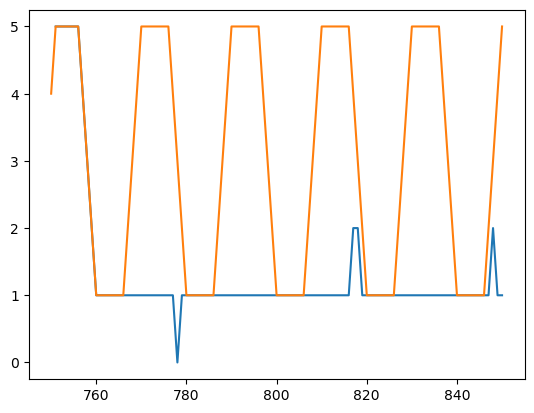

(922, 57) (922,) (102, 57) (102, 57)
Best Model: Epoch 01 | train MSE 2.224008 | val MSE 2.551786
Best Model: Epoch 39 | train MSE 0.164506 | val MSE 2.521628
Best Model: Epoch 70 | train MSE 0.113211 | val MSE 2.363624
Epoch 100 | train MSE 0.002141 | val MSE 3.239663
Epoch 200 | train MSE 0.000138 | val MSE 2.545567
Best Model: Epoch 247 | train MSE 0.039730 | val MSE 2.217479
Best Model: Epoch 251 | train MSE 0.036785 | val MSE 2.091154
Best Model: Epoch 254 | train MSE 0.021505 | val MSE 2.078289
Epoch 300 | train MSE 0.000660 | val MSE 2.290912
Best Model: Epoch 353 | train MSE 0.016324 | val MSE 2.069579
Epoch 400 | train MSE 0.000390 | val MSE 2.510813
Epoch 500 | train MSE 0.007631 | val MSE 2.562580
Epoch 600 | train MSE 0.002488 | val MSE 2.509815
Epoch 700 | train MSE 0.001610 | val MSE 2.427527
Epoch 800 | train MSE 0.003822 | val MSE 2.284912
Best Model: Epoch 865 | train MSE 0.009648 | val MSE 1.876576
Epoch 900 | train MSE 0.058203 | val MSE 1.278932
Epoch 1000 | train M

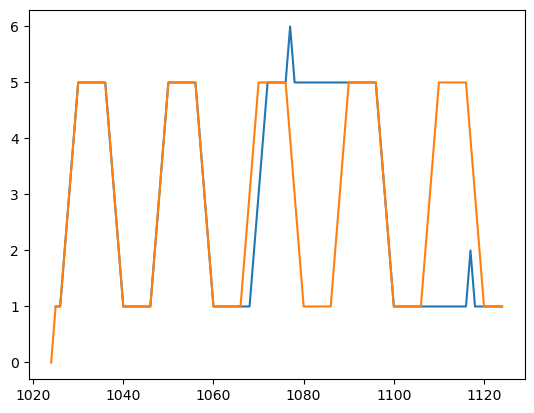

(1125, 57) (1125,) (125, 57) (125, 57)
Best Model: Epoch 01 | train MSE 2.321819 | val MSE 2.818191
Best Model: Epoch 05 | train MSE 0.308644 | val MSE 2.020669
Best Model: Epoch 34 | train MSE 0.201203 | val MSE 1.987930
Best Model: Epoch 36 | train MSE 0.132386 | val MSE 1.817263
Epoch 100 | train MSE 0.017337 | val MSE 2.308293
Best Model: Epoch 196 | train MSE 0.019182 | val MSE 1.665600
Epoch 200 | train MSE 0.011578 | val MSE 1.897674
Best Model: Epoch 244 | train MSE 0.018620 | val MSE 1.576720
Best Model: Epoch 294 | train MSE 0.013506 | val MSE 1.528000
Epoch 300 | train MSE 0.016382 | val MSE 1.675001
Best Model: Epoch 323 | train MSE 0.008572 | val MSE 1.419915
Best Model: Epoch 325 | train MSE 0.008209 | val MSE 1.401542
Best Model: Epoch 379 | train MSE 0.001281 | val MSE 1.377093
Epoch 400 | train MSE 0.010710 | val MSE 1.673427
Epoch 500 | train MSE 0.002439 | val MSE 1.805791
Epoch 600 | train MSE 0.000545 | val MSE 1.789745
Epoch 700 | train MSE 0.000662 | val MSE 1.47

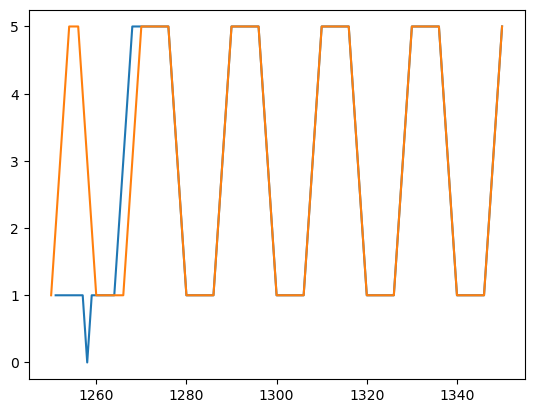

(1350, 57) (1350,) (150, 57) (150, 57)
Best Model: Epoch 01 | train MSE 2.176614 | val MSE 2.062849
Best Model: Epoch 02 | train MSE 1.337816 | val MSE 1.365926
Best Model: Epoch 05 | train MSE 0.475831 | val MSE 1.305843
Best Model: Epoch 08 | train MSE 0.191737 | val MSE 0.760485
Best Model: Epoch 12 | train MSE 0.138873 | val MSE 0.698107
Best Model: Epoch 20 | train MSE 0.015524 | val MSE 0.646273
Best Model: Epoch 23 | train MSE 0.008389 | val MSE 0.616769
Best Model: Epoch 98 | train MSE 0.007331 | val MSE 0.572802
Epoch 100 | train MSE 0.007532 | val MSE 0.593046
Best Model: Epoch 101 | train MSE 0.006422 | val MSE 0.569976
Best Model: Epoch 103 | train MSE 0.005642 | val MSE 0.569653
Best Model: Epoch 106 | train MSE 0.005373 | val MSE 0.566948
Best Model: Epoch 108 | train MSE 0.004862 | val MSE 0.566625
Best Model: Epoch 109 | train MSE 0.004643 | val MSE 0.561351
Best Model: Epoch 114 | train MSE 0.004027 | val MSE 0.558566
Best Model: Epoch 116 | train MSE 0.003834 | val MS

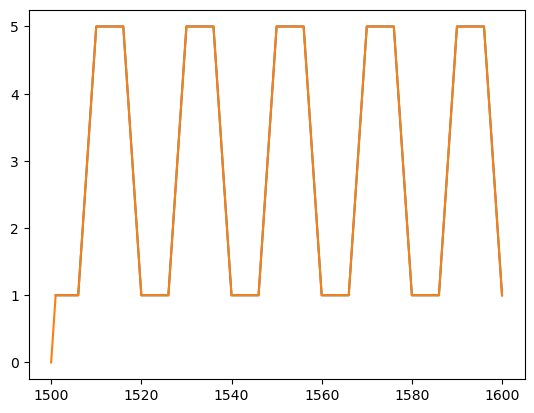

(1844, 57) (1844,) (204, 57) (204, 57)
Best Model: Epoch 01 | train MSE 2.302709 | val MSE 1.944514
Best Model: Epoch 02 | train MSE 1.321944 | val MSE 1.413102
Best Model: Epoch 03 | train MSE 0.619068 | val MSE 0.963545
Best Model: Epoch 04 | train MSE 0.290331 | val MSE 0.886197
Best Model: Epoch 05 | train MSE 0.263099 | val MSE 0.753280
Best Model: Epoch 08 | train MSE 0.120010 | val MSE 0.586471
Best Model: Epoch 10 | train MSE 0.085776 | val MSE 0.568223
Best Model: Epoch 11 | train MSE 0.059007 | val MSE 0.479617
Best Model: Epoch 12 | train MSE 0.033270 | val MSE 0.476292
Best Model: Epoch 13 | train MSE 0.028878 | val MSE 0.434630
Best Model: Epoch 21 | train MSE 0.014397 | val MSE 0.409177
Best Model: Epoch 43 | train MSE 0.010615 | val MSE 0.328813
Best Model: Epoch 66 | train MSE 0.007215 | val MSE 0.246440
Best Model: Epoch 67 | train MSE 0.006093 | val MSE 0.243381
Best Model: Epoch 68 | train MSE 0.004051 | val MSE 0.236025
Best Model: Epoch 81 | train MSE 0.000995 | va

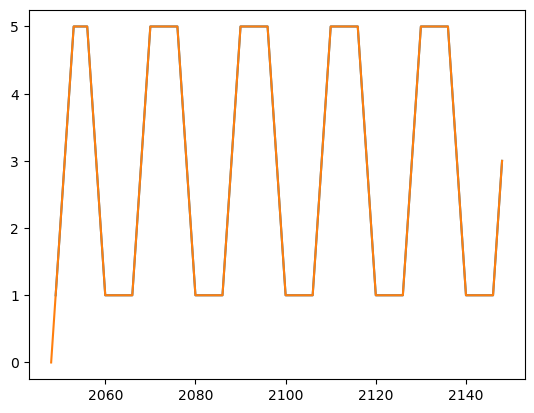

(3687, 57) (3687,) (409, 57) (409, 57)
Best Model: Epoch 01 | train MSE 1.874685 | val MSE 1.129240
Best Model: Epoch 02 | train MSE 0.832824 | val MSE 0.663281
Best Model: Epoch 03 | train MSE 0.275618 | val MSE 0.202197
Best Model: Epoch 04 | train MSE 0.114443 | val MSE 0.103083
Best Model: Epoch 06 | train MSE 0.037441 | val MSE 0.102587
Best Model: Epoch 07 | train MSE 0.019702 | val MSE 0.063439
Best Model: Epoch 25 | train MSE 0.014967 | val MSE 0.020844
Best Model: Epoch 27 | train MSE 0.004619 | val MSE 0.015820
Best Model: Epoch 28 | train MSE 0.002963 | val MSE 0.014077
Best Model: Epoch 34 | train MSE 0.001310 | val MSE 0.013764
Best Model: Epoch 59 | train MSE 0.001245 | val MSE 0.005541
Best Model: Epoch 61 | train MSE 0.000673 | val MSE 0.005020
Best Model: Epoch 70 | train MSE 0.000507 | val MSE 0.004953
Best Model: Epoch 95 | train MSE 0.000426 | val MSE 0.003920
Best Model: Epoch 99 | train MSE 0.000351 | val MSE 0.003662
Epoch 100 | train MSE 0.000213 | val MSE 0.003

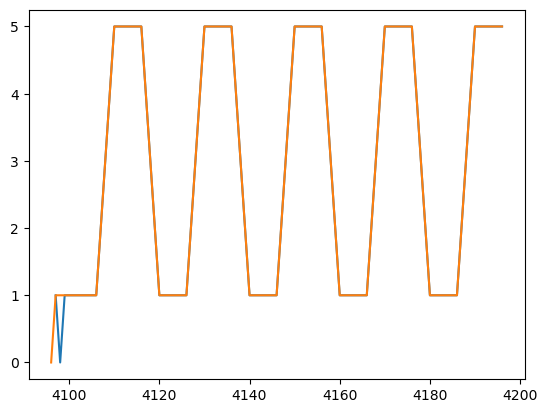

In [ ]:
t_prime = 6
batch_size_train = 32
Ts = [2**i for i in np.arange(7,10)]+[750]+[1024,1250,1500,2048,4096]
# Ts = [1500]
for rep in range(10):
    FUTURE_STATE = []
    actions, states, irewards, times = simulate_data_raw(rewards_in_period = rewards_in_period,
                                                        session_duration = 500000,
                                                        tdim=50, 
                                                        n_sessions=1,seed  = 515+rep)
    state_posencode_oh = position_encoder(states[:,0], type="onehot")
    new_state_oh = np.hstack([state_posencode_oh,states[:,1:]])
    for T in Ts:
        T_val = int(0.1*T)
        T_initial = T - T_val

        X_train = new_state_oh[:T_initial,:]
        Y_train = irewards[:T_initial]

        X_val = new_state_oh[T_initial:T,:]
        Y_val = np.array(irewards[T_initial:T]).reshape(-1,1)
        print(X_train.shape,Y_train.shape,X_val.shape,X_val.shape)
        if T >= 1024:
            batch_size_train = 64
        batch_size_val = T_val
        train_ds = TensorDataset(torch.from_numpy(X_train.astype(np.float32)), torch.from_numpy(Y_train.astype(np.float32)))
        val_ds   = TensorDataset(torch.from_numpy(X_val.astype(np.float32)), torch.from_numpy(Y_val.astype(np.float32)))
        train_loader = DataLoader(train_ds, batch_size=batch_size_train, shuffle=True, drop_last=False)
        val_loader   = DataLoader(val_ds,  batch_size=batch_size_val, shuffle=False, drop_last=False)

        model = MLPRegressor(input_dim=X_train.shape[1], hidden=(128,128), p_dropout=0.1, use_sigmoid=False)
        model = train_regressor(model, train_loader, val_loader, epochs=2000, lr=1e-2,weight_decay = 1e-4)

        current_state = np.random.choice([int(i) for i in range(7)],size = 1)
        future_states = [current_state.item()]
        # print(current_state)
        for delta_t in range(100):
            df_all_paths = enumerate_paths(x0=current_state,t_inital = T+delta_t,t_prime=t_prime)
            n_paths = df_all_paths.shape[0]
            irewards_pred = np.zeros((n_paths,  t_prime+1))
            for i in range(t_prime+1):
                cand_pe = position_encoder(df_all_paths.iloc[:,i], type="onehot")
                curr_time = T+1+delta_t+i
                time_emb = time_embedding_np(np.ones(cand_pe.shape[0])*curr_time, tdim=50)
                features = np.hstack([cand_pe,time_emb])
                irewards_pred[:,i] = predict(model, features)
            reward_cols = [f"t={T+delta_t+t}" for t in range(t_prime+1)]
            df_ireward = pd.DataFrame(irewards_pred, columns=reward_cols)
            # Extract rewards from second column onward (t=1 to t=T)
            rewards_matrix = df_ireward.iloc[:, 1:].values  # shape (n_paths, T)
            discounts = gamma ** np.arange(1, t_prime+1)

            # Compute discounted total reward per path
            discounted_returns = rewards_matrix * discounts  
            total_discounted = discounted_returns.sum(axis=1)
            # print(total_discounted)
            bext_idx = np.argmax(total_discounted)
            next_state = int(df_all_paths.iloc[bext_idx,1])
            # print(df_all_paths.iloc[bext_idx,:])
            future_states.append(next_state)
            current_state = next_state
        
        # print(T,future_states,len(future_states))
        FUTURE_STATE.append(future_states)

        irewards_test = [reward_simulate(future_states[i],T+i,rewards_in_period) for i in np.arange(1,len(future_states))]
        preward = compute_normalized_future_rewards(irewards_test,100,0.5,normalization=True)
        path, ireward_opt = path_opt(future_states[0], T, 100)
        preward_opt_test = compute_normalized_future_rewards(ireward_opt[1:],100,0.5,normalization=True)
        pregret = (np.sum(preward_opt_test).item()-np.sum(preward).item())/100
        print(pregret)
        plt.plot(np.arange(T+1,T+101),future_states[1:])
        plt.plot(np.arange(T,T+101),path)
        plt.show()
    FUTURE_STATE_arr = np.vstack(FUTURE_STATE)
    np.savez(
        f"../results/PAFM/NN_Yuxin/NN_oh_wo_normy_w_time128_2048_lookahead{t_prime}_reps{rep}.npz",
        future_states =FUTURE_STATE_arr
        )


# PVFM - MLP - Regressor

In [ ]:
DELTA_t = 10
t_prime = 6
# Ts = [1000,5000,10000,20000,40000,80000]
Ts = [80000]
# Ts = [2**i for i in np.arange(7,10)]+[750]+[1024,1250,1500,2048]
gamma = 0.5
for rep in range(1):
    np.random.seed(515+rep)
    FUTURE_STATE = []
    for T_initial in Ts:
        # n_seq = int(T/(DELTA_t+1))
        T_val = int(T_initial*0.2)
        T= T_val + T_initial
        n_seq = T
        print(n_seq)
        state_raw = np.random.choice([int(i) for i in range(7)],size = n_seq)
        time_raw = np.random.choice([int(i) for i in range(5000)],size = n_seq)
        opt_paths, opt_times, opt_irewards, opt_prewards = [], [], [], []
        STATES = []
        for i in range(len(time_raw)):
            path, rewards = path_opt(state_raw[i], time_raw[i], DELTA_t)
            # print(state_raw[i],path)
            times = [time_raw[i]+delta_t for delta_t in np.arange(1,DELTA_t+2)] # raw time begin from 1
            opt_paths.append(path)
            opt_irewards.append(rewards)
            opt_times.append(times)
            opt_prewards.append(preward_opt(rewards[1:],gamma = gamma))
            state_posencode_oh = position_encoder(np.array(path), type="onehot")
            time_emb = time_embedding_np(np.array(times)).reshape(DELTA_t+1,-1)
            # print(time_emb.shape,state_posencode_oh.shape)
            state_pe = np.hstack([state_posencode_oh,time_emb])
            STATES.append(state_pe[0,:])
        STATES_arr = np.vstack(STATES)
        REWARDS_arr = np.hstack(np.array(opt_prewards).reshape(-1,1))
        # print(STATES_arr.shape,REWARDS_arr.shape)
        # print(REWARDS_arr[:3],REWARDS_arr[-3:]
        
        X_train = STATES_arr[:T_initial,:]
        Y_train = np.array(REWARDS_arr[:T_initial]).reshape(-1,1)/ 10

        X_val = STATES_arr[T_initial:T,:]
        Y_val = np.array(REWARDS_arr[T_initial:T]).reshape(-1,1)/ 10
        print(X_train.shape,Y_train.shape,X_val.shape,Y_val.shape)
        epochs = 200
        weight_decay = 1e-6
        learning_rate = 3e-4
        batch_size_train = 256
        hidden_layers = (512,256,128)
        if T_initial <= 5000:
            learning_rate = 1e-4
            batch_size_train = 32
            # epochs = 100
            hidden_layers = (192,128)
        elif T_initial == 10000:
            # learning_rate = 3e-4
            batch_size_train = 128
            hidden_layers = (512,256)
        elif T_initial == 20000:
            # learning_rate = 3e-4
            batch_size_train = 256
            # hidden_layers = (512,256,128)
            # epochs = 500
        elif T_initial == 40000:
            # learning_rate = 3e-4
            batch_size_train = 256
            # hidden_layers = (512,256,128)
            # epochs = 500
        elif T_initial == 80000:
            # learning_rate = 1e-4
            batch_size_train = 256
            # hidden_layers = (1024,256,128)
            # epochs = 50
        elif T_initial <= 160000:
            learning_rate = 3e-3
            batch_size_train = 512
        elif T_initial <= 320000:
            learning_rate = 1e-3
            batch_size_train = 1024
        elif T_initial <= 640000:
            learning_rate = 1e-3
            batch_size_train = 2048
        batch_size_val = T_val
        train_ds = TensorDataset(torch.from_numpy(X_train.astype(np.float32)), torch.from_numpy(Y_train.astype(np.float32)))
        val_ds   = TensorDataset(torch.from_numpy(X_val.astype(np.float32)), torch.from_numpy(Y_val.astype(np.float32)))
        train_loader = DataLoader(train_ds, batch_size=batch_size_train, shuffle=True, drop_last=False)
        val_loader   = DataLoader(val_ds,  batch_size=batch_size_val, shuffle=False, drop_last=False)

        model_reg = MLPRegressor(input_dim=X_train.shape[1], hidden=hidden_layers, p_dropout=0.2, use_sigmoid=True)
        model_reg = train_regressor(model_reg, train_loader, val_loader, epochs=epochs, lr=learning_rate,weight_decay = weight_decay)
        print(T_initial,'train done')
        
        current_state = np.random.choice([int(i) for i in range(7)],size = 1)
        future_states = [current_state.item()]
        # print(current_state)
        irewards_test = []
        for delta_t in range(100):
            df_all_paths = enumerate_paths(x0=current_state,t_inital = T_initial+delta_t,t_prime=t_prime)
            n_paths = df_all_paths.shape[0]
            prewards_pred = np.zeros((n_paths,  t_prime+1))
            for i in range(t_prime+1):
                cand_pe = position_encoder(df_all_paths.iloc[:,i], type="onehot")
                curr_time = T_initial+1+delta_t+i
                time_emb = time_embedding_np(np.ones(cand_pe.shape[0])*curr_time, tdim=50)
                features = np.hstack([cand_pe,time_emb])
                pred_val = predict(model_reg, features)*10
                prewards_pred[:,i] = pred_val
            idx_sorted = np.lexsort([prewards_pred[:, j] for j in [1,-1]])
            best_idx = idx_sorted[-1]
            best_path = df_all_paths.iloc[best_idx,:]
            next_state = np.array(best_path)[1]
            future_states.append(next_state.item())
            irewards_test.append(reward_simulate(next_state,T_initial+delta_t+1,rewards_in_period))
            current_state = next_state
        # print(T,future_states,len(future_states))
        FUTURE_STATE.append(future_states)

        irewards = [reward_simulate(future_states[i],T_initial+i,rewards_in_period) for i in np.arange(1,len(future_states))]
        preward = compute_normalized_future_rewards(irewards,100,gamma)
        path, ireward_opt = path_opt(future_states[0], T_initial, 100)
        preward_opt_test = compute_normalized_future_rewards(ireward_opt[1:],100,gamma)
        pregret = (np.sum(preward_opt_test).item()-np.sum(preward).item())/100
        print(pregret)
        plt.plot(np.arange(T_initial+1,T_initial+101),future_states[1:])
        plt.plot(np.arange(T_initial,T_initial+101),path)
        plt.show()

    FUTURE_STATE_arr = np.vstack(FUTURE_STATE)
    # np.savez(
    #     f"../results/PVFM/NN_Yuxin/NN_SameStructure_optimal_oh_w_time1000_80000_w_lookahead{t_prime}_reps{rep}.npz",
    #     future_states =FUTURE_STATE_arr
    #     )



In [ ]:
DELTA_t = 10
t_prime = 6
Ts = [1000,5000,10000,20000,40000,80000]
# Ts = [80000]
# Ts = [2**i for i in np.arange(7,10)]+[750]+[1024,1250,1500,2048]
gamma = 0.5
for rep in range(10):
    np.random.seed(515+rep)
    FUTURE_STATE = []
    for T_initial in Ts:
        # n_seq = int(T/(DELTA_t+1))
        T_val = int(T_initial*0.2)
        T= T_val + T_initial
        n_seq = T
        print(n_seq)
        state_raw = np.random.choice([int(i) for i in range(7)],size = n_seq)
        time_raw = np.random.choice([int(i) for i in range(T_initial-DELTA_t)],size = n_seq)
        opt_paths, opt_times, opt_irewards, opt_prewards = [], [], [], []
        STATES = []
        for i in range(len(time_raw)):
            path, rewards = path_opt(state_raw[i], time_raw[i], DELTA_t)
            # print(state_raw[i],path)
            times = [time_raw[i]+delta_t for delta_t in np.arange(1,DELTA_t+2)] # raw time begin from 1
            opt_paths.append(path)
            opt_irewards.append(rewards)
            opt_times.append(times)
            opt_prewards.append(preward_opt(rewards[1:],gamma = gamma))
            state_posencode_oh = position_encoder(np.array(path), type="onehot")
            time_emb = time_embedding_np(np.array(times)).reshape(DELTA_t+1,-1)
            # print(time_emb.shape,state_posencode_oh.shape)
            state_pe = np.hstack([state_posencode_oh,time_emb])
            STATES.append(state_pe[0,:])
        STATES_arr = np.vstack(STATES)
        REWARDS_arr = np.hstack(np.array(opt_prewards).reshape(-1,1))
        # print(STATES_arr.shape,REWARDS_arr.shape)
        # print(REWARDS_arr[:3],REWARDS_arr[-3:]
        
        X_train = STATES_arr[:T_initial,:]
        Y_train = np.array(REWARDS_arr[:T_initial]).reshape(-1,1)/ 10

        X_val = STATES_arr[T_initial:T,:]
        Y_val = np.array(REWARDS_arr[T_initial:T]).reshape(-1,1)/ 10
        print(X_train.shape,Y_train.shape,X_val.shape,Y_val.shape)
        
        epochs = 500
        weight_decay = 1e-6
        learning_rate = 3e-4
        batch_size_train = 256
        hidden_layers = (512,256,128)
        if T_initial <= 5000:
            learning_rate = 1e-4
            batch_size_train = 32
            epochs = 500
            # hidden_layers = (192,128)
        elif T_initial == 10000:
            learning_rate = 3e-4
            batch_size_train = 128
            # hidden_layers = (512,256)
        elif T_initial == 20000:
            learning_rate = 3e-4
            batch_size_train = 256
            # hidden_layers = (512,256,128)
            # epochs = 500
        elif T_initial == 40000:
            learning_rate = 3e-4
            batch_size_train = 256
            # hidden_layers = (512,256,128)
            # epochs = 500
        elif T_initial == 80000:
            learning_rate = 3e-4
            batch_size_train = 256
            hidden_layers = (512,256,128)
            # epochs = 50
        elif T_initial <= 160000:
            learning_rate = 3e-3
            batch_size_train = 512
        elif T_initial <= 320000:
            learning_rate = 1e-3
            batch_size_train = 1024
        elif T_initial <= 640000:
            learning_rate = 1e-3
            batch_size_train = 2048
        
        batch_size_val = T_val
        train_ds = TensorDataset(torch.from_numpy(X_train.astype(np.float32)), torch.from_numpy(Y_train.astype(np.float32)))
        val_ds   = TensorDataset(torch.from_numpy(X_val.astype(np.float32)), torch.from_numpy(Y_val.astype(np.float32)))
        train_loader = DataLoader(train_ds, batch_size=batch_size_train, shuffle=True, drop_last=False)
        val_loader   = DataLoader(val_ds,  batch_size=batch_size_val, shuffle=False, drop_last=False)

        model_reg = MLPRegressor(input_dim=X_train.shape[1], hidden=hidden_layers, p_dropout=0.2, use_sigmoid=True)
        model_reg = train_regressor(model_reg, train_loader, val_loader, epochs=epochs, lr=learning_rate,weight_decay = weight_decay)
        print(T_initial,'train done')
        
        current_state = np.random.choice([int(i) for i in range(7)],size = 1)
        future_states = [current_state.item()]
        # print(current_state)
        irewards_test = []
        for delta_t in range(100):
            df_all_paths = enumerate_paths(x0=current_state,t_inital = T_initial+delta_t,t_prime=t_prime)
            n_paths = df_all_paths.shape[0]
            prewards_pred = np.zeros((n_paths,  t_prime+1))
            for i in range(t_prime+1):
                cand_pe = position_encoder(df_all_paths.iloc[:,i], type="onehot")
                curr_time = T_initial+1+delta_t+i
                time_emb = time_embedding_np(np.ones(cand_pe.shape[0])*curr_time, tdim=50)
                features = np.hstack([cand_pe,time_emb])
                pred_val = predict(model_reg, features)*10
                prewards_pred[:,i] = pred_val
            idx_sorted = np.lexsort([prewards_pred[:, j] for j in [1,-1]])
            best_idx = idx_sorted[-1]
            best_path = df_all_paths.iloc[best_idx,:]
            next_state = np.array(best_path)[1]
            future_states.append(next_state.item())
            irewards_test.append(reward_simulate(next_state,T_initial+delta_t+1,rewards_in_period))
            current_state = next_state
        # print(T,future_states,len(future_states))
        FUTURE_STATE.append(future_states)

        irewards = [reward_simulate(future_states[i],T_initial+i,rewards_in_period) for i in np.arange(1,len(future_states))]
        preward = compute_normalized_future_rewards(irewards,100,gamma)
        path, ireward_opt = path_opt(future_states[0], T_initial, 100)
        preward_opt_test = compute_normalized_future_rewards(ireward_opt[1:],100,gamma)
        pregret = (np.sum(preward_opt_test).item()-np.sum(preward).item())/100
        print(pregret)
        plt.plot(np.arange(T_initial+1,T_initial+101),future_states[1:])
        plt.plot(np.arange(T_initial,T_initial+101),path)
        plt.show()

    FUTURE_STATE_arr = np.vstack(FUTURE_STATE)
    np.savez(
        f"../results/PVFM/NN_Yuxin/NN_SameStructure_optimal_oh_w_time1000_80000_w_lookahead{t_prime}_reps{rep}.npz",
        future_states =FUTURE_STATE_arr
        )



training timestamps 1000
(900, 57) (900, 1)
Best Model: Epoch 01 | train MSE 3.575281 | val MSE 5.143962
Epoch 100 | train MSE 0.083168 | val MSE 5.699240
Epoch 200 | train MSE 0.067288 | val MSE 5.614748
Epoch 300 | train MSE 0.061919 | val MSE 5.684083
Epoch 400 | train MSE 0.045971 | val MSE 5.436565
Epoch 500 | train MSE 0.044686 | val MSE 5.593369
900 train done


/var/folders/7_/9pm8yyb11yl_smkwv7tk0ysc0000gn/T/ipykernel_50692/2129208258.py:94: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  prewards_pred[:,i] = pred_val


2.30044432198244


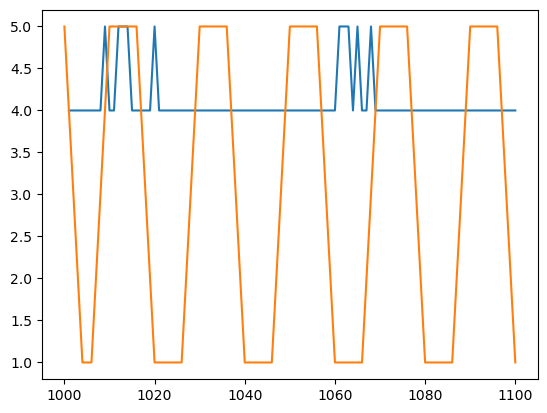

training timestamps 5000
(4500, 57) (4500, 1)
Best Model: Epoch 01 | train MSE 3.329545 | val MSE 3.151004
Best Model: Epoch 07 | train MSE 0.573217 | val MSE 3.021430
Best Model: Epoch 09 | train MSE 0.477259 | val MSE 2.988979
Epoch 100 | train MSE 0.113358 | val MSE 3.145051
Epoch 200 | train MSE 0.062720 | val MSE 3.497480
Epoch 300 | train MSE 0.039314 | val MSE 3.820525
Epoch 400 | train MSE 0.035170 | val MSE 3.642922


KeyboardInterrupt: 

In [29]:
t_prime = 6
Ts = [1000,5000,10000,20000,40000,80000]
# Ts = [80000]
# Ts = [2**i for i in np.arange(7,10)]+[750]+[1024,1250,1500,2048]
gamma = 0.5
normalizer = 1
for rep in np.arange(10):
    FUTURE_STATE = []
    actions, states, irewards, times = simulate_data_raw(rewards_in_period = rewards_in_period,
                                                    session_duration = 500000,
                                                    tdim=50, 
                                                    n_sessions=1,seed  = 515+rep)
    state_posencode_oh = position_encoder(states[:,0], type="onehot")
    new_state_oh = np.hstack([state_posencode_oh,states[:,1:]])
    for T in Ts:
        T_val = int(0.1*T)
        T_initial = T - T_val
        print('training timestamps', T)
        prewards = make_weighted_target(irewards, gamma ,T = T,normalization=False)

        X_train = new_state_oh[:T_initial,:]
        Y_train = np.array(prewards[:T_initial]).reshape(-1,1)/ normalizer 

        X_val = new_state_oh[T_initial:T,:]
        Y_val = np.array(prewards[T_initial:T]).reshape(-1,1)/ normalizer
        print(X_train.shape,Y_train.shape)

        epochs = 500
        weight_decay = 1e-4
        # learning_rate = 3e-4 ## Normalized
        learning_rate = 1e-3 ## Without Normlization
        batch_size_train = 256
        hidden_layers = (512,256,128)
        if T <= 5000:
            learning_rate = 1e-3
            batch_size_train = 32
            epochs = 500
            # hidden_layers = (192,128)
        elif T == 10000:
            learning_rate = 3e-3
            batch_size_train = 64
            # hidden_layers = (512,256)
        elif T == 20000:
            learning_rate = 3e-3
            batch_size_train = 128
            # hidden_layers = (512,256,128)
            # epochs = 500
        elif T == 40000:
            learning_rate = 3e-3
            batch_size_train = 256
            # hidden_layers = (512,256,128)
            # epochs = 500
        elif T == 80000:
            print(T)
            learning_rate = 3e-3 # Without normalization
            batch_size_train = 256
            hidden_layers = (512,256,128)
            # epochs = 50
        elif T_initial <= 160000:
            learning_rate = 3e-3
            batch_size_train = 512
        elif T_initial <= 320000:
            learning_rate = 1e-3
            batch_size_train = 1024
        elif T_initial <= 640000:
            learning_rate = 1e-3
            batch_size_train = 2048
        
        batch_size_val = T_val

        train_ds = TensorDataset(torch.from_numpy(X_train.astype(np.float32)), torch.from_numpy(Y_train.astype(np.float32)))
        val_ds   = TensorDataset(torch.from_numpy(X_val.astype(np.float32)), torch.from_numpy(Y_val.astype(np.float32)))
        train_loader = DataLoader(train_ds, batch_size=batch_size_train, shuffle=True, drop_last=False)
        val_loader   = DataLoader(val_ds,  batch_size=batch_size_val, shuffle=False, drop_last=False)

        model_reg = MLPRegressor(input_dim=X_train.shape[1], hidden=hidden_layers, p_dropout=0.1, use_sigmoid=False)
        model_reg = train_regressor(model_reg, train_loader, val_loader, epochs=epochs, lr=learning_rate,weight_decay = weight_decay)
        print(T_initial,'train done')
        
        current_state = np.random.choice([int(i) for i in range(7)],size = 1)
        future_states = [current_state.item()]
        # print(current_state)
        irewards_test = []
        for delta_t in range(100):
            df_all_paths = enumerate_paths(x0=current_state,t_inital = T+delta_t,t_prime=t_prime)
            n_paths = df_all_paths.shape[0]
            prewards_pred = np.zeros((n_paths,  t_prime+1))
            for i in range(t_prime+1):
                cand_pe = position_encoder(df_all_paths.iloc[:,i], type="onehot")
                curr_time = T+1+delta_t+i
                time_emb = time_embedding_np(np.ones(cand_pe.shape[0])*curr_time, tdim=50)
                features = np.hstack([cand_pe,time_emb])
                pred_val = predict(model_reg, features)*normalizer
                prewards_pred[:,i] = pred_val
            # idx_sorted = np.lexsort([prewards_pred[:, j] for j in [1,-1]])
            idx_sorted = np.lexsort([prewards_pred[:, j] for j in [1,-1]])
            best_idx = idx_sorted[-1]
            best_path = df_all_paths.iloc[best_idx,:]
            next_state = np.array(best_path)[1]
            future_states.append(next_state.item())
            irewards_test.append(reward_simulate(next_state,T+delta_t+1,rewards_in_period))
            current_state = next_state
        # print(T,future_states,len(future_states))
        FUTURE_STATE.append(future_states)

        irewards_future = [reward_simulate(future_states[i],T+i,rewards_in_period) for i in np.arange(1,len(future_states))]
        preward = compute_normalized_future_rewards(irewards_future,100,gamma,normalization=True)
        path, ireward_opt = path_opt(future_states[0], T, 100)
        preward_opt_test = compute_normalized_future_rewards(ireward_opt[1:],100,gamma,normalization=True)
        pregret = (np.sum(preward_opt_test).item()-np.sum(preward).item())/100
        print(pregret)
        plt.plot(np.arange(T+1,T+101),future_states[1:])
        plt.plot(np.arange(T,T+101),path)
        plt.show()

    FUTURE_STATE_arr = np.vstack(FUTURE_STATE)
    np.savez(
        f"../results/PVFM/NN_Yuxin/NN_SameStructure_wo_normy_oh_w_time1000_80000_lookahead{t_prime}_reps{rep}.npz",
        future_states =FUTURE_STATE_arr
        )



In [49]:
current_state = states[T,0]
future_states = [current_state.item()]
# print(current_state)
irewards_test = []
for delta_t in range(100):
    df_all_paths = enumerate_paths(x0=current_state,t_inital = T+delta_t,t_prime=t_prime)
    n_paths = df_all_paths.shape[0]
    prewards_pred = np.zeros((n_paths,  t_prime+1))
    for i in range(t_prime+1):
        cand_pe = position_encoder(df_all_paths.iloc[:,i], type="onehot")
        curr_time = T+1+delta_t+i
        time_emb = time_embedding_np(np.ones(cand_pe.shape[0])*curr_time, tdim=50)
        features = np.hstack([cand_pe,time_emb])
        pred_val = predict(model_reg, features)*normalizer
        prewards_pred[:,i] = pred_val
    # idx_sorted = np.lexsort([prewards_pred[:, j] for j in [1,-1]])
    idx_sorted = np.lexsort([prewards_pred[:, j] for j in [1,-1]])
    best_idx = idx_sorted[-1]
    best_path = df_all_paths.iloc[best_idx,:]
    next_state = np.array(best_path)[1]
    future_states.append(next_state.item())
    irewards_test.append(reward_simulate(next_state,T+delta_t+1,rewards_in_period))
    current_state = next_state
# print(T,future_states,len(future_states))
FUTURE_STATE.append(future_states)

irewards_future = [reward_simulate(future_states[i],T+i,rewards_in_period) for i in np.arange(1,len(future_states))]
preward = compute_normalized_future_rewards(irewards_future,100,gamma)
path, ireward_opt = path_opt(future_states[0], T, 100)
preward_opt_test = compute_normalized_future_rewards(ireward_opt[1:],100,gamma)
pregret = (np.sum(preward_opt_test).item()-np.sum(preward).item())/100
print(pregret)
# plt.plot(np.arange(T+1,T+101),future_states[1:])
# plt.plot(np.arange(T,T+101),path)
# plt.show()

FUTURE_STATE_arr = np.vstack(FUTURE_STATE)
# np.savez(
#     f"../results/PVFM/NN_Yuxin/NN_oh_w_time1000_80000_lookahead{t_prime}_reps{rep}.npz",
#     future_states =FUTURE_STATE_arr
#     )



/var/folders/7_/9pm8yyb11yl_smkwv7tk0ysc0000gn/T/ipykernel_84008/3527481909.py:15: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  prewards_pred[:,i] = pred_val


1.684586217699661
